# **EU Defense Industry Analysis**

First import SIPRI data and then import JANES datasets

In [1]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

In [2]:
def load_sipri_dataframes():
    """
    Load the three SIPRI CSV files into pandas DataFrames
    
    Returns:
        tuple: (regional_transfers_df, export_df, import_df)
    """
    
    # Define the file paths
    base_path = Path("raw_data/SIPRI")
    
    regional_transfers_file = base_path / "regional-transfers_2000-2025.csv"
    export_file = base_path / "trade-register_EU+UK_2000-2025_export.csv"
    import_file = base_path / "trade-register_EU+UK_2000-2025_import.csv"
    
    # Load the CSV files into DataFrames
    try:
        # Regional transfers data - skip first 10 rows, use row 11 as headers
        regional_transfers_df = pd.read_csv(regional_transfers_file, skiprows=10)
        print(f"✓ Loaded {regional_transfers_file.name}: {regional_transfers_df.shape[0]} rows, {regional_transfers_df.shape[1]} columns")
        
        # Restructure the regional transfers data
        regional_transfers_df = restructure_regional_data(regional_transfers_df)
        print(f"✓ Restructured regional transfers data: {regional_transfers_df.shape[0]} rows, {regional_transfers_df.shape[1]} columns")
        
        # Export data - handle potential parsing issues
        try:
            export_df = pd.read_csv(export_file, on_bad_lines='skip', encoding='utf-8', skiprows=11)
            print(f"✓ Loaded {export_file.name}: {export_df.shape[0]} rows, {export_df.shape[1]} columns")
        except:
            # Try with different parameters if initial load fails
            export_df = pd.read_csv(export_file, on_bad_lines='skip', encoding='latin-1', sep=None, engine='python', skiprows=11)
            print(f"✓ Loaded {export_file.name} (with fallback): {export_df.shape[0]} rows, {export_df.shape[1]} columns")
        
        # Import data - handle potential parsing issues
        try:
            import_df = pd.read_csv(import_file, on_bad_lines='skip', encoding='utf-8', skiprows=11)
            print(f"✓ Loaded {import_file.name}: {import_df.shape[0]} rows, {import_df.shape[1]} columns")
        except:
            # Try with different parameters if initial load fails
            import_df = pd.read_csv(import_file, on_bad_lines='skip', encoding='latin-1', sep=None, engine='python', skiprows=11)
            print(f"✓ Loaded {import_file.name} (with fallback): {import_df.shape[0]} rows, {import_df.shape[1]} columns")
        
        return regional_transfers_df, export_df, import_df
        
    except FileNotFoundError as e:
        print(f"Error: Could not find file - {e}")
        return None, None, None
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None

def restructure_regional_data(df):
    """
    Restructure the regional transfers data to have proper organization and country columns
    """
    # Create a copy to work with
    df_copy = df.copy()
    
    # The first two columns should be organization and country
    # Get the column names for the year data (everything after the first two columns)
    year_columns = df_copy.columns[2:]
    
    # Rename the first two columns
    df_copy.columns = ['organization', 'import_country'] + list(year_columns)
    
    # Fill forward the organization column
    # When organization is NaN, it means the country belongs to the previous organization
    current_org = None
    organizations = []
    
    for idx, row in df_copy.iterrows():
        if pd.notna(row['organization']) and row['organization'] != 'NaN':
            current_org = row['organization']
        organizations.append(current_org)
    
    df_copy['organization'] = organizations
    
    # Remove rows where import_country is NaN (these are just organization headers)
    df_copy = df_copy[pd.notna(df_copy['import_country']) & (df_copy['import_country'] != 'NaN')].copy()
    
    # Reset index
    df_copy = df_copy.reset_index(drop=True)
    
    return df_copy

# Load the dataframes
regional_transfers_df, export_df, import_df = load_sipri_dataframes()

# Display basic information about each dataframe
if regional_transfers_df is not None:
    print("\n" + "="*50)
    print("REGIONAL TRANSFERS DATA")
    print("="*50)
    print(f"Shape: {regional_transfers_df.shape}")
    print(f"Columns: {list(regional_transfers_df.columns)}")
    print(f"\nFirst few rows:")
    print(regional_transfers_df.head())
    
if export_df is not None:
    print("\n" + "="*50)
    print("EXPORT DATA")
    print("="*50)
    print(f"Shape: {export_df.shape}")
    print(f"Columns: {list(export_df.columns)}")
    print(f"\nFirst few rows:")
    print(export_df.head())
    
if import_df is not None:
    print("\n" + "="*50)
    print("IMPORT DATA")
    print("="*50)
    print(f"Shape: {import_df.shape}")
    print(f"Columns: {list(import_df.columns)}")
    print(f"\nFirst few rows:")
    print(import_df.head())

# Optional: Check for any missing values
print("\n" + "="*50)
print("DATA QUALITY CHECK")
print("="*50)

if regional_transfers_df is not None:
    print(f"Regional Transfers - Missing values: {regional_transfers_df.isnull().sum().sum()}")
    
if export_df is not None:
    print(f"Export Data - Missing values: {export_df.isnull().sum().sum()}")
    
if import_df is not None:
    print(f"Import Data - Missing values: {import_df.isnull().sum().sum()}")

✓ Loaded regional-transfers_2000-2025.csv: 906 rows, 30 columns
✓ Restructured regional transfers data: 906 rows, 30 columns
✓ Loaded trade-register_EU+UK_2000-2025_export.csv: 6399 rows, 17 columns
✓ Loaded trade-register_EU+UK_2000-2025_import.csv: 3707 rows, 17 columns

REGIONAL TRANSFERS DATA
Shape: (906, 30)
Columns: ['organization', 'import_country', '2000', '2001', '2002', '2003', '2004', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2000-2025', '% of regional total']

First few rows:
  organization  import_country    2000    2001    2002    2003    2004  \
0  Arab League  Regional total  2716.0  2105.0  2874.0  2373.0  4087.0   
1  Arab League         Armenia     NaN     NaN     NaN     NaN     NaN   
2  Arab League       Australia     NaN     NaN     NaN     NaN     0.0   
3  Arab League         Austria     NaN     NaN    79.0     NaN     NaN   
4  Arab Le

In [32]:
def load_additional_defense_data():
    """
    Load additional defense analysis CSV files into pandas DataFrames
    
    Returns:
        dict: Dictionary containing all the DataFrames with descriptive keys
    """
    
    # Define the base path
    base_path = Path("raw_data/Janes")
    
    # Define all the files to load
    files_to_load = {
        'budget_trends_jdb': 'budget_trends_jdb.csv',
        'inventory_landvehicles': 'inventory_landvehicles.csv',
        'inventory_naval': 'inventory_naval.csv',
        'inventory_aircraft': 'inventory_aircraft.csv',
        'market_profiles': 'market_profiles_10yrs.csv'
    }
    
    dataframes = {}
    
    print("Loading additional defense analysis files...")
    print("=" * 60)
    
    for key, filename in files_to_load.items():
        file_path = base_path / filename
        
        try:
            # Load the CSV file
            df = pd.read_csv(file_path, on_bad_lines='skip', encoding='utf-8')
            dataframes[key] = df
            
            print(f"✓ Loaded {filename}")
            print(f"  Shape: {df.shape[0]} rows, {df.shape[1]} columns")
            print(f"  Columns: {list(df.columns)}")
            print()
            
        except FileNotFoundError:
            print(f"✗ Could not find {filename}")
            dataframes[key] = None
        except Exception as e:
            print(f"✗ Error loading {filename}: {e}")
            dataframes[key] = None
    
    return dataframes

# Load all the additional datasets
defense_data = load_additional_defense_data()

# Extract individual DataFrames for easier access
budget_trends_df = defense_data['budget_trends_jdb']
inventory_landvehicles_df = defense_data['inventory_landvehicles']
inventory_naval_df = defense_data['inventory_naval']
inventory_aircraft_df = defense_data['inventory_aircraft']
market_profiles_df = defense_data['market_profiles']

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

# Display overview of each dataset
datasets = [
    ('Budget Trends (JDB)', budget_trends_df),
    ('Inventory - Land Vehicles', inventory_landvehicles_df),
    ('Inventory - Naval (Past 50 Years)', inventory_naval_df),
    ('Inventory - Aircraft', inventory_aircraft_df),
    ('Market Profiles (10 Years)', market_profiles_df)
]

for name, df in datasets:
    if df is not None:
        print(f"\n{name}:")
        print(f"  Shape: {df.shape}")
        print(f"  Missing values: {df.isnull().sum().sum()}")
        
        # Show first few rows
        print("  Sample data:")
        print(df.head(3).to_string(max_cols=8, max_colwidth=15))
    else:
        print(f"\n{name}: Failed to load")
    
    print("-" * 40)

print(f"\nSummary: Successfully loaded {sum(1 for df in defense_data.values() if df is not None)} out of {len(defense_data)} files")

Loading additional defense analysis files...
✓ Loaded budget_trends_jdb.csv
  Shape: 10416 rows, 42 columns
  Columns: ['id', 'country_name', 'entity_name', '2005', '2006', '2007', '2008', '2009', '2010', '2011', '2012', '2013', '2014', '2015', '2016', '2017', '2018', '2019', '2020', '2021', '2022', '2023', '2024', '2025', '2026', '2027', '2028', '2029', '2030', '2031', '2032', '2033', '2034', '2035', '2036', '2037', '2038', '2039', '2040', '2041', 'created_on', 'entity_order']

✓ Loaded inventory_landvehicles.csv
  Shape: 39419 rows, 12 columns
  Columns: ['Familyname', 'Generic role', 'Mannedunmanned', 'Manufacturer', 'Operatorcountry', 'Operatorcountry (group)', 'Operatorname', 'Specific role', 'Subtype', 'Systemname', 'Uid', 'Inservice']

✓ Loaded inventory_naval.csv
  Shape: 4600 rows, 14 columns
  Columns: ['Abbrev', 'Class Name', 'Hyperlink', 'Role selector', 'Service Country', 'shipType1', 'shipType1 (group)', 'shipType2', 'shipType3', 'Sys ID', 'activeNo', 'buildingNo', 'propo

In [4]:
def load_comtrade_dataframes():
    """
    Load the three COMTRADE CSV files into pandas DataFrames
    
    Returns:
        tuple: (dual_goods_hp, military_goods_hp)
    """
    
    # Define the file paths
    base_path = Path("raw_data/UNCOMTRADE")
    
    dual_goods_file = base_path / "HP_dual_use_goods_comtrade_2024_countries.csv"
    military_goods_file = base_path / "military_goods_comtrade_2024_countries.csv"

    
    # Load the CSV files into DataFrames
    try:
        dual_goods_df = pd.read_csv(dual_goods_file)
        print(f"✓ Loaded {dual_goods_file.name}: {dual_goods_df.shape[0]} rows, {dual_goods_df.shape[1]} columns")
        
        military_goods_df = pd.read_csv(military_goods_file)
        print(f"✓ Loaded {military_goods_file.name}: {military_goods_df.shape[0]} rows, {military_goods_df.shape[1]} columns")
        
        return dual_goods_df, military_goods_df
        
    except FileNotFoundError as e:
        print(f"Error: Could not find file - {e}")
        return None, None, None
    except Exception as e:
        print(f"Error loading files: {e}")
        return None, None, None

# Load the dataframes
dual_goods_df, military_goods_df = load_comtrade_dataframes()

✓ Loaded HP_dual_use_goods_comtrade_2024_countries.csv: 206920 rows, 47 columns
✓ Loaded military_goods_comtrade_2024_countries.csv: 27192 rows, 47 columns


In [5]:
military_goods_df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,8,ALB,Albania,X,...,1468106.00,False,0.0,False,NaN,1627693.381,1627693.381,0,False,True
1,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,250.00,False,0.0,False,132.722,NaN,132.722,0,False,True
2,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,0.45,False,0.0,False,48.396,NaN,48.396,0,False,True
3,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,1101.78,False,0.0,False,4563.863,NaN,4563.863,0,False,True
4,C,A,20240101,2024,52,2024,28,ATG,Antigua and Barbuda,M,...,1171.60,False,0.0,False,20018.585,NaN,20018.585,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27187,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,M,...,336.00,False,0.0,False,109850.418,NaN,109850.418,0,True,False
27188,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,X,...,8.87,False,0.0,False,NaN,713.913,713.913,0,True,False
27189,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,X,...,2612.00,False,0.0,False,NaN,4149.259,4149.259,0,True,False
27190,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,X,...,13.88,False,0.0,False,NaN,3889.594,3889.594,0,True,False


# **SIPRI REGIONAL ANALYSIS**

First Create Mapping to see the region's input

In [6]:
countries = [
    'Regional total', 'Australia', 'Austria', 'Bahamas', 'Belgium', 'Brazil',
    'Bulgaria', 'Canada', 'China', 'Croatia', 'Czechia', 'Denmark', 'Finland',
    'France', 'Germany', 'Hungary', 'Ireland', 'Israel', 'Italy', 'Jordan',
    'Moldova', 'Netherlands', 'New Zealand', 'Norway', 'Oman', 'Poland',
    'Portugal', 'Romania', 'Russia', 'Serbia', 'Singapore', 'Slovakia',
    'South Africa', 'South Korea', 'Spain', 'Sweden', 'Switzerland', 'Thailand',
    'Turkiye', 'UAE', 'Ukraine', 'United Kingdom', 'United States',
    'unknown supplier(s)'
]

# EU countries (as of 2024)
eu_countries = {
    'Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Czechia', 'Denmark',
    'Finland', 'France', 'Germany', 'Hungary', 'Ireland', 'Italy',
    'Netherlands', 'Poland', 'Portugal', 'Romania', 'Slovakia',
    'Spain', 'Sweden'
}

# Include United Kingdom
eu_plus_uk = eu_countries.union({'United Kingdom'})

# Build the mapping
country_to_region = {
    country: ('EU+UK' if country in eu_plus_uk else country)
    for country in countries
    if country not in {'Regional total', 'unknown supplier(s)'}
}

# Result
print(country_to_region)

{'Australia': 'Australia', 'Austria': 'EU+UK', 'Bahamas': 'Bahamas', 'Belgium': 'EU+UK', 'Brazil': 'Brazil', 'Bulgaria': 'EU+UK', 'Canada': 'Canada', 'China': 'China', 'Croatia': 'EU+UK', 'Czechia': 'EU+UK', 'Denmark': 'EU+UK', 'Finland': 'EU+UK', 'France': 'EU+UK', 'Germany': 'EU+UK', 'Hungary': 'EU+UK', 'Ireland': 'EU+UK', 'Israel': 'Israel', 'Italy': 'EU+UK', 'Jordan': 'Jordan', 'Moldova': 'Moldova', 'Netherlands': 'EU+UK', 'New Zealand': 'New Zealand', 'Norway': 'Norway', 'Oman': 'Oman', 'Poland': 'EU+UK', 'Portugal': 'EU+UK', 'Romania': 'EU+UK', 'Russia': 'Russia', 'Serbia': 'Serbia', 'Singapore': 'Singapore', 'Slovakia': 'EU+UK', 'South Africa': 'South Africa', 'South Korea': 'South Korea', 'Spain': 'EU+UK', 'Sweden': 'EU+UK', 'Switzerland': 'Switzerland', 'Thailand': 'Thailand', 'Turkiye': 'Turkiye', 'UAE': 'UAE', 'Ukraine': 'Ukraine', 'United Kingdom': 'EU+UK', 'United States': 'United States'}


In [7]:
regional_transfers_df['import_region_EU'] = regional_transfers_df['import_country'].map(country_to_region)

<Figure size 1600x800 with 0 Axes>

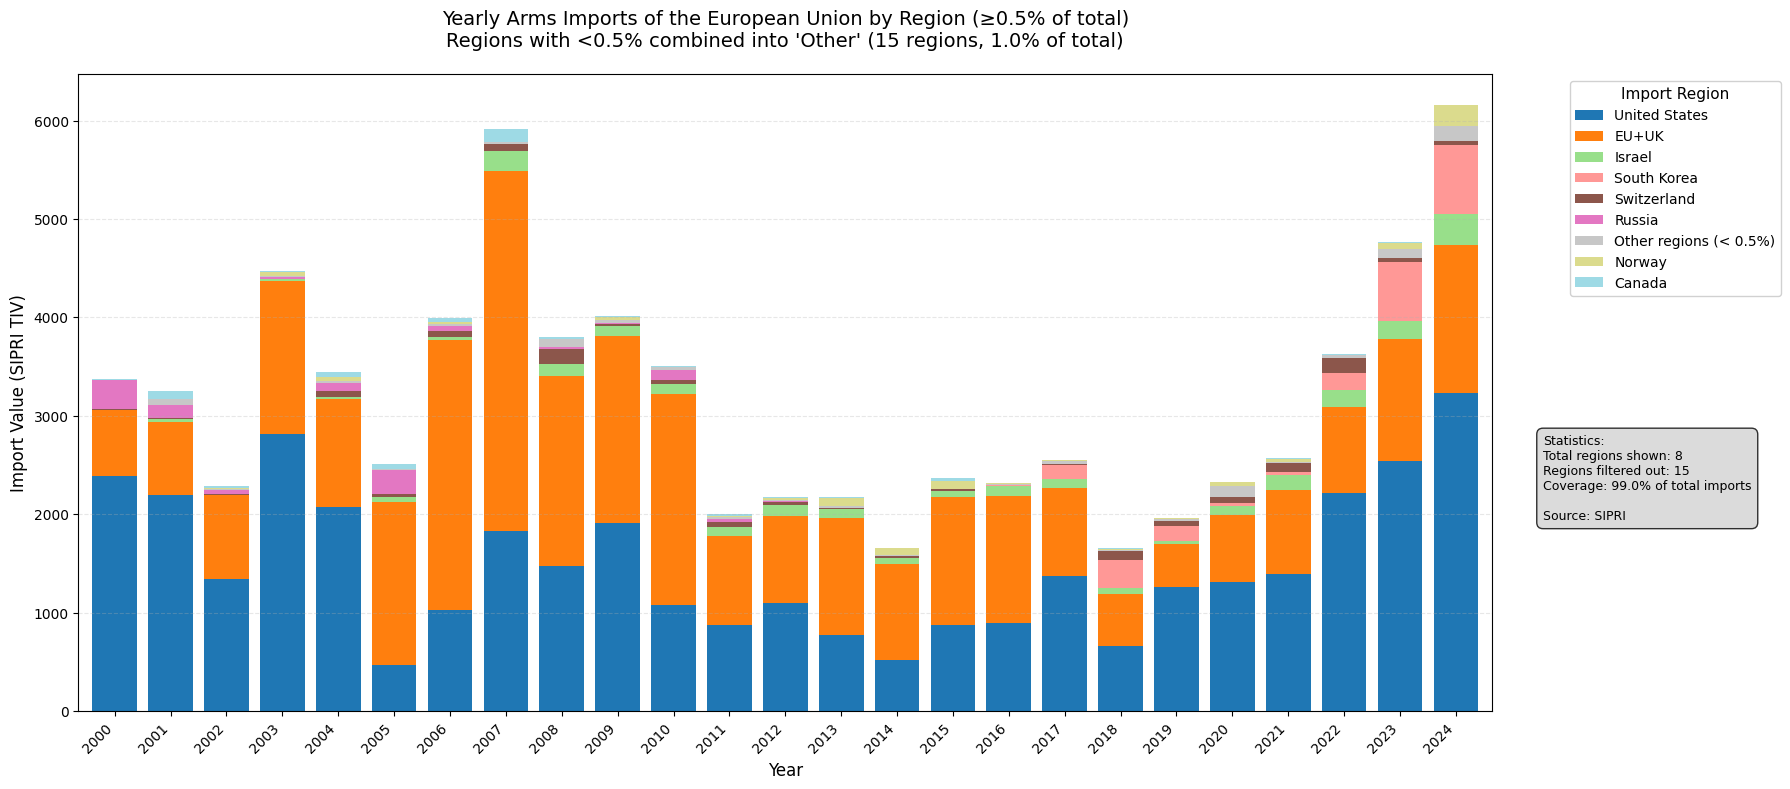

REGIONAL IMPORT ANALYSIS SUMMARY
Total regions in data: 23
Regions ≥0.5% threshold: 8
Regions <0.5% (filtered): 15
Coverage of significant regions: 99.0%

Top 5 regions by total imports:
1. United States: 47.7% of total
2. EU+UK: 41.2% of total
3. Israel: 2.9% of total
4. South Korea: 2.7% of total
5. Switzerland: 1.4% of total

Filtered regions (15 total, 1.0% combined):
  - Brazil: 0.40%
  - South Africa: 0.18%
  - Turkiye: 0.13%
  - Ukraine: 0.11%
  - Australia: 0.06%
  - Serbia: 0.05%
  - Singapore: 0.04%
  - China: 0.02%
  - Moldova: 0.02%
  - New Zealand: 0.01%
  - Jordan: 0.01%
  - Oman: 0.01%
  - Thailand: 0.01%
  - UAE: 0.00%
  - Bahamas: 0.00%


In [8]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter out rows without a region assignment (like "Regional total")
df_filtered = regional_transfers_df[(regional_transfers_df['import_region_EU'].notna()) & 
                                   (regional_transfers_df.organization == 'EC/EU')].copy()

# List of year columns (from your screenshot)
year_columns = [str(year) for year in range(2000, 2025)]

# Group by region and sum for each year
region_yearly = df_filtered.groupby('import_region_EU')[year_columns].sum()

# Calculate total imports per region across all years
region_totals = region_yearly.sum(axis=1).sort_values(ascending=False)

# Calculate percentage of total for each region
total_all_regions = region_totals.sum()
region_percentages = (region_totals / total_all_regions * 100).round(2)

# Filter out regions with less than 0.5% of total imports
significant_regions = region_percentages[region_percentages >= 0.5].index.tolist()
filtered_region_yearly = region_yearly.loc[significant_regions]

# Create a row for "Other regions" (< 0.5%)
other_regions = region_percentages[region_percentages < 0.5].index.tolist()
if other_regions:
    other_yearly = region_yearly.loc[other_regions].sum()
    # Add "Other regions" row
    filtered_region_yearly.loc['Other regions (< 0.5%)'] = other_yearly

# Transpose so years are X-axis and regions are stacks
filtered_region_yearly = filtered_region_yearly.T

# Sort columns by total value (descending) for better visualization
column_totals = filtered_region_yearly.sum().sort_values(ascending=False)
filtered_region_yearly = filtered_region_yearly[column_totals.index]

# Create the plot
plt.figure(figsize=(16, 8))  # Made slightly wider to accommodate right-side elements
ax = filtered_region_yearly.plot(kind='bar', stacked=True, figsize=(18, 8), 
                                 colormap='tab20', width=0.8)

# Calculate how many regions were filtered out
num_filtered = len(other_regions)
filtered_percentage = region_percentages[region_percentages < 0.5].sum().round(1)

# Create comprehensive title
plt.title(f"Yearly Arms Imports of the European Union by Region (≥0.5% of total)\n"
          f"Regions with <0.5% combined into 'Other' ({num_filtered} regions, {filtered_percentage}% of total)", 
          fontsize=14, pad=20)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Import Value (SIPRI TIV)", fontsize=12)

# Improve legend
legend = plt.legend(title="Import Region", bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=10, title_fontsize=11)
legend.set_frame_on(True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Add statistics text below the legend on the right side
stats_text = f"Statistics:\nTotal regions shown: {len(significant_regions)}\n"
stats_text += f"Regions filtered out: {num_filtered}\n"
stats_text += f"Coverage: {(100 - filtered_percentage):.1f}% of total imports\n\n"
stats_text += f"Source: SIPRI"

# Position the statistics box below the legend
plt.figtext(0.86, 0.45, stats_text, fontsize=9, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8),
           verticalalignment='top')

# Improve layout and grid
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.show()

# Print summary statistics
print("=" * 70)
print("REGIONAL IMPORT ANALYSIS SUMMARY")
print("=" * 70)
print(f"Total regions in data: {len(region_percentages)}")
print(f"Regions ≥0.5% threshold: {len(significant_regions)}")
print(f"Regions <0.5% (filtered): {num_filtered}")
print(f"Coverage of significant regions: {(100 - filtered_percentage):.1f}%")
print("\nTop 5 regions by total imports:")
for i, (region, pct) in enumerate(region_percentages.head().items(), 1):
    print(f"{i}. {region}: {pct:.1f}% of total")

if num_filtered > 0:
    print(f"\nFiltered regions ({num_filtered} total, {filtered_percentage:.1f}% combined):")
    for region, pct in region_percentages[region_percentages < 0.5].items():
        print(f"  - {region}: {pct:.2f}%")

<Figure size 1600x800 with 0 Axes>

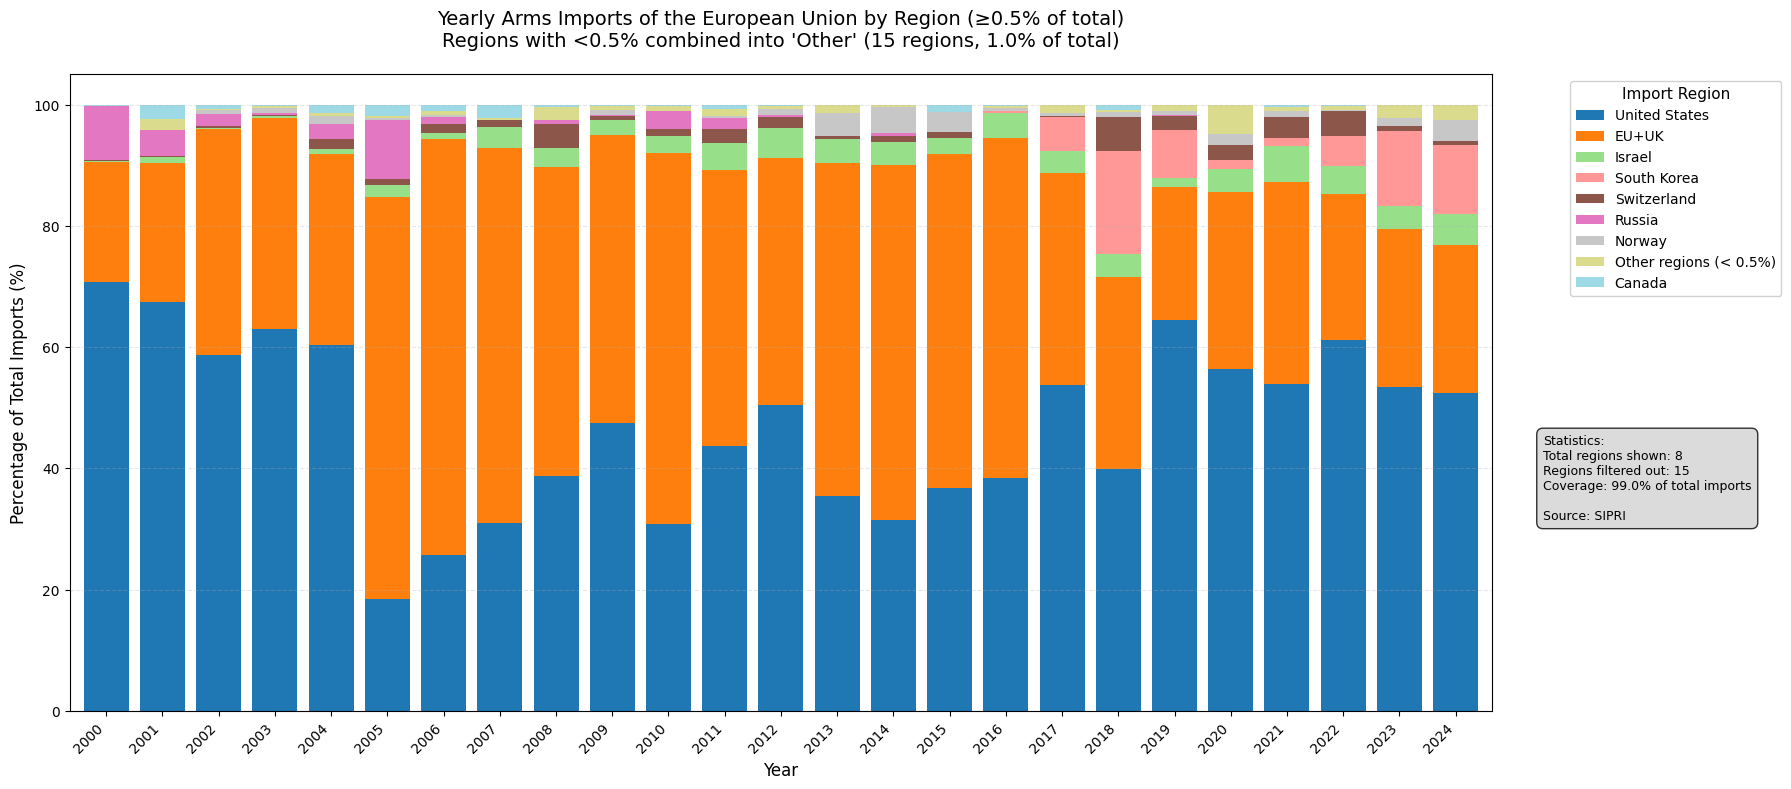

REGIONAL IMPORT ANALYSIS SUMMARY
Total regions in data: 23
Regions ≥0.5% threshold: 8
Regions <0.5% (filtered): 15
Coverage of significant regions: 99.0%

Top 5 regions by total imports:
1. United States: 47.7% of total
2. EU+UK: 41.2% of total
3. Israel: 2.9% of total
4. South Korea: 2.7% of total
5. Switzerland: 1.4% of total

Filtered regions (15 total, 1.0% combined):
  - Brazil: 0.40%
  - South Africa: 0.18%
  - Turkiye: 0.13%
  - Ukraine: 0.11%
  - Australia: 0.06%
  - Serbia: 0.05%
  - Singapore: 0.04%
  - China: 0.02%
  - Moldova: 0.02%
  - New Zealand: 0.01%
  - Jordan: 0.01%
  - Oman: 0.01%
  - Thailand: 0.01%
  - UAE: 0.00%
  - Bahamas: 0.00%


In [9]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter out rows without a region assignment (like "Regional total")
df_filtered = regional_transfers_df[(regional_transfers_df['import_region_EU'].notna()) & 
                                   (regional_transfers_df.organization == 'EC/EU')].copy()

# List of year columns (from your screenshot)
year_columns = [str(year) for year in range(2000, 2025)]

# Group by region and sum for each year
region_yearly = df_filtered.groupby('import_region_EU')[year_columns].sum()

# Calculate total imports per region across all years
region_totals = region_yearly.sum(axis=1).sort_values(ascending=False)

# Calculate percentage of total for each region
total_all_regions = region_totals.sum()
region_percentages = (region_totals / total_all_regions * 100).round(2)

# Filter out regions with less than 0.5% of total imports
significant_regions = region_percentages[region_percentages >= 0.5].index.tolist()
filtered_region_yearly = region_yearly.loc[significant_regions]

# Create a row for "Other regions" (< 0.5%)
other_regions = region_percentages[region_percentages < 0.5].index.tolist()
if other_regions:
    other_yearly = region_yearly.loc[other_regions].sum()
    # Add "Other regions" row
    filtered_region_yearly.loc['Other regions (< 0.5%)'] = other_yearly

# Transpose so years are X-axis and regions are stacks
filtered_region_yearly = filtered_region_yearly.T

# Convert to relative percentages (each year sums to 100%)
filtered_region_yearly = filtered_region_yearly.div(filtered_region_yearly.sum(axis=1), axis=0) * 100

# Sort columns by total value (descending) for better visualization
column_totals = filtered_region_yearly.sum().sort_values(ascending=False)
filtered_region_yearly = filtered_region_yearly[column_totals.index]

# Create the plot
plt.figure(figsize=(16, 8))  # Made slightly wider to accommodate right-side elements
ax = filtered_region_yearly.plot(kind='bar', stacked=True, figsize=(18, 8), 
                                 colormap='tab20', width=0.8)

# Calculate how many regions were filtered out
num_filtered = len(other_regions)
filtered_percentage = region_percentages[region_percentages < 0.5].sum().round(1)

# Create comprehensive title
plt.title(f"Yearly Arms Imports of the European Union by Region (≥0.5% of total)\n"
          f"Regions with <0.5% combined into 'Other' ({num_filtered} regions, {filtered_percentage}% of total)", 
          fontsize=14, pad=20)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Percentage of Total Imports (%)", fontsize=12)

# Improve legend
legend = plt.legend(title="Import Region", bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=10, title_fontsize=11)
legend.set_frame_on(True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Add statistics text below the legend on the right side
stats_text = f"Statistics:\nTotal regions shown: {len(significant_regions)}\n"
stats_text += f"Regions filtered out: {num_filtered}\n"
stats_text += f"Coverage: {(100 - filtered_percentage):.1f}% of total imports\n\n"
stats_text += f"Source: SIPRI"

# Position the statistics box below the legend
plt.figtext(0.86, 0.45, stats_text, fontsize=9, 
           bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgray", alpha=0.8),
           verticalalignment='top')

# Improve layout and grid
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

plt.show()

# Print summary statistics
print("=" * 70)
print("REGIONAL IMPORT ANALYSIS SUMMARY")
print("=" * 70)
print(f"Total regions in data: {len(region_percentages)}")
print(f"Regions ≥0.5% threshold: {len(significant_regions)}")
print(f"Regions <0.5% (filtered): {num_filtered}")
print(f"Coverage of significant regions: {(100 - filtered_percentage):.1f}%")
print("\nTop 5 regions by total imports:")
for i, (region, pct) in enumerate(region_percentages.head().items(), 1):
    print(f"{i}. {region}: {pct:.1f}% of total")

if num_filtered > 0:
    print(f"\nFiltered regions ({num_filtered} total, {filtered_percentage:.1f}% combined):")
    for region, pct in region_percentages[region_percentages < 0.5].items():
        print(f"  - {region}: {pct:.2f}%")

NameError: name 'num_other_regions' is not defined

<Figure size 1600x800 with 0 Axes>

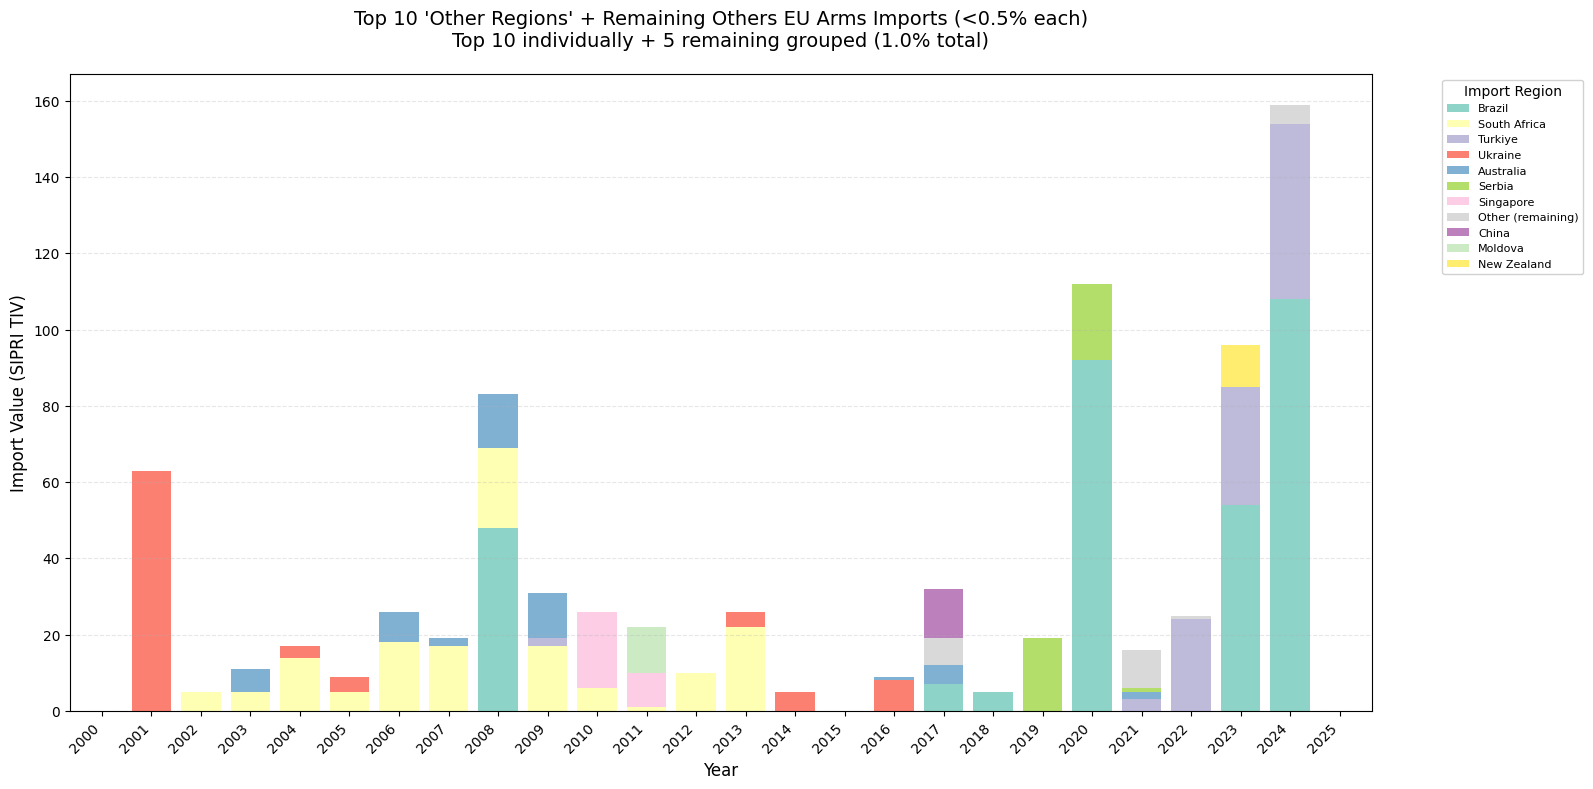

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter out rows without a region assignment (like "Regional total")
df_filtered = regional_transfers_df[(regional_transfers_df['import_region_EU'].notna()) & 
                                   (regional_transfers_df.organization == 'EC/EU')].copy()

# List of year columns (from your screenshot)
year_columns = [str(year) for year in range(2000, 2026)]

# Group by region and sum for each year
region_yearly = df_filtered.groupby('import_region_EU')[year_columns].sum()

# Calculate total imports per region across all years
region_totals = region_yearly.sum(axis=1).sort_values(ascending=False)

# Calculate percentage of total for each region
total_all_regions = region_totals.sum()
region_percentages = (region_totals / total_all_regions * 100).round(2)

# Get only the "other regions" (< 0.5%) and select top 10
other_regions_all = region_percentages[region_percentages < 0.5].sort_values(ascending=False)
top_10_other_regions = other_regions_all.head(10).index.tolist()
remaining_other_regions = other_regions_all.tail(-10).index.tolist()

# Get data for top 10 other regions
other_region_yearly = region_yearly.loc[top_10_other_regions]

# Add the remaining regions as a combined "Other (remaining)" category
if remaining_other_regions:
    remaining_yearly = region_yearly.loc[remaining_other_regions].sum()
    # Add as a new row
    other_region_yearly.loc['Other (remaining)'] = remaining_yearly

# Transpose so years are X-axis and regions are stacks
other_region_yearly = other_region_yearly.T

# Sort columns by total value (descending) for better visualization
column_totals = other_region_yearly.sum().sort_values(ascending=False)
other_region_yearly = other_region_yearly[column_totals.index]

# Create the plot
plt.figure(figsize=(16, 8))
ax = other_region_yearly.plot(kind='bar', stacked=True, figsize=(16, 8), 
                             colormap='Set3', width=0.8)

# Calculate statistics
num_other_regions_total = len(region_percentages[region_percentages < 0.5])
num_other_regions_shown = len(top_10_other_regions)
num_remaining_regions = len(remaining_other_regions)
top_10_percentage = other_regions_all.head(10).sum().round(1)
remaining_percentage = other_regions_all.tail(-10).sum().round(1) if remaining_other_regions else 0
other_total_percentage = region_percentages[region_percentages < 0.5].sum().round(1)
total_other_value = other_region_yearly.sum().sum()

# Create comprehensive title
title_text = f"Top 10 'Other Regions' + Remaining Others EU Arms Imports (<0.5% each)\n"
if num_remaining_regions > 0:
    title_text += f"Top 10 individually + {num_remaining_regions} remaining grouped ({other_total_percentage}% total)"
else:
    title_text += f"All {num_other_regions_shown} regions shown individually ({other_total_percentage}% total)"

plt.title(title_text, fontsize=14, pad=20)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Import Value (SIPRI TIV)", fontsize=12)

# Improve legend - use smaller font since there are many regions
legend = plt.legend(title="Import Region", bbox_to_anchor=(1.05, 1), loc='upper left', 
                   fontsize=8, title_fontsize=10, ncol=1)
legend.set_frame_on(True)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_alpha(0.9)

# Improve layout and grid
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)

# Rotate x-axis labels for better readability
plt.xticks(rotation=45, ha='right')

# Add some statistics as text
peak_year = other_region_yearly.sum(axis=1).idxmax()
peak_value = other_region_yearly.sum(axis=1).max()
avg_annual = other_region_yearly.sum(axis=1).mean()

stats_text = f"Total 'Other' regions: {num_other_regions}\n"
stats_text += f"Combined share: {other_total_percentage}% of EU total\n"
stats_text += f"Peak year: {peak_year} ({peak_value:.0f} TIV)\n"
stats_text += f"Annual average: {avg_annual:.0f} TIV"

plt.figtext(0.02, 0.02, stats_text, fontsize=9, 
           bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8))

plt.show()

# Print detailed analysis of "other regions"
print("=" * 80)
print("TOP 10 'OTHER REGIONS' + REMAINING ANALYSIS (<0.5% EACH)")
print("=" * 80)
print(f"Total 'other' regions: {num_other_regions_total}")
print(f"Top 10 shown individually: {top_10_percentage}% of EU total")
if num_remaining_regions > 0:
    print(f"Remaining {num_remaining_regions} grouped as 'Other': {remaining_percentage}% of EU total")
print(f"All others combined: {other_total_percentage}% of EU total")

print(f"\nTop 10 'Other' regions ranked by total imports:")
for i, (region, pct) in enumerate(other_regions_all.head(10).items(), 1):
    total_tiv = region_totals[region]
    print(f"{i:2d}. {region:<25} {pct:5.2f}% ({total_tiv:6.0f} TIV)")

if num_remaining_regions > 0:
    print(f"\nRemaining {num_remaining_regions} regions grouped as 'Other (remaining)': {remaining_percentage:.2f}% combined")
    print(f"   Individual range: {other_regions_all.tail(-10).max():.3f}% to {other_regions_all.tail(-10).min():.3f}%")

# Find most active years for top 10 "other regions"
print(f"\n" + "=" * 60)
print("TEMPORAL ANALYSIS OF TOP 10 'OTHER REGIONS'")
print("=" * 60)

yearly_totals = other_region_yearly.sum(axis=1).sort_values(ascending=False)
print(f"\nTop 5 years for 'other regions' imports:")
for i, (year, value) in enumerate(yearly_totals.head().items(), 1):
    print(f"{i}. {year}: {value:.0f} TIV")

print(f"\nLowest 5 years:")
for i, (year, value) in enumerate(yearly_totals.tail().items(), 1):
    print(f"{i}. {year}: {value:.0f} TIV")

# Most active "other" region by year among top 10
print(f"\n" + "=" * 60)
print("MOST ACTIVE TOP 10 'OTHER' REGION BY YEAR")
print("=" * 60)

for year in range(2000, 2026, 5):  # Show every 5 years
    year_str = str(year)
    if year_str in other_region_yearly.index:
        year_data = other_region_yearly.loc[year_str]
        if year_data.sum() > 0:  # Only if there were imports that year
            top_region = year_data.idxmax()
            top_value = year_data.max()
            print(f"{year}: {top_region} ({top_value:.0f} TIV)")

# Calculate diversity index for top 10 "other regions"
print(f"\n" + "=" * 60)
print("DIVERSITY ANALYSIS - TOP 10 ONLY")
print("=" * 60)

# Count how many top 10 "other" regions were active (>0 imports) each year
active_regions_per_year = (other_region_yearly > 0).sum(axis=1)
print(f"Average number of active top 10 'other' regions per year: {active_regions_per_year.mean():.1f}")
print(f"Most diverse year: {active_regions_per_year.idxmax()} ({active_regions_per_year.max()} active regions)")
print(f"Least diverse year: {active_regions_per_year.idxmin()} ({active_regions_per_year.min()} active regions)")

# **SIPRI EU IMPORT DATA (Not Sure About Completeness Data)**

A deal is only included in a Transfer Register if reliable information has been verified that an order has been placed or deliveries have begun.

In [12]:
# Country to Region Mapping Dictionary
# EU 27 + UK mapped to 'EU+UK', US and Russia to themselves, others to regions

country_mapping = {
    # EU 27 countries + UK -> 'EU+UK'
    'Germany': 'EU+UK',
    'Sweden': 'EU+UK',
    'Italy': 'EU+UK',
    'Spain': 'EU+UK',
    'Belgium': 'EU+UK',
    'United Kingdom': 'EU+UK',
    'France': 'EU+UK',
    'Portugal': 'EU+UK',
    'Netherlands': 'EU+UK',
    'Austria': 'EU+UK',
    'Poland': 'EU+UK',
    'Czechia': 'EU+UK',
    'Finland': 'EU+UK',
    'Slovakia': 'EU+UK',
    'Greece': 'EU+UK',
    'Bulgaria': 'EU+UK',
    'Denmark': 'EU+UK',
    'Croatia': 'EU+UK',
    'Ireland': 'EU+UK',
    'Hungary': 'EU+UK',
    'Romania': 'EU+UK',
    'Lithuania': 'EU+UK',
    'Latvia': 'EU+UK',
    'Slovenia': 'EU+UK',
    'Estonia': 'EU+UK',
    'Cyprus': 'EU+UK',
    'Luxembourg': 'EU+UK',
    'Malta': 'EU+UK',
    
    # US and Russia mapped to themselves
    'United States': 'United States',
    'Russia': 'Russia',
    
    # Middle East & North Africa
    'Jordan': 'Middle East & North Africa',
    'Israel': 'Middle East & North Africa',
    'UAE': 'Middle East & North Africa',
    'Oman': 'Middle East & North Africa',
    'Kuwait': 'Middle East & North Africa',
    'Tunisia': 'Middle East & North Africa',
    'Saudi Arabia': 'Middle East & North Africa',
    'Bahrain': 'Middle East & North Africa',
    'Lebanon': 'Middle East & North Africa',
    'Iraq': 'Middle East & North Africa',
    'Algeria': 'Middle East & North Africa',
    'Yemen': 'Middle East & North Africa',
    'Qatar': 'Middle East & North Africa',
    'Morocco': 'Middle East & North Africa',
    'Libya': 'Middle East & North Africa',
    'Egypt': 'Middle East & North Africa',
    'HoR (Libya)*': 'Middle East & North Africa',
    'Sudan': 'Middle East & North Africa',
    
    # Asia-Pacific
    'South Korea': 'Asia-Pacific',
    'Thailand': 'Asia-Pacific',
    'Australia': 'Asia-Pacific',
    'China': 'Asia-Pacific',
    'Singapore': 'Asia-Pacific',
    'Bangladesh': 'Asia-Pacific',
    'Indonesia': 'Asia-Pacific',
    'Malaysia': 'Asia-Pacific',
    'Myanmar': 'Asia-Pacific',
    'Philippines': 'Asia-Pacific',
    'Pakistan': 'Asia-Pacific',
    'India': 'Asia-Pacific',
    'Viet Nam': 'Asia-Pacific',
    'Sri Lanka': 'Asia-Pacific',
    'Nepal': 'Asia-Pacific',
    'Brunei': 'Asia-Pacific',
    'Taiwan': 'Asia-Pacific',
    'Laos': 'Asia-Pacific',
    'Bhutan': 'Asia-Pacific',
    'Japan': 'Asia-Pacific',
    'Cambodia': 'Asia-Pacific',
    
    # Central Asia & Eastern Europe
    'Kyrgyzstan': 'Central Asia & Eastern Europe',
    'Ukraine': 'Central Asia & Eastern Europe',
    'Serbia': 'Central Asia & Eastern Europe',
    'Moldova': 'Central Asia & Eastern Europe',
    'Turkmenistan': 'Central Asia & Eastern Europe',
    'Montenegro': 'Central Asia & Eastern Europe',
    'Tajikistan': 'Central Asia & Eastern Europe',
    'Georgia': 'Central Asia & Eastern Europe',
    'Azerbaijan': 'Central Asia & Eastern Europe',
    'Kazakhstan': 'Central Asia & Eastern Europe',
    'Uzbekistan': 'Central Asia & Eastern Europe',
    'Albania': 'Central Asia & Eastern Europe',
    'North Macedonia': 'Central Asia & Eastern Europe',
    'Armenia': 'Central Asia & Eastern Europe',
    'Turkiye': 'Central Asia & Eastern Europe',
    
    # Sub-Saharan Africa
    'South Africa': 'Sub-Saharan Africa',
    'Zimbabwe': 'Sub-Saharan Africa',
    'Niger': 'Sub-Saharan Africa',
    'Uganda': 'Sub-Saharan Africa',
    'Burkina Faso': 'Sub-Saharan Africa',
    'Nigeria': 'Sub-Saharan Africa',
    'Botswana': 'Sub-Saharan Africa',
    'Gabon': 'Sub-Saharan Africa',
    'Ghana': 'Sub-Saharan Africa',
    'DR Congo': 'Sub-Saharan Africa',
    'Benin': 'Sub-Saharan Africa',
    'Chad': 'Sub-Saharan Africa',
    'Mali': 'Sub-Saharan Africa',
    'Angola': 'Sub-Saharan Africa',
    "Cote d'Ivoire": 'Sub-Saharan Africa',
    'Senegal': 'Sub-Saharan Africa',
    'Ethiopia': 'Sub-Saharan Africa',
    'Eritrea': 'Sub-Saharan Africa',
    'Guinea': 'Sub-Saharan Africa',
    'Equatorial Guinea': 'Sub-Saharan Africa',
    'Kenya': 'Sub-Saharan Africa',
    'Mozambique': 'Sub-Saharan Africa',
    'Mauritania': 'Sub-Saharan Africa',
    'Cameroon': 'Sub-Saharan Africa',
    'Lesotho': 'Sub-Saharan Africa',
    'Tanzania': 'Sub-Saharan Africa',
    'Togo': 'Sub-Saharan Africa',
    'Djibouti': 'Sub-Saharan Africa',
    'Somalia': 'Sub-Saharan Africa',
    'Congo': 'Sub-Saharan Africa',
    'Zambia': 'Sub-Saharan Africa',
    'Namibia': 'Sub-Saharan Africa',
    'Cabo Verde': 'Sub-Saharan Africa',
    'Rwanda': 'Sub-Saharan Africa',
    'Central African Republic': 'Sub-Saharan Africa',
    
    # Americas
    'Canada': 'Americas',
    'Brazil': 'Americas',
    'New Zealand': 'Americas',  # Note: New Zealand is geographically Oceania but grouped here
    'Argentina': 'Americas',
    'Venezuela': 'Americas',
    'Jamaica': 'Americas',
    'Bolivia': 'Americas',
    'Chile': 'Americas',
    'Uruguay': 'Americas',
    'Mexico': 'Americas',
    'Peru': 'Americas',
    'Colombia': 'Americas',
    'Suriname': 'Americas',
    'Honduras': 'Americas',
    'Dominican Republic': 'Americas',
    'Barbados': 'Americas',
    'Trinidad and Tobago': 'Americas',
    'Nicaragua': 'Americas',
    'Guatemala': 'Americas',
    'El Salvador': 'Americas',
    'Paraguay': 'Americas',
    'Ecuador': 'Americas',
    
    # Caribbean & Small Islands
    'Bahamas': 'Caribbean & Small Islands',
    
    # Non-state entities and special cases
    'Switzerland': 'Other European',
    'Norway': 'Other European',
    'Afghanistan': 'Other',
    'unknown supplier(s)': 'Unknown',
    'unknown recipient(s)': 'Unknown',
    'OSCE**': 'International Organizations',
    'United Nations**': 'International Organizations',
    'NATO**': 'International Organizations'
}

# Print summary statistics
print("Country Mapping Summary:")
print(f"Total countries/entities: {len(country_mapping)}")
print(f"EU+UK countries: {sum(1 for v in country_mapping.values() if v == 'EU+UK')}")
print(f"Unique regions: {len(set(country_mapping.values()))}")
print("\nRegion breakdown:")
for region in sorted(set(country_mapping.values())):
    count = sum(1 for v in country_mapping.values() if v == region)
    print(f"  {region}: {count} countries")

Country Mapping Summary:
Total countries/entities: 150
EU+UK countries: 28
Unique regions: 13

Region breakdown:
  Americas: 22 countries
  Asia-Pacific: 21 countries
  Caribbean & Small Islands: 1 countries
  Central Asia & Eastern Europe: 15 countries
  EU+UK: 28 countries
  International Organizations: 3 countries
  Middle East & North Africa: 18 countries
  Other: 1 countries
  Other European: 2 countries
  Russia: 1 countries
  Sub-Saharan Africa: 35 countries
  United States: 1 countries
  Unknown: 2 countries


In [13]:
export_df['Recipient_region_EU'] = export_df['Recipient'].map(country_mapping)
import_df['Supplier_region_EU'] = import_df['Supplier'].map(country_mapping)

In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def create_supplier_armament_chart(df, supplier_region):
    """
    Create stacked bar chart for TIV delivery values by armament category over order dates
    for a specific supplier region (showing EU+UK imports)
    
    Parameters:
    df: DataFrame with columns including 'Supplier_region_EU', 'Order date', 'Armament category', 'TIV delivery values'
    supplier_region: Name of the supplier region to analyze
    """
    
    # Clean the data
    df_clean = df.copy()
    
    # Convert TIV delivery values to numeric, handle NaN
    df_clean['TIV delivery values'] = pd.to_numeric(df_clean['TIV delivery values'], errors='coerce').fillna(0)
    
    # Convert Order date to numeric year
    df_clean['Order date'] = pd.to_numeric(df_clean['Order date'], errors='coerce')
    
    # Remove rows with missing essential data
    df_clean = df_clean.dropna(subset=['Supplier_region_EU', 'Order date', 'Armament category'])
    
    # Filter to reasonable year range
    df_clean = df_clean[(df_clean['Order date'] >= 2000) & (df_clean['Order date'] <= 2025)]
    
    # Filter data for this supplier region
    supplier_data = df_clean[df_clean['Supplier_region_EU'] == supplier_region].copy()
    
    if len(supplier_data) == 0:
        print(f"No data found for supplier region: {supplier_region}")
        print(f"Available supplier regions: {sorted(df_clean['Supplier_region_EU'].unique())}")
        return
    
    # Group by order date and armament category, sum TIV values
    pivot_data = supplier_data.groupby(['Order date', 'Armament category'])['TIV delivery values'].sum().unstack(fill_value=0)
    
    if pivot_data.empty:
        print(f"No valid data for supplier region: {supplier_region}")
        return
    
    # Create the plot using DataFrame's built-in plotting
    fig, ax = plt.subplots(figsize=(16, 8))  # Made wider for the info box
    
    # Use pandas built-in stacked bar plot
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', alpha=0.8)
    
    # Calculate statistics
    total_tiv = supplier_data['TIV delivery values'].sum()
    n_countries = supplier_data['Recipient'].nunique() if 'Recipient' in supplier_data.columns else 'N/A'
    n_armament_types = supplier_data['Armament category'].nunique()
    date_range = f"{supplier_data['Order date'].min():.0f}-{supplier_data['Order date'].max():.0f}"
    
    # Customize the plot
    ax.set_title(f'EU+UK Arms Imports from {supplier_region} by Armament Category Over Time\n'
                f'Total: {total_tiv:.1f} TIV | Period: {date_range} | EU Countries: {n_countries} | Armament Types: {n_armament_types}', 
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xlabel('Order Date (Year)', fontsize=12)
    ax.set_ylabel('TIV Delivery Values', fontsize=12)
    
    # Format x-axis
    ax.tick_params(axis='x', rotation=45)
    
    # Add legend
    legend = ax.legend(title='Armament Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Calculate armament category breakdown for info box
    armament_totals = supplier_data.groupby('Armament category')['TIV delivery values'].sum().sort_values(ascending=False)
    
    # Create info box text with armament breakdown
    info_text = "Armament Category Breakdown:\n"
    info_text += "=" * 35 + "\n"
    
    # Show top 8 categories to avoid overcrowding
    top_categories = armament_totals.head(8)
    for armament, total in top_categories.items():
        percentage = (total / total_tiv) * 100
        # Truncate long armament names for better display
        display_name = armament if len(armament) <= 20 else armament[:17] + "..."
        info_text += f"{display_name:<20} {percentage:5.1f}%\n"
    
    # If there are more than 8 categories, show "Others"
    if len(armament_totals) > 8:
        others_total = armament_totals.iloc[8:].sum()
        others_percentage = (others_total / total_tiv) * 100
        info_text += f"{'Others':<20} {others_percentage:5.1f}%\n"
    
    info_text += "\nSource: SIPRI"
    
    # Position the info box below the legend
    plt.figtext(0.86, 0.45, info_text, fontsize=9, 
               bbox=dict(boxstyle="round,pad=0.5", facecolor="lightblue", alpha=0.8),
               verticalalignment='top', fontfamily='monospace')
    
    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    
    # Print summary statistics
    print(f"\nEU+UK Arms Imports from {supplier_region} - Armament Category Breakdown:")
    print("="*70)
    
    print(f"Overall Statistics:")
    print(f"Total TIV Value: {total_tiv:.1f}")
    print(f"EU+UK Countries importing: {n_countries}")
    print(f"Armament Categories: {n_armament_types}")
    print(f"Time Period: {date_range}")
    
    print(f"\nArmament Category Breakdown:")
    for armament, total in armament_totals.items():
        percentage = (total / total_tiv) * 100
        print(f"{armament:30} {total:8.1f} TIV ({percentage:5.1f}%)")
    
    # Show top importing EU countries from this supplier
    if 'Recipient' in supplier_data.columns:
        print(f"\nTop 10 EU+UK Countries importing from {supplier_region}:")
        country_totals = supplier_data.groupby('Recipient')['TIV delivery values'].sum().sort_values(ascending=False)
        for i, (country, total) in enumerate(country_totals.head(10).items(), 1):
            percentage = (total / total_tiv) * 100
            print(f"{i:2d}. {country:20} {total:8.1f} TIV ({percentage:5.1f}%)")

# Check if the dataframes exist and show available supplier regions
try:
    if 'import_df' in globals() and import_df is not None:
        print("Available supplier regions:")
        suppliers = sorted(import_df['Supplier_region_EU'].unique())
        for i, supplier in enumerate(suppliers, 1):
            print(f"{i:2d}. {supplier}")
        
        print(f"\nUsage: create_supplier_armament_chart(import_df, 'SupplierRegion')")
        print(f"Example: create_supplier_armament_chart(import_df, 'United States')")
        print(f"Example: create_supplier_armament_chart(import_df, 'EU+UK')")
        
    else:
        print("import_df not available. Please load the import data first.")
        
except Exception as e:
    print(f"Error: {e}")

Available supplier regions:
 1. Americas
 2. Asia-Pacific
 3. Caribbean & Small Islands
 4. Central Asia & Eastern Europe
 5. EU+UK
 6. Middle East & North Africa
 7. Other European
 8. Russia
 9. Sub-Saharan Africa
10. United States
11. Unknown

Usage: create_supplier_armament_chart(import_df, 'SupplierRegion')
Example: create_supplier_armament_chart(import_df, 'United States')
Example: create_supplier_armament_chart(import_df, 'EU+UK')


In [15]:
import_df.Supplier_region_EU.unique()

array(['EU+UK', 'United States', 'Other European',
       'Middle East & North Africa', 'Americas', 'Russia',
       'Central Asia & Eastern Europe', 'Sub-Saharan Africa', 'Unknown',
       'Caribbean & Small Islands', 'Asia-Pacific'], dtype=object)

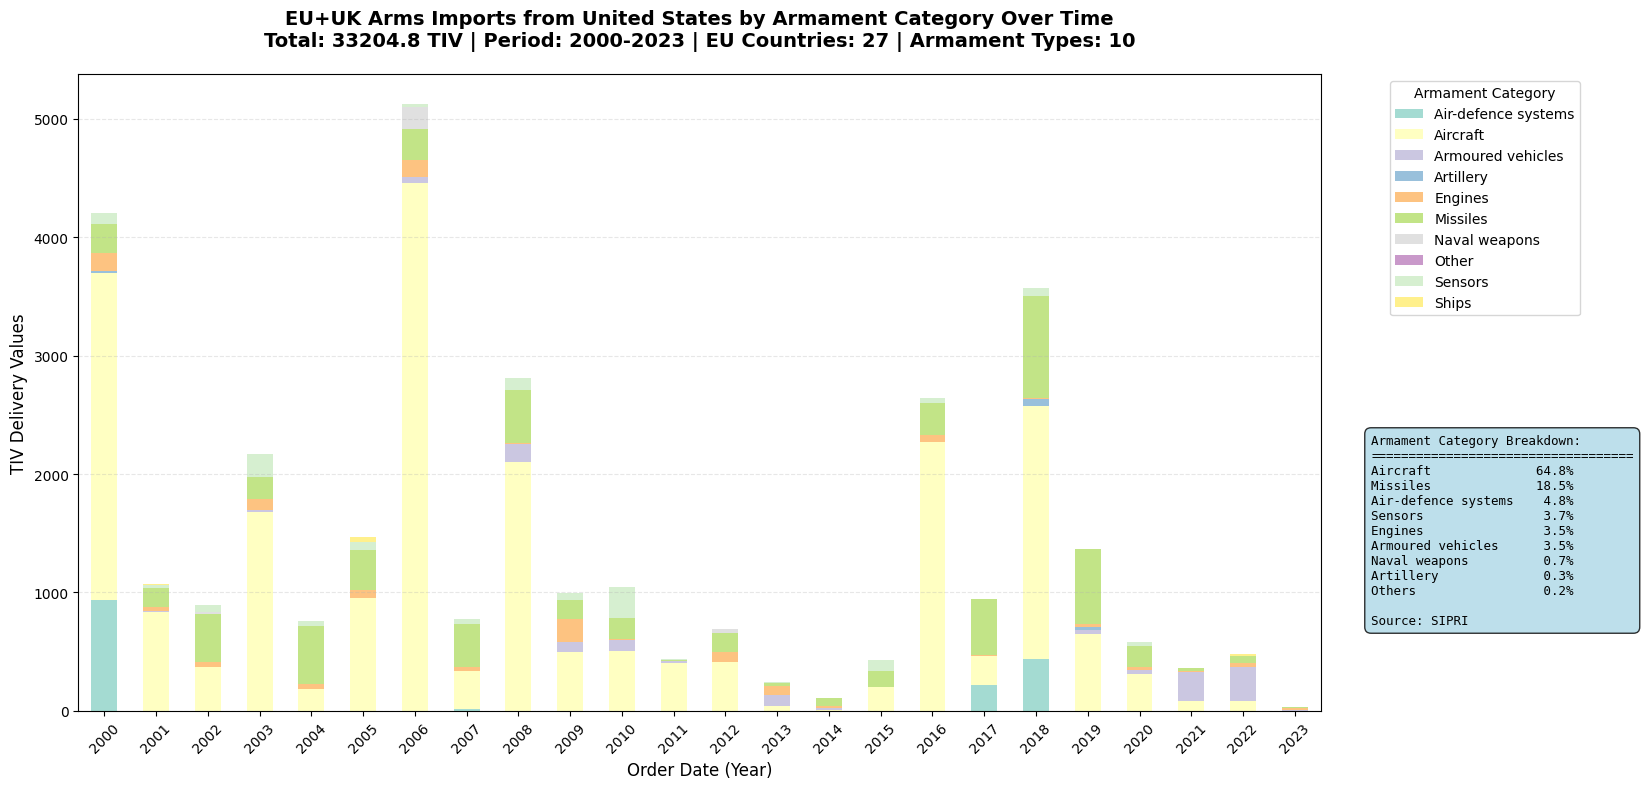


EU+UK Arms Imports from United States - Armament Category Breakdown:
Overall Statistics:
Total TIV Value: 33204.8
EU+UK Countries importing: 27
Armament Categories: 10
Time Period: 2000-2023

Armament Category Breakdown:
Aircraft                        21513.6 TIV ( 64.8%)
Missiles                         6126.4 TIV ( 18.5%)
Air-defence systems              1609.0 TIV (  4.8%)
Sensors                          1217.0 TIV (  3.7%)
Engines                          1176.0 TIV (  3.5%)
Armoured vehicles                1151.6 TIV (  3.5%)
Naval weapons                     239.5 TIV (  0.7%)
Artillery                         104.2 TIV (  0.3%)
Ships                              66.5 TIV (  0.2%)
Other                               0.8 TIV (  0.0%)

Top 10 EU+UK Countries importing from United States:
 1. United Kingdom         8154.5 TIV ( 24.6%)
 2. Italy                  4211.6 TIV ( 12.7%)
 3. Greece                 4204.1 TIV ( 12.7%)
 4. Netherlands            3858.0 TIV ( 11.6%)
 5. Po

In [16]:
create_supplier_armament_chart(import_df, 'United States')

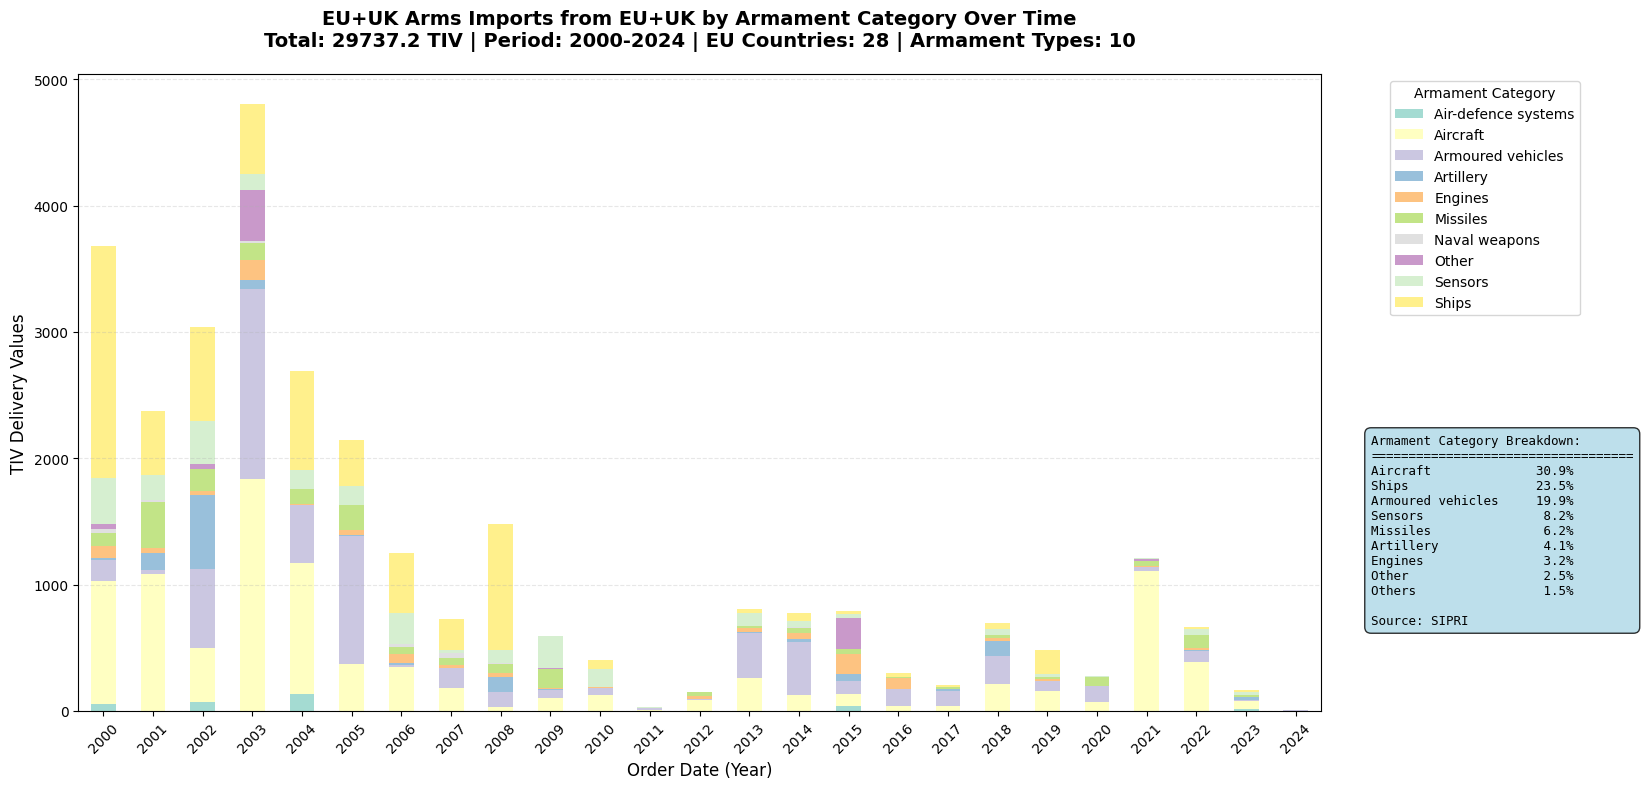


EU+UK Arms Imports from EU+UK - Armament Category Breakdown:
Overall Statistics:
Total TIV Value: 29737.2
EU+UK Countries importing: 28
Armament Categories: 10
Time Period: 2000-2024

Armament Category Breakdown:
Aircraft                         9175.3 TIV ( 30.9%)
Ships                            7000.1 TIV ( 23.5%)
Armoured vehicles                5922.5 TIV ( 19.9%)
Sensors                          2451.4 TIV (  8.2%)
Missiles                         1835.4 TIV (  6.2%)
Artillery                        1209.3 TIV (  4.1%)
Engines                           951.8 TIV (  3.2%)
Other                             752.2 TIV (  2.5%)
Air-defence systems               304.9 TIV (  1.0%)
Naval weapons                     134.2 TIV (  0.5%)

Top 10 EU+UK Countries importing from EU+UK:
 1. Greece                 7045.3 TIV ( 23.7%)
 2. Poland                 2473.8 TIV (  8.3%)
 3. United Kingdom         2129.0 TIV (  7.2%)
 4. Portugal               1597.5 TIV (  5.4%)
 5. Netherlands       

In [24]:
create_supplier_armament_chart(import_df, 'EU+UK')

In [17]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def create_supplier_armament_chart(df, supplier_region, eu_suppliers_only=True):
    """
    Create stacked bar chart for TIV delivery values by armament category over order dates
    for specific supplier region(s) - showing EU+UK imports
    
    Parameters:
    df: DataFrame with columns including 'Supplier_region_EU', 'Order date', 'Armament category', 'TIV delivery values'
    supplier_region: Name of the supplier region to analyze (or 'All' for all suppliers)
    eu_suppliers_only: If True, shows only EU+UK suppliers. If False, shows only non-EU+UK suppliers
    """
    
    # Clean the data
    df_clean = df.copy()
    
    # Convert TIV delivery values to numeric, handle NaN
    df_clean['TIV delivery values'] = pd.to_numeric(df_clean['TIV delivery values'], errors='coerce').fillna(0)
    
    # Convert Order date to numeric year
    df_clean['Order date'] = pd.to_numeric(df_clean['Order date'], errors='coerce')
    
    # Remove rows with missing essential data
    df_clean = df_clean.dropna(subset=['Supplier_region_EU', 'Order date', 'Armament category'])
    
    # Filter to reasonable year range
    df_clean = df_clean[(df_clean['Order date'] >= 2000) & (df_clean['Order date'] <= 2025)]
    
    # Filter by supplier region first
    if supplier_region == 'All':
        # Filter by EU/non-EU suppliers
        if eu_suppliers_only:
            # Show only EU+UK suppliers
            supplier_data = df_clean[df_clean['Supplier_region_EU'] == 'EU+UK']
            supplier_label = "EU+UK Suppliers"
        else:
            # Show all suppliers except EU+UK
            supplier_data = df_clean[df_clean['Supplier_region_EU'] != 'EU+UK']
            supplier_label = "Non-EU+UK Suppliers"
    else:
        # Show specific supplier region
        supplier_data = df_clean[df_clean['Supplier_region_EU'] == supplier_region].copy()
        supplier_label = supplier_region
    
    if len(supplier_data) == 0:
        print(f"No data found for: {supplier_label}")
        print(f"Available supplier regions: {sorted(df_clean['Supplier_region_EU'].unique())}")
        return
    
    # Group by order date and armament category, sum TIV values
    pivot_data = supplier_data.groupby(['Order date', 'Armament category'])['TIV delivery values'].sum().unstack(fill_value=0)
    
    if pivot_data.empty:
        print(f"No valid data for: {supplier_label}")
        return
    
    # Create the plot using DataFrame's built-in plotting
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Use pandas built-in stacked bar plot
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', alpha=0.8)
    
    # Calculate statistics
    total_tiv = supplier_data['TIV delivery values'].sum()
    n_countries = supplier_data['Recipient'].nunique() if 'Recipient' in supplier_data.columns else 'N/A'
    n_armament_types = supplier_data['Armament category'].nunique()
    date_range = f"{supplier_data['Order date'].min():.0f}-{supplier_data['Order date'].max():.0f}"
    
    # Create appropriate title
    if supplier_region == 'All':
        title = f'EU+UK Arms Imports from {supplier_label} by Armament Category Over Time'
    else:
        title = f'EU+UK Arms Imports from {supplier_label} by Armament Category Over Time'
    
    ax.set_title(f'{title}\n'
                f'Total: {total_tiv:.1f} TIV | Period: {date_range} | EU Countries: {n_countries} | Armament Types: {n_armament_types}', 
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xlabel('Order Date (Year)', fontsize=12)
    ax.set_ylabel('TIV Delivery Values', fontsize=12)
    
    # Format x-axis
    ax.tick_params(axis='x', rotation=45)
    
    # Add legend
    ax.legend(title='Armament Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    
    # Print summary statistics
    print(f"\nEU+UK Arms Imports from {supplier_label} - Armament Category Breakdown:")
    print("="*70)
    armament_totals = supplier_data.groupby('Armament category')['TIV delivery values'].sum().sort_values(ascending=False)
    
    print(f"Overall Statistics:")
    print(f"Total TIV Value: {total_tiv:.1f}")
    print(f"EU Countries importing: {n_countries}")
    print(f"Armament Categories: {n_armament_types}")
    print(f"Time Period: {date_range}")
    
    print(f"\nArmament Category Breakdown:")
    for armament, total in armament_totals.items():
        percentage = (total / total_tiv) * 100
        print(f"{armament:30} {total:8.1f} TIV ({percentage:5.1f}%)")
    
    # Show top importing EU countries from this supplier
    if 'Recipient' in supplier_data.columns:
        print(f"\nTop 10 EU Countries importing from {supplier_label}:")
        country_totals = supplier_data.groupby('Recipient')['TIV delivery values'].sum().sort_values(ascending=False)
        for i, (country, total) in enumerate(country_totals.head(10).items(), 1):
            percentage = (total / total_tiv) * 100
            print(f"{i:2d}. {country:20} {total:8.1f} TIV ({percentage:5.1f}%)")
    
    # If analyzing all suppliers, show breakdown by supplier region
    if supplier_region == 'All':
        print(f"\nBreakdown by Supplier Region within {supplier_label}:")
        supplier_region_totals = supplier_data.groupby('Supplier_region_EU')['TIV delivery values'].sum().sort_values(ascending=False)
        for supplier, total in supplier_region_totals.items():
            percentage = (total / total_tiv) * 100
            print(f"{supplier:25} {total:8.1f} TIV ({percentage:5.1f}%)")

# Check if the dataframes exist and show available supplier regions
try:
    if 'import_df' in globals() and import_df is not None:
        print("Available supplier regions:")
        suppliers = sorted(import_df['Supplier_region_EU'].unique())
        for i, supplier in enumerate(suppliers, 1):
            print(f"{i:2d}. {supplier}")
        
        print(f"\nUsage: create_supplier_armament_chart(import_df, supplier_region, eu_suppliers_only=True/False)")
        print(f"\nExamples:")
        print(f"# EU+UK imports from United States:")
        print(f"create_supplier_armament_chart(import_df, 'United States')")
        print(f"\n# EU+UK imports from all EU+UK suppliers (intra-European trade):")
        print(f"create_supplier_armament_chart(import_df, 'All', eu_suppliers_only=True)")
        print(f"\n# EU+UK imports from all non-EU+UK suppliers:")
        print(f"create_supplier_armament_chart(import_df, 'All', eu_suppliers_only=False)")
        print(f"\n# EU+UK imports from Russia:")
        print(f"create_supplier_armament_chart(import_df, 'Russia')")
        
    else:
        print("import_df not available. Please load the import data first.")
        
except Exception as e:
    print(f"Error: {e}")

Available supplier regions:
 1. Americas
 2. Asia-Pacific
 3. Caribbean & Small Islands
 4. Central Asia & Eastern Europe
 5. EU+UK
 6. Middle East & North Africa
 7. Other European
 8. Russia
 9. Sub-Saharan Africa
10. United States
11. Unknown

Usage: create_supplier_armament_chart(import_df, supplier_region, eu_suppliers_only=True/False)

Examples:
# EU+UK imports from United States:
create_supplier_armament_chart(import_df, 'United States')

# EU+UK imports from all EU+UK suppliers (intra-European trade):
create_supplier_armament_chart(import_df, 'All', eu_suppliers_only=True)

# EU+UK imports from all non-EU+UK suppliers:
create_supplier_armament_chart(import_df, 'All', eu_suppliers_only=False)

# EU+UK imports from Russia:
create_supplier_armament_chart(import_df, 'Russia')


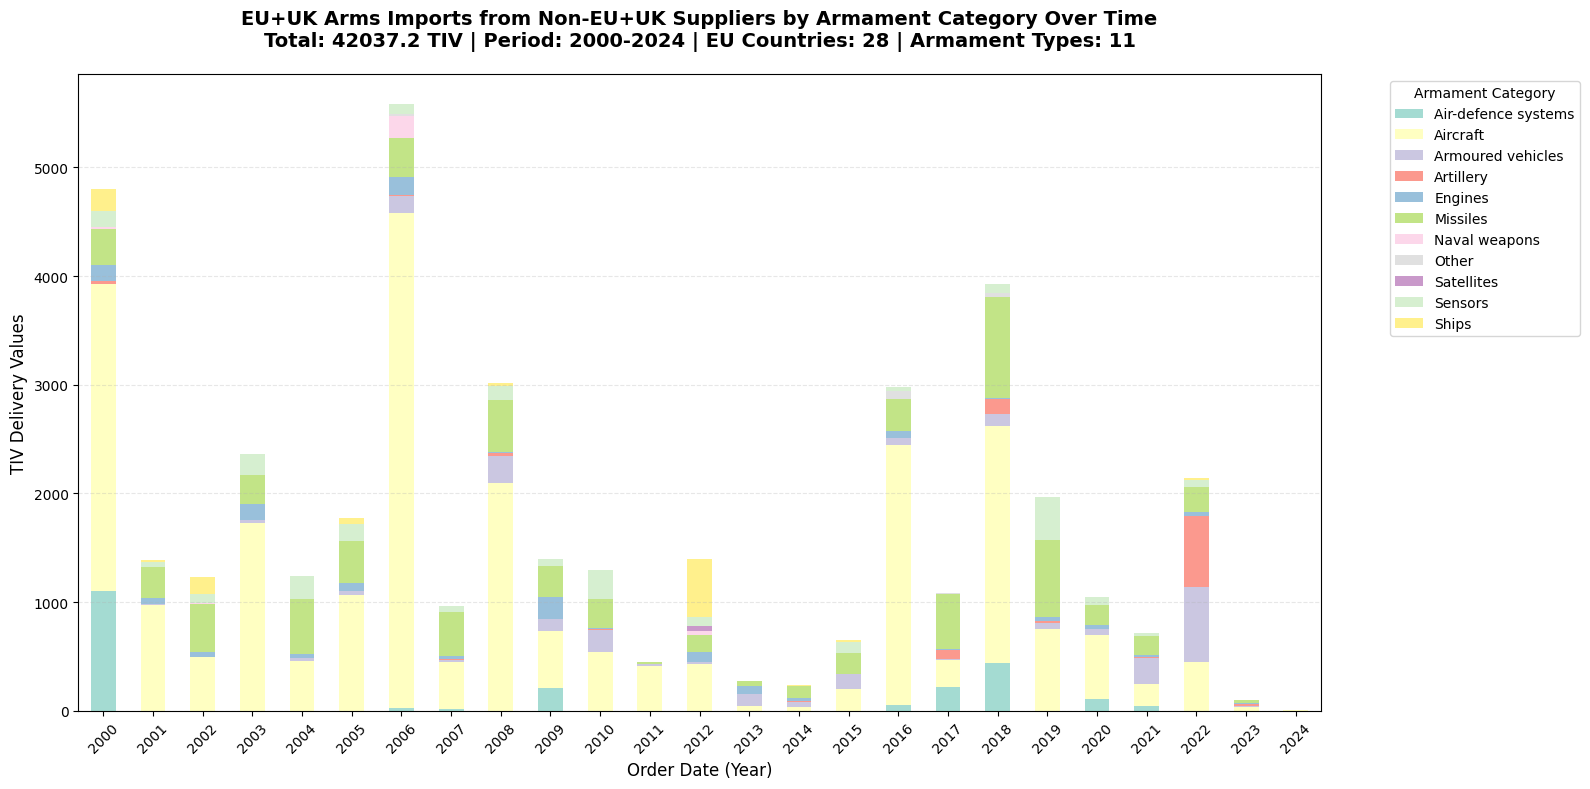


EU+UK Arms Imports from Non-EU+UK Suppliers - Armament Category Breakdown:
Overall Statistics:
Total TIV Value: 42037.2
EU Countries importing: 28
Armament Categories: 11
Time Period: 2000-2024

Armament Category Breakdown:
Aircraft                        23699.4 TIV ( 56.4%)
Missiles                         7575.5 TIV ( 18.0%)
Armoured vehicles                2385.4 TIV (  5.7%)
Sensors                          2306.8 TIV (  5.5%)
Air-defence systems              2216.0 TIV (  5.3%)
Engines                          1337.3 TIV (  3.2%)
Ships                            1050.3 TIV (  2.5%)
Artillery                        1010.3 TIV (  2.4%)
Naval weapons                     271.5 TIV (  0.6%)
Other                             134.6 TIV (  0.3%)
Satellites                         50.0 TIV (  0.1%)

Top 10 EU Countries importing from Non-EU+UK Suppliers:
 1. United Kingdom         9262.9 TIV ( 22.0%)
 2. Poland                 5538.5 TIV ( 13.2%)
 3. Greece                 4695.2 TIV ( 1

In [18]:
create_supplier_armament_chart(import_df, 'All', eu_suppliers_only=False)

# **SIPIRI EU EXPORT DATA (Not sure about completeness data)**

A deal is only included in a Transfer Register if reliable information has been verified that an order has been placed or deliveries have begun.

In [19]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def create_export_armament_chart(df, recipient_region, intra_eu_only=True):
    """
    Create stacked bar chart for TIV delivery values by armament category over order dates
    for EU+UK exports to specific recipient region(s)
    
    Parameters:
    df: DataFrame with columns including 'Recipient_region_EU', 'Order date', 'Armament category', 'TIV delivery values'
    recipient_region: Name of the recipient region to analyze (or 'All' for all recipients)
    intra_eu_only: If True, shows only exports to EU+UK. If False, shows only exports to non-EU+UK
    """
    
    # Clean the data
    df_clean = df.copy()
    
    # Convert TIV delivery values to numeric, handle NaN
    df_clean['TIV delivery values'] = pd.to_numeric(df_clean['TIV delivery values'], errors='coerce').fillna(0)
    
    # Convert Order date to numeric year
    df_clean['Order date'] = pd.to_numeric(df_clean['Order date'], errors='coerce')
    
    # Remove rows with missing essential data
    df_clean = df_clean.dropna(subset=['Order date', 'Armament category'])
    
    # Filter to reasonable year range
    df_clean = df_clean[(df_clean['Order date'] >= 2000) & (df_clean['Order date'] <= 2025)]
    
    # Filter by recipient region
    if recipient_region == 'All':
        # Filter by EU/non-EU recipients
        if 'Recipient_region_EU' in df_clean.columns:
            if intra_eu_only:
                # Show only exports to EU+UK (intra-European trade)
                export_data = df_clean[df_clean['Recipient_region_EU'] == 'EU+UK']
                recipient_label = "EU+UK Recipients (Intra-European)"
            else:
                # Show exports to all recipients except EU+UK
                export_data = df_clean[df_clean['Recipient_region_EU'] != 'EU+UK']
                recipient_label = "Non-EU+UK Recipients"
        else:
            # Fallback if column doesn't exist
            export_data = df_clean
            recipient_label = "All Recipients"
            print("Warning: 'Recipient_region_EU' column not found. Using all recipients.")
    else:
        # Show specific recipient region
        if 'Recipient_region_EU' in df_clean.columns:
            export_data = df_clean[df_clean['Recipient_region_EU'] == recipient_region].copy()
        else:
            # Try to filter by individual recipient country if region column doesn't exist
            export_data = df_clean[df_clean.get('Recipient', '') == recipient_region].copy()
        recipient_label = recipient_region
    
    if len(export_data) == 0:
        print(f"No export data found for: {recipient_label}")
        if 'Recipient_region_EU' in df_clean.columns:
            print(f"Available recipient regions: {sorted(df_clean['Recipient_region_EU'].unique())}")
        return
    
    # Group by order date and armament category, sum TIV values
    pivot_data = export_data.groupby(['Order date', 'Armament category'])['TIV delivery values'].sum().unstack(fill_value=0)
    
    if pivot_data.empty:
        print(f"No valid export data for: {recipient_label}")
        return
    
    # Create the plot using DataFrame's built-in plotting
    fig, ax = plt.subplots(figsize=(16, 8))
    
    # Use pandas built-in stacked bar plot
    pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', alpha=0.8)
    
    # Calculate statistics
    total_tiv = export_data['TIV delivery values'].sum()
    n_countries = export_data['Recipient'].nunique() if 'Recipient' in export_data.columns else 'N/A'
    n_armament_types = export_data['Armament category'].nunique()
    date_range = f"{export_data['Order date'].min():.0f}-{export_data['Order date'].max():.0f}"
    
    # Create appropriate title
    if recipient_region == 'All':
        title = f'EU+UK Arms Exports to {recipient_label} by Armament Category Over Time'
    else:
        title = f'EU+UK Arms Exports to {recipient_label} by Armament Category Over Time'
    
    ax.set_title(f'{title}\n'
                f'Total: {total_tiv:.1f} TIV | Period: {date_range} | Recipient Countries: {n_countries} | Armament Types: {n_armament_types}', 
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xlabel('Order Date (Year)', fontsize=12)
    ax.set_ylabel('TIV Delivery Values', fontsize=12)
    
    # Format x-axis
    ax.tick_params(axis='x', rotation=45)
    
    # Add legend
    ax.legend(title='Armament Category', bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add grid
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Adjust layout
    plt.tight_layout()
    
    plt.show()
    
    # Print summary statistics
    print(f"\nEU+UK Arms Exports to {recipient_label} - Armament Category Breakdown:")
    print("="*70)
    armament_totals = export_data.groupby('Armament category')['TIV delivery values'].sum().sort_values(ascending=False)
    
    print(f"Overall Statistics:")
    print(f"Total TIV Value: {total_tiv:.1f}")
    print(f"Recipient Countries: {n_countries}")
    print(f"Armament Categories: {n_armament_types}")
    print(f"Time Period: {date_range}")
    
    print(f"\nArmament Category Breakdown:")
    for armament, total in armament_totals.items():
        percentage = (total / total_tiv) * 100
        print(f"{armament:30} {total:8.1f} TIV ({percentage:5.1f}%)")
    
    # Show top recipient countries
    if 'Recipient' in export_data.columns:
        print(f"\nTop 10 Recipient Countries from EU+UK:")
        country_totals = export_data.groupby('Recipient')['TIV delivery values'].sum().sort_values(ascending=False)
        for i, (country, total) in enumerate(country_totals.head(10).items(), 1):
            percentage = (total / total_tiv) * 100
            print(f"{i:2d}. {country:20} {total:8.1f} TIV ({percentage:5.1f}%)")
    
    # If analyzing all recipients, show breakdown by recipient region
    if recipient_region == 'All' and 'Recipient_region_EU' in export_data.columns:
        print(f"\nBreakdown by Recipient Region within {recipient_label}:")
        recipient_region_totals = export_data.groupby('Recipient_region_EU')['TIV delivery values'].sum().sort_values(ascending=False)
        for recipient, total in recipient_region_totals.items():
            percentage = (total / total_tiv) * 100
            print(f"{recipient:25} {total:8.1f} TIV ({percentage:5.1f}%)")

# Check if the dataframes exist and show available recipient regions
try:
    if 'export_df' in globals() and export_df is not None:
        print("EU+UK Export Data Analysis")
        print("="*50)
        
        if 'Recipient_region_EU' in export_df.columns:
            print("Available recipient regions:")
            recipients = sorted(export_df['Recipient_region_EU'].unique())
            for i, recipient in enumerate(recipients, 1):
                print(f"{i:2d}. {recipient}")
        else:
            print("Available recipient countries:")
            recipients = sorted(export_df['Recipient'].unique()) if 'Recipient' in export_df.columns else []
            for i, recipient in enumerate(recipients[:20], 1):  # Show first 20
                print(f"{i:2d}. {recipient}")
            if len(recipients) > 20:
                print(f"... and {len(recipients) - 20} more countries")
        
        print(f"\nUsage: create_export_armament_chart(export_df, recipient_region, intra_eu_only=True/False)")
        print(f"\nExamples:")
        print(f"# EU+UK intra-European exports (to other EU+UK countries):")
        print(f"create_export_armament_chart(export_df, 'All', intra_eu_only=True)")
        print(f"\n# EU+UK exports to non-EU+UK countries:")
        print(f"create_export_armament_chart(export_df, 'All', intra_eu_only=False)")
        print(f"\n# EU+UK exports to United States:")
        print(f"create_export_armament_chart(export_df, 'United States')")
        print(f"\n# EU+UK exports to Asia & Oceania:")
        print(f"create_export_armament_chart(export_df, 'Asia & Oceania')")
        
    else:
        print("export_df not available. Please load the export data first.")
        
except Exception as e:
    print(f"Error: {e}")

EU+UK Export Data Analysis
Available recipient regions:
 1. Americas
 2. Asia-Pacific
 3. Caribbean & Small Islands
 4. Central Asia & Eastern Europe
 5. EU+UK
 6. International Organizations
 7. Middle East & North Africa
 8. Other
 9. Other European
10. Russia
11. Sub-Saharan Africa
12. United States
13. Unknown

Usage: create_export_armament_chart(export_df, recipient_region, intra_eu_only=True/False)

Examples:
# EU+UK intra-European exports (to other EU+UK countries):
create_export_armament_chart(export_df, 'All', intra_eu_only=True)

# EU+UK exports to non-EU+UK countries:
create_export_armament_chart(export_df, 'All', intra_eu_only=False)

# EU+UK exports to United States:
create_export_armament_chart(export_df, 'United States')

# EU+UK exports to Asia & Oceania:
create_export_armament_chart(export_df, 'Asia & Oceania')


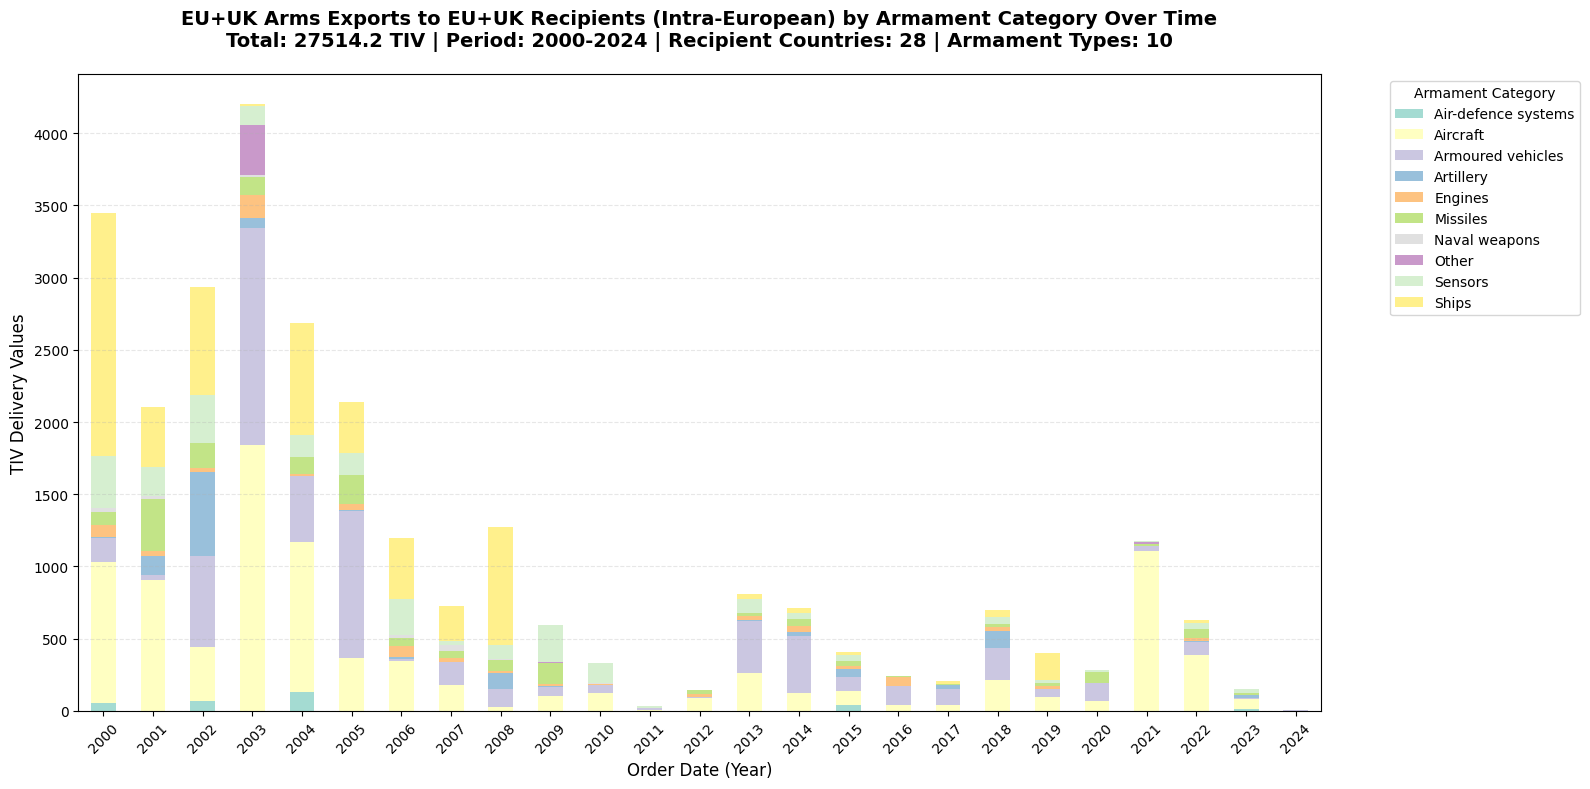


EU+UK Arms Exports to EU+UK Recipients (Intra-European) - Armament Category Breakdown:
Overall Statistics:
Total TIV Value: 27514.2
Recipient Countries: 28
Armament Categories: 10
Time Period: 2000-2024

Armament Category Breakdown:
Aircraft                         8880.6 TIV ( 32.3%)
Armoured vehicles                5880.7 TIV ( 21.4%)
Ships                            5826.1 TIV ( 21.2%)
Sensors                          2435.9 TIV (  8.9%)
Missiles                         1749.4 TIV (  6.4%)
Artillery                        1199.3 TIV (  4.4%)
Engines                           741.4 TIV (  2.7%)
Other                             361.6 TIV (  1.3%)
Air-defence systems               304.9 TIV (  1.1%)
Naval weapons                     134.2 TIV (  0.5%)

Top 10 Recipient Countries from EU+UK:
 1. Greece                 6645.5 TIV ( 24.2%)
 2. Poland                 2365.8 TIV (  8.6%)
 3. United Kingdom         2129.0 TIV (  7.7%)
 4. Portugal               1597.5 TIV (  5.8%)
 5. Neth

In [20]:
create_export_armament_chart(export_df, 'All', intra_eu_only=True)

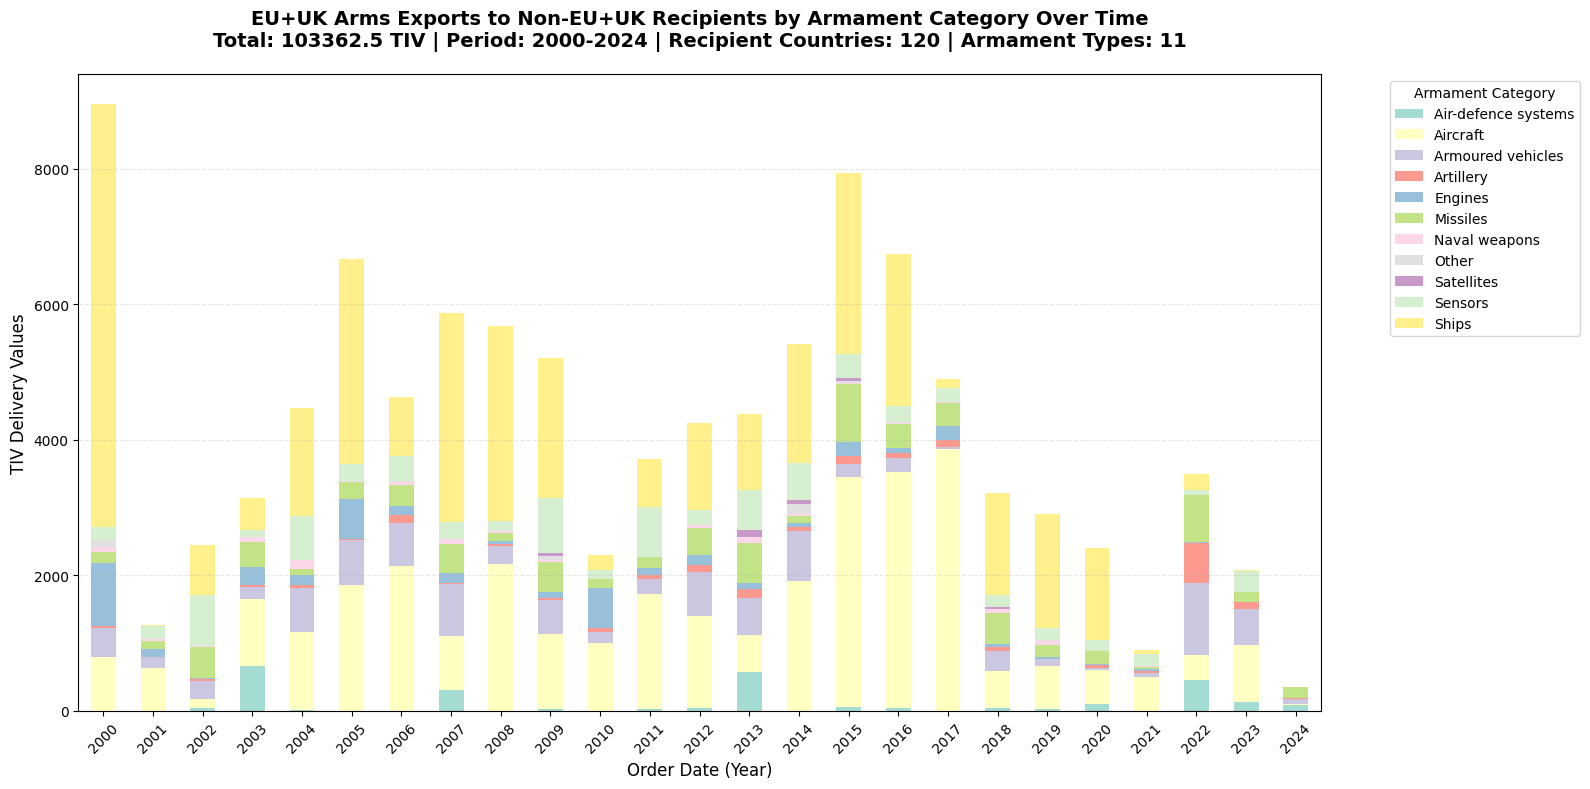


EU+UK Arms Exports to Non-EU+UK Recipients - Armament Category Breakdown:
Overall Statistics:
Total TIV Value: 103362.5
Recipient Countries: 120
Armament Categories: 11
Time Period: 2000-2024

Armament Category Breakdown:
Ships                           35969.7 TIV ( 34.8%)
Aircraft                        32442.1 TIV ( 31.4%)
Armoured vehicles                9416.1 TIV (  9.1%)
Sensors                          7835.3 TIV (  7.6%)
Missiles                         7581.6 TIV (  7.3%)
Engines                          4106.2 TIV (  4.0%)
Air-defence systems              2662.0 TIV (  2.6%)
Artillery                        1857.1 TIV (  1.8%)
Naval weapons                     839.2 TIV (  0.8%)
Other                             383.3 TIV (  0.4%)
Satellites                        270.0 TIV (  0.3%)

Top 10 Recipient Countries from EU+UK:
 1. Egypt                  8125.2 TIV (  7.9%)
 2. India                  7339.1 TIV (  7.1%)
 3. United States          6398.2 TIV (  6.2%)
 4. Qatar    

In [21]:
create_export_armament_chart(export_df, 'All', intra_eu_only=False)

In [22]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def analyze_top_eu_suppliers(df, top_n=5, intra_eu_only=True):
    """
    Create export analysis charts for the top N biggest EU+UK suppliers
    
    Parameters:
    df: Export DataFrame 
    top_n: Number of top suppliers to analyze (default: 5)
    intra_eu_only: If True, shows exports to EU+UK only. If False, shows exports to non-EU+UK only
    """
    
    # Clean the data
    df_clean = df.copy()
    
    # Convert TIV delivery values to numeric, handle NaN
    df_clean['TIV delivery values'] = pd.to_numeric(df_clean['TIV delivery values'], errors='coerce').fillna(0)
    
    # Convert Order date to numeric year
    df_clean['Order date'] = pd.to_numeric(df_clean['Order date'], errors='coerce')
    
    # Remove rows with missing essential data
    df_clean = df_clean.dropna(subset=['Order date', 'Armament category'])
    
    # Filter to reasonable year range
    df_clean = df_clean[(df_clean['Order date'] >= 2000) & (df_clean['Order date'] <= 2025)]
    
    # Filter by recipient region (EU/non-EU)
    if 'Recipient_region_EU' in df_clean.columns:
        if intra_eu_only:
            df_clean = df_clean[df_clean['Recipient_region_EU'] == 'EU+UK']
            trade_type = "Intra-EU+UK"
            trade_description = "to other EU+UK countries"
        else:
            df_clean = df_clean[df_clean['Recipient_region_EU'] != 'EU+UK']
            trade_type = "Extra-EU+UK"
            trade_description = "to non-EU+UK countries"
    else:
        trade_type = "All"
        trade_description = "to all countries"
        print("Warning: 'Recipient_region_EU' column not found. Using all recipients.")
    
    # Identify top EU suppliers by total TIV
    if 'Supplier' in df_clean.columns:
        supplier_totals = df_clean.groupby('Supplier')['TIV delivery values'].sum().sort_values(ascending=False)
        top_suppliers = supplier_totals.head(top_n).index.tolist()
        
        print(f"Top {top_n} EU+UK Suppliers ({trade_type} Exports):")
        print("="*60)
        for i, (supplier, total) in enumerate(supplier_totals.head(top_n).items(), 1):
            print(f"{i}. {supplier:25} {total:8.1f} TIV")
        print()
        
    else:
        print("Error: 'Supplier' column not found in the dataset")
        return
    
    # Calculate subplot layout
    if top_n <= 2:
        rows, cols = 1, 2
    elif top_n <= 4:
        rows, cols = 2, 2
    elif top_n <= 6:
        rows, cols = 2, 3
    elif top_n <= 9:
        rows, cols = 3, 3
    else:
        rows, cols = 4, 3
    
    # Create the figure
    fig, axes = plt.subplots(rows, cols, figsize=(6*cols, 5*rows))
    if top_n == 1:
        axes = [axes]
    elif rows == 1 or cols == 1:
        axes = axes.flatten() if hasattr(axes, 'flatten') else [axes]
    else:
        axes = axes.flatten()
    
    # Process each top supplier
    for idx, supplier in enumerate(top_suppliers):
        if idx >= len(axes):
            break
            
        ax = axes[idx]
        
        # Filter data for this supplier
        supplier_data = df_clean[df_clean['Supplier'] == supplier].copy()
        
        if len(supplier_data) == 0:
            ax.text(0.5, 0.5, f'No data for {supplier}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{supplier}\n(No data)')
            continue
        
        # Group by order date and armament category, sum TIV values
        pivot_data = supplier_data.groupby(['Order date', 'Armament category'])['TIV delivery values'].sum().unstack(fill_value=0)
        
        if pivot_data.empty:
            ax.text(0.5, 0.5, f'No valid data for {supplier}', ha='center', va='center', transform=ax.transAxes)
            ax.set_title(f'{supplier}\n(No valid data)')
            continue
        
        # Create stacked bar chart
        pivot_data.plot(kind='bar', stacked=True, ax=ax, colormap='Set3', alpha=0.8, legend=False)
        
        # Calculate statistics
        total_tiv = supplier_data['TIV delivery values'].sum()
        n_countries = supplier_data['Recipient'].nunique() if 'Recipient' in supplier_data.columns else 'N/A'
        date_range = f"{supplier_data['Order date'].min():.0f}-{supplier_data['Order date'].max():.0f}"
        
        # Customize the subplot
        ax.set_title(f'{supplier}\nTotal: {total_tiv:.1f} TIV | Recipients: {n_countries} | Period: {date_range}', 
                    fontsize=11, fontweight='bold')
        ax.set_xlabel('Order Date', fontsize=10)
        ax.set_ylabel('TIV Values', fontsize=10)
        
        # Format x-axis
        ax.tick_params(axis='x', rotation=45, labelsize=9)
        ax.tick_params(axis='y', labelsize=9)
        
        # Add grid
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Hide unused subplots
    for idx in range(len(top_suppliers), len(axes)):
        axes[idx].set_visible(False)
    
    # Add overall title
    fig.suptitle(f'Top {top_n} EU+UK Arms Suppliers - {trade_type} Exports by Armament Category\n'
                f'Exports {trade_description}', 
                fontsize=16, fontweight='bold', y=0.98)
    
    # Add a single legend for all subplots
    if len(top_suppliers) > 0 and not df_clean.empty:
        # Get all unique armament categories for the legend
        all_categories = df_clean['Armament category'].unique()
        colors = plt.cm.Set3(np.linspace(0, 1, len(all_categories)))
        
        # Create legend
        handles = [plt.Rectangle((0,0),1,1, color=colors[i], alpha=0.8) for i in range(len(all_categories))]
        fig.legend(handles, all_categories, title='Armament Category', 
                  bbox_to_anchor=(0.98, 0.5), loc='center left', fontsize=10)
    
    # Adjust layout
    plt.tight_layout()
    plt.subplots_adjust(right=0.85)  # Make room for legend
    
    plt.show()
    
    # Print detailed summary for each supplier
    print("\n" + "="*80)
    print(f"DETAILED ANALYSIS - TOP {top_n} EU+UK SUPPLIERS ({trade_type} EXPORTS)")
    print("="*80)
    
    for supplier in top_suppliers:
        supplier_data = df_clean[df_clean['Supplier'] == supplier]
        if len(supplier_data) > 0:
            total_tiv = supplier_data['TIV delivery values'].sum()
            n_countries = supplier_data['Recipient'].nunique() if 'Recipient' in supplier_data.columns else 0
            n_armament_types = supplier_data['Armament category'].nunique()
            
            print(f"\n{supplier}:")
            print(f"  Total TIV: {total_tiv:.1f}")
            print(f"  Recipient countries: {n_countries}")
            print(f"  Armament categories: {n_armament_types}")
            
            # Top armament categories for this supplier
            armament_totals = supplier_data.groupby('Armament category')['TIV delivery values'].sum().sort_values(ascending=False)
            print(f"  Top armament categories:")
            for armament, total in armament_totals.head(3).items():
                percentage = (total / total_tiv) * 100
                print(f"    {armament}: {total:.1f} TIV ({percentage:.1f}%)")
            
            # Top recipient countries for this supplier
            if 'Recipient' in supplier_data.columns:
                country_totals = supplier_data.groupby('Recipient')['TIV delivery values'].sum().sort_values(ascending=False)
                print(f"  Top recipient countries:")
                for country, total in country_totals.head(3).items():
                    percentage = (total / total_tiv) * 100
                    print(f"    {country}: {total:.1f} TIV ({percentage:.1f}%)")

# Check if the dataframes exist and provide usage examples
try:
    if 'export_df' in globals() and export_df is not None:
        print("Top EU+UK Suppliers Analysis")
        print("="*50)
        
        # Show total number of suppliers
        if 'Supplier' in export_df.columns:
            total_suppliers = export_df['Supplier'].nunique()
            print(f"Total EU+UK suppliers in dataset: {total_suppliers}")
        
        print(f"\nUsage: analyze_top_eu_suppliers(export_df, top_n=5, intra_eu_only=True/False)")
        print(f"\nExamples:")
        print(f"# Top 5 EU+UK suppliers - intra-European exports:")
        print(f"analyze_top_eu_suppliers(export_df, top_n=5, intra_eu_only=True)")
        print(f"\n# Top 8 EU+UK suppliers - exports to non-EU+UK countries:")
        print(f"analyze_top_eu_suppliers(export_df, top_n=8, intra_eu_only=False)")
        print(f"\n# Top 3 EU+UK suppliers - all exports:")
        print(f"analyze_top_eu_suppliers(export_df, top_n=3)")
        
    else:
        print("export_df not available. Please load the export data first.")
        
except Exception as e:
    print(f"Error: {e}")

Top EU+UK Suppliers Analysis
Total EU+UK suppliers in dataset: 27

Usage: analyze_top_eu_suppliers(export_df, top_n=5, intra_eu_only=True/False)

Examples:
# Top 5 EU+UK suppliers - intra-European exports:
analyze_top_eu_suppliers(export_df, top_n=5, intra_eu_only=True)

# Top 8 EU+UK suppliers - exports to non-EU+UK countries:
analyze_top_eu_suppliers(export_df, top_n=8, intra_eu_only=False)

# Top 3 EU+UK suppliers - all exports:
analyze_top_eu_suppliers(export_df, top_n=3)


Top 5 EU+UK Suppliers (Intra-EU+UK Exports):
1. Germany                     9951.0 TIV
2. France                      4771.4 TIV
3. Netherlands                 3410.6 TIV
4. Italy                       2873.2 TIV
5. Sweden                      2624.6 TIV



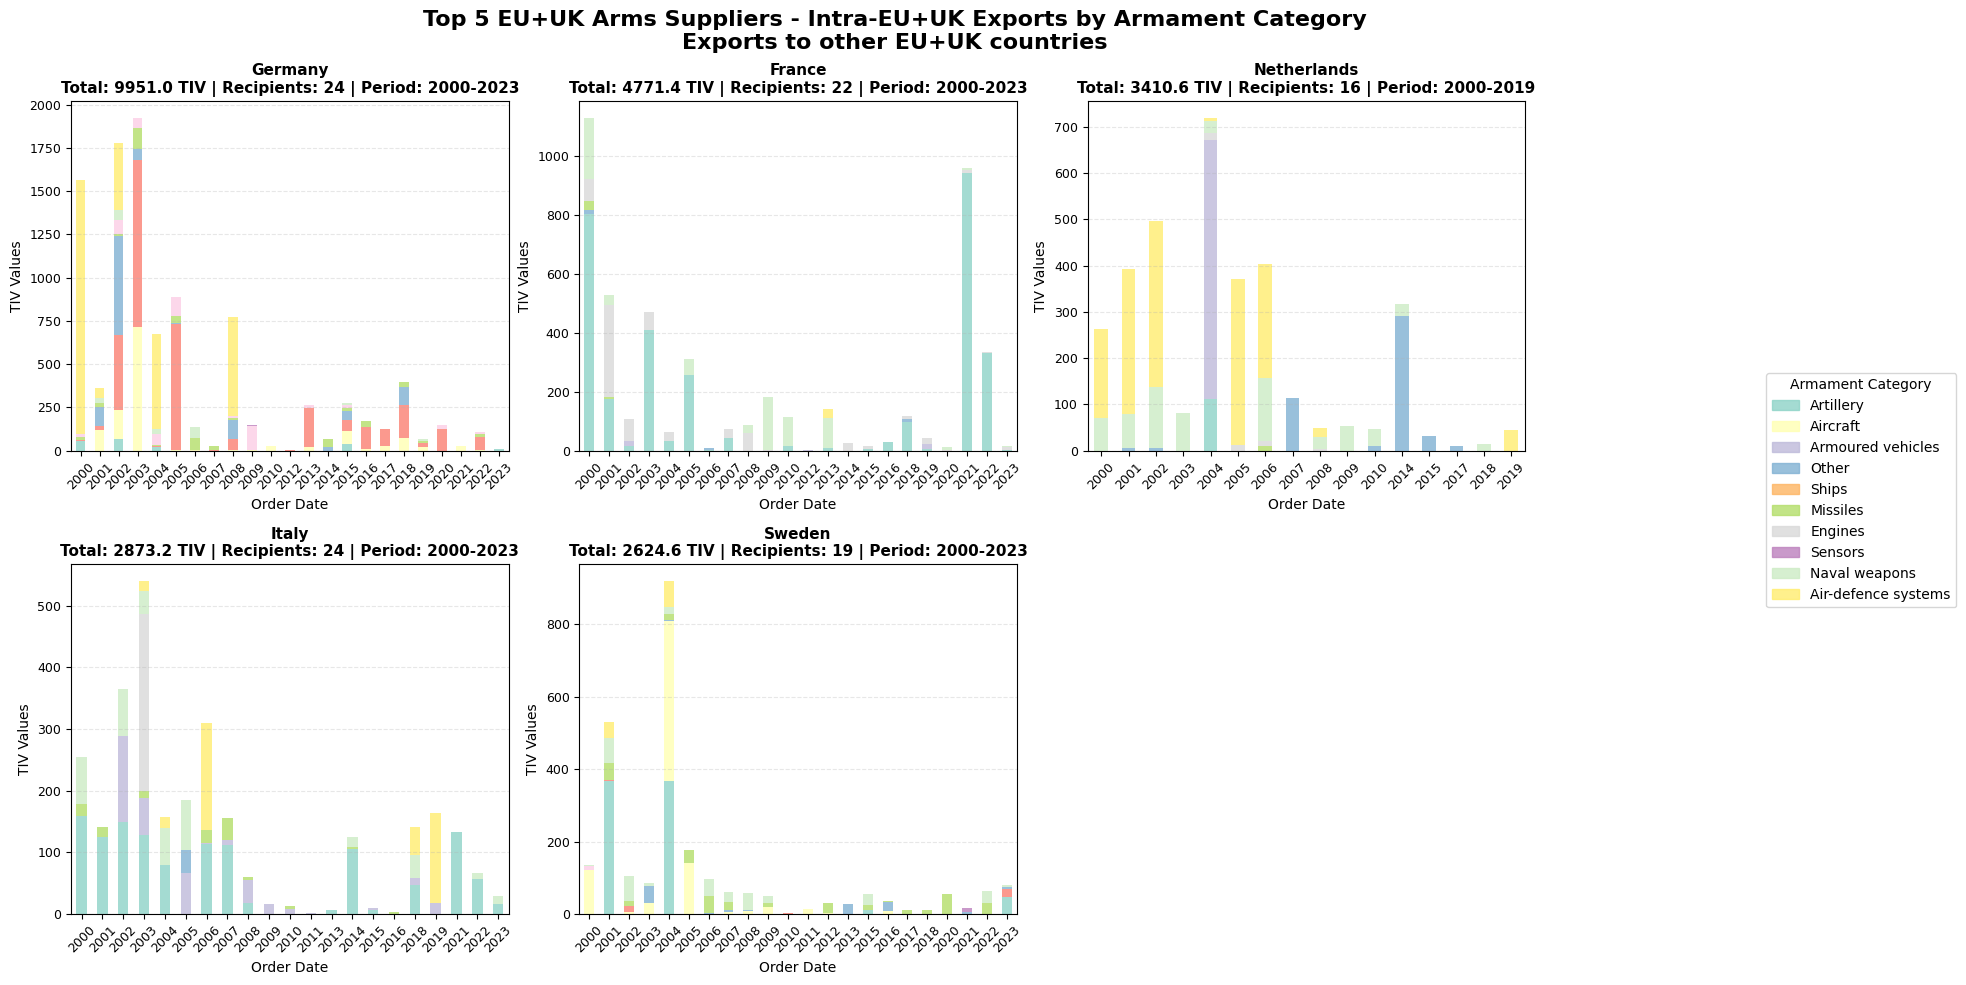


DETAILED ANALYSIS - TOP 5 EU+UK SUPPLIERS (Intra-EU+UK EXPORTS)

Germany:
  Total TIV: 9951.0
  Recipient countries: 24
  Armament categories: 9
  Top armament categories:
    Armoured vehicles: 3164.0 TIV (31.8%)
    Ships: 3037.5 TIV (30.5%)
    Aircraft: 1292.3 TIV (13.0%)
  Top recipient countries:
    Greece: 3347.5 TIV (33.6%)
    Italy: 897.0 TIV (9.0%)
    United Kingdom: 781.3 TIV (7.9%)

France:
  Total TIV: 4771.4
  Recipient countries: 22
  Armament categories: 7
  Top armament categories:
    Aircraft: 3175.1 TIV (66.5%)
    Missiles: 740.4 TIV (15.5%)
    Sensors: 722.0 TIV (15.1%)
  Top recipient countries:
    Greece: 2366.5 TIV (49.6%)
    Spain: 526.6 TIV (11.0%)
    United Kingdom: 391.5 TIV (8.2%)

Netherlands:
  Total TIV: 3410.6
  Recipient countries: 16
  Armament categories: 7
  Top armament categories:
    Ships: 1542.0 TIV (45.2%)
    Sensors: 673.8 TIV (19.8%)
    Aircraft: 561.0 TIV (16.4%)
  Top recipient countries:
    Greece: 666.5 TIV (19.5%)
    United

In [23]:
analyze_top_eu_suppliers(export_df, top_n=5)

# **Janes Inventory Datasets**

In [33]:
import pandas as pd

# EU+UK countries list
eu_uk_countries = [
    'Germany', 'Sweden', 'Italy', 'Spain', 'Belgium', 'United Kingdom', 'France',
    'Portugal', 'Netherlands', 'Austria', 'Poland', 'Czech Republic', 'Finland', 'Slovakia',
    'Greece', 'Bulgaria', 'Denmark', 'Croatia', 'Ireland', 'Hungary', 'Romania',
    'Lithuania', 'Latvia', 'Slovenia', 'Estonia', 'Cyprus', 'Luxembourg', 'Malta'
]

def filter_and_merge_inventory_datasets():
    """
    Filter each inventory dataset by EU+UK operator countries and merge them together
    """
    
    # Dictionary to store filtered datasets
    filtered_datasets = {}
    dataset_info = {}
    
    # List of inventory datasets to process
    inventory_datasets = [
        ('inventory_landvehicles_df', 'Land Vehicles'),
        ('inventory_naval_df', 'Naval'),
        ('inventory_aircraft_df', 'Aircraft'),
    ]
    
    print("Filtering inventory datasets by EU+UK operator countries...")
    print("="*70)
    
    # Process each dataset
    for df_name, dataset_label in inventory_datasets:
        try:
            # Get the dataset from globals
            if df_name in globals() and globals()[df_name] is not None:
                df = globals()[df_name].copy()
                
                # Check if Operatorcountry column exists
                if 'Operatorcountry' in df.columns:
                    # Filter by EU+UK countries
                    df_filtered = df[df['Operatorcountry'].isin(eu_uk_countries)].copy()
                    
                    # Add dataset type column for identification after merging
                    df_filtered['Dataset_type'] = dataset_label
                    
                    # Store filtered dataset
                    filtered_datasets[df_name] = df_filtered
                    
                    # Store info
                    dataset_info[dataset_label] = {
                        'original_rows': len(df),
                        'filtered_rows': len(df_filtered),
                        'eu_countries': df_filtered['Operatorcountry'].nunique(),
                        'columns': list(df_filtered.columns)
                    }
                    
                    print(f"✓ {dataset_label:15} | Original: {len(df):,} rows | EU+UK: {len(df_filtered):,} rows | Countries: {df_filtered['Operatorcountry'].nunique()}")
                    
                else:
                    print(f"✗ {dataset_label:15} | Missing 'Operatorcountry' column")
                    
            else:
                print(f"✗ {dataset_label:15} | Dataset not available")
                
        except Exception as e:
            print(f"✗ {dataset_label:15} | Error: {e}")
    
    if not filtered_datasets:
        print("No datasets were successfully filtered.")
        return None
    
    print(f"\nSuccessfully filtered {len(filtered_datasets)} datasets")
    
    # Find common columns across all datasets (excluding Dataset_type)
    all_columns = []
    for df in filtered_datasets.values():
        all_columns.extend(df.columns.tolist())
    
    # Count occurrences of each column
    from collections import Counter
    column_counts = Counter(all_columns)
    
    # Common columns (appear in all datasets)
    common_columns = [col for col, count in column_counts.items() 
                     if count == len(filtered_datasets) and col != 'Dataset_type']
    
    print(f"\nCommon columns across all datasets: {len(common_columns)}")
    print(f"Common columns: {common_columns}")
    
    # Merge datasets
    print(f"\nMerging {len(filtered_datasets)} datasets...")
    
    merged_df = pd.concat(filtered_datasets.values(), ignore_index=True, sort=False)
    
    print(f"✓ Merged dataset created: {len(merged_df):,} rows × {len(merged_df.columns)} columns")
    
    # Summary statistics
    print(f"\n" + "="*70)
    print("MERGED DATASET SUMMARY")
    print("="*70)
    print(f"Total rows: {len(merged_df):,}")
    print(f"Total columns: {len(merged_df.columns)}")
    print(f"EU+UK countries: {merged_df['Operatorcountry'].nunique()}")
    print(f"Dataset types: {merged_df['Dataset_type'].nunique()}")
    
    print(f"\nBreakdown by dataset type:")
    dataset_breakdown = merged_df['Dataset_type'].value_counts()
    for dataset, count in dataset_breakdown.items():
        percentage = (count / len(merged_df)) * 100
        print(f"  {dataset:15} {count:6,} rows ({percentage:5.1f}%)")
    
    print(f"\nTop 10 EU+UK countries by equipment count:")
    country_breakdown = merged_df['Operatorcountry'].value_counts().head(10)
    for country, count in country_breakdown.items():
        percentage = (count / len(merged_df)) * 100
        print(f"  {country:15} {count:6,} items ({percentage:5.1f}%)")
    
    # Check for missing values in key columns
    print(f"\nMissing values in key columns:")
    key_columns = ['Operatorcountry', 'Dataset_type']
    for col in key_columns:
        if col in merged_df.columns:
            missing = merged_df[col].isnull().sum()
            print(f"  {col:15} {missing:6,} missing values")
    
    # Show column information
    print(f"\nColumn information:")
    print(f"All columns ({len(merged_df.columns)}):")
    for i, col in enumerate(merged_df.columns, 1):
        non_null = merged_df[col].notna().sum()
        print(f"  {i:2d}. {col:25} ({non_null:,} non-null)")
    
    return merged_df

# Execute the function
try:
    merged_inventory_df = filter_and_merge_inventory_datasets()
    
    if merged_inventory_df is not None:
        print(f"\n" + "="*70)
        print("SUCCESS: Merged inventory dataset created as 'merged_inventory_df'")
        print("="*70)
        print(f"Usage examples:")
        print(f"# View first few rows:")
        print(f"merged_inventory_df.head()")
        print(f"# Analyze by country:")
        print(f"merged_inventory_df.groupby('Operatorcountry')['Dataset_type'].value_counts()")
        print(f"# Filter specific dataset type:")
        print(f"land_vehicles = merged_inventory_df[merged_inventory_df['Dataset_type'] == 'Land Vehicles']")
        
except Exception as e:
    print(f"Error during execution: {e}")

Filtering inventory datasets by EU+UK operator countries...
✓ Land Vehicles   | Original: 39,419 rows | EU+UK: 8,248 rows | Countries: 28
✗ Naval           | Missing 'Operatorcountry' column
✓ Aircraft        | Original: 19,243 rows | EU+UK: 3,484 rows | Countries: 27

Successfully filtered 2 datasets

Common columns across all datasets: 12
Common columns: ['Familyname', 'Generic role', 'Mannedunmanned', 'Manufacturer', 'Operatorcountry', 'Operatorcountry (group)', 'Operatorname', 'Specific role', 'Subtype', 'Systemname', 'Uid', 'Inservice']

Merging 2 datasets...
✓ Merged dataset created: 11,732 rows × 13 columns

MERGED DATASET SUMMARY
Total rows: 11,732
Total columns: 13
EU+UK countries: 28
Dataset types: 2

Breakdown by dataset type:
  Land Vehicles    8,248 rows ( 70.3%)
  Aircraft         3,484 rows ( 29.7%)

Top 10 EU+UK countries by equipment count:
  Spain              870 items (  7.4%)
  France             790 items (  6.7%)
  Germany            753 items (  6.4%)
  Italy   

In [34]:
merged_inventory_df.sample(5)

,Familyname,Generic role,Mannedunmanned,Manufacturer,Operatorcountry,Operatorcountry (group),Operatorname,Specific role,Subtype,Systemname,Uid,Inservice,Dataset_type
3338,Boxer,Combat/offensive,Manned,KNDS Deutschland GmbH & Co KG - Kassel Office ...,Lithuania,Europe & CIS,Lithuanian Land Force,Infantry fighting vehicle,Cannon,Boxer,2qE7B9T421PfatzcjWX1WJ,88.0,Land Vehicles
6636,BvS10,Logistics/support,Manned,BAE Systems Hägglunds AB,France,Europe & CIS,French Army,Ammunition support,Tracked,BvS10 Mk II Rear Unit,7aTvJeaktf2B21xfvcJpCH,53.0,Land Vehicles
11519,R44,Training,Manned,Robinson Helicopter Company Inc | Eco Helicopt...,Poland,Europe & CIS,Polish Air Force,Transport,Rotary-wing,R44,395Rox2p7F4ZBoiMG4rnNv,3.0,Aircraft
605,M203,Combat/offensive,NaN,Colt's Manufacturing Company LLC | AirTronic U...,Austria,Europe & CIS,Austrian Armed Forces,Anti-personnel,Gun,M203,4tLeUzuHZ2h2wcDxDH9k2J,NaN,Land Vehicles
669,G17,Combat/offensive,NaN,GLOCK Ges mbH,Finland,Europe & CIS,Finnish Defence Forces,Anti-personnel,Gun,G17,1uwu1X30pypwRwhompl8XR,NaN,Land Vehicles


In [35]:
import pandas as pd
import matplotlib.pyplot as plt

def analyze_country_equipment(df, country, dataset_type, top_n=10):
    """
    Analyze the most in-service equipment for a specific country (or all countries) and dataset type,
    broken down by manufacturers
    
    Parameters:
    df: merged_inventory_df DataFrame
    country: Country name (e.g., 'Germany', 'France') or 'All' for all EU+UK countries
    dataset_type: Type of equipment (e.g., 'Aircraft', 'Land Vehicles', 'Naval')
    top_n: Number of top equipment/manufacturers to show (default: 10)
    """
    
    # Filter data for the specific dataset type
    if country == 'All':
        filtered_df = df[df['Dataset_type'] == dataset_type].copy()
        analysis_label = f"All EU+UK Countries - {dataset_type}"
    else:
        # Filter for specific country and dataset type
        filtered_df = df[(df['Operatorcountry'] == country) & 
                         (df['Dataset_type'] == dataset_type)].copy()
        analysis_label = f"{country} - {dataset_type}"
    
    if len(filtered_df) == 0:
        if country == 'All':
            print(f"No data found for {dataset_type} across all countries")
            print(f"Available dataset types: {sorted(df['Dataset_type'].unique())}")
        else:
            print(f"No data found for {country} - {dataset_type}")
            print(f"Available countries: {sorted(df['Operatorcountry'].unique())}")
            print(f"Available dataset types: {sorted(df['Dataset_type'].unique())}")
        return
    
    print(f"\n{analysis_label} Equipment Analysis")
    print("="*70)
    print(f"Total equipment entries: {len(filtered_df)}")
    
    if country == 'All':
        countries_covered = filtered_df['Operatorcountry'].nunique()
        print(f"Countries covered: {countries_covered}")
        print(f"Countries: {', '.join(sorted(filtered_df['Operatorcountry'].unique()))}")
    
    # Check for quantity/count columns to determine "most in-service"
    quantity_columns = []
    possible_qty_cols = ['Inservice', 'Quantity', 'Count', 'Number', 'Total', 'Units']
    
    for col in possible_qty_cols:
        if col in filtered_df.columns:
            quantity_columns.append(col)
    
    # If we have quantity columns, use them; otherwise count occurrences
    if quantity_columns:
        print(f"Using quantity column(s): {quantity_columns}")
        # Use the first available quantity column
        qty_col = quantity_columns[0]
        
        # Convert to numeric, handle non-numeric values
        filtered_df[qty_col] = pd.to_numeric(filtered_df[qty_col], errors='coerce').fillna(0)
        
        # Group by manufacturer and system, sum quantities
        if 'Systemname' in filtered_df.columns:
            equipment_summary = filtered_df.groupby(['Manufacturer', 'Systemname'])[qty_col].sum().reset_index()
            equipment_summary = equipment_summary.sort_values(qty_col, ascending=False)
        else:
            # Fallback to other identifying columns
            id_cols = ['Familyname', 'Generic role', 'Subtype']
            available_id_cols = [col for col in id_cols if col in filtered_df.columns]
            if available_id_cols:
                group_cols = ['Manufacturer'] + available_id_cols[:1]
                equipment_summary = filtered_df.groupby(group_cols)[qty_col].sum().reset_index()
                equipment_summary = equipment_summary.sort_values(qty_col, ascending=False)
            else:
                equipment_summary = filtered_df.groupby('Manufacturer')[qty_col].sum().reset_index()
                equipment_summary = equipment_summary.sort_values(qty_col, ascending=False)
    else:
        print("No quantity columns found. Counting equipment entries.")
        # Count occurrences by manufacturer and system
        if 'Systemname' in filtered_df.columns:
            equipment_summary = filtered_df.groupby(['Manufacturer', 'Systemname']).size().reset_index(name='Count')
            equipment_summary = equipment_summary.sort_values('Count', ascending=False)
            qty_col = 'Count'
        else:
            equipment_summary = filtered_df.groupby('Manufacturer').size().reset_index(name='Count')
            equipment_summary = equipment_summary.sort_values('Count', ascending=False)
            qty_col = 'Count'
    
    # Analysis by Manufacturer
    print(f"\nTop {top_n} Manufacturers by Total Equipment:")
    print("-" * 50)
    manufacturer_totals = equipment_summary.groupby('Manufacturer')[qty_col].sum().sort_values(ascending=False)
    
    for i, (manufacturer, total) in enumerate(manufacturer_totals.head(top_n).items(), 1):
        percentage = (total / manufacturer_totals.sum()) * 100
        print(f"{i:2d}. {manufacturer:<25} {total:>6.0f} units ({percentage:5.1f}%)")
    
    # Top Equipment Systems
    print(f"\nTop {top_n} Equipment Systems:")
    print("-" * 70)
    
    if 'Systemname' in equipment_summary.columns:
        for i, row in equipment_summary.head(top_n).iterrows():
            manufacturer = row['Manufacturer']
            system = row['Systemname']
            quantity = row[qty_col]
            percentage = (quantity / equipment_summary[qty_col].sum()) * 100
            print(f"{i+1:2d}. {system:<30} | {manufacturer:<20} | {quantity:>6.0f} units ({percentage:4.1f}%)")
    else:
        for i, row in equipment_summary.head(top_n).iterrows():
            manufacturer = row['Manufacturer']
            quantity = row[qty_col]
            percentage = (quantity / equipment_summary[qty_col].sum()) * 100
            print(f"{i+1:2d}. {manufacturer:<30} | {quantity:>6.0f} units ({percentage:4.1f}%)")
    
    # Detailed breakdown by manufacturer
    print(f"\nDetailed Breakdown by Manufacturer:")
    print("=" * 70)
    
    for manufacturer in manufacturer_totals.head(5).index:
        manufacturer_equipment = equipment_summary[equipment_summary['Manufacturer'] == manufacturer]
        manufacturer_total = manufacturer_equipment[qty_col].sum()
        
        print(f"\n{manufacturer} (Total: {manufacturer_total:.0f} units):")
        
        if 'Systemname' in manufacturer_equipment.columns:
            for _, row in manufacturer_equipment.head(5).iterrows():
                system = row['Systemname']
                quantity = row[qty_col]
                percentage = (quantity / manufacturer_total) * 100
                print(f"  • {system:<35} {quantity:>6.0f} units ({percentage:5.1f}%)")
        else:
            print(f"  • {manufacturer_total:.0f} units total")
    
    # Create visualization
    create_manufacturer_chart(filtered_df, analysis_label, dataset_type, qty_col)
    
    # Additional statistics
    print(f"\nAdditional Statistics:")
    print("-" * 30)
    print(f"Total manufacturers: {filtered_df['Manufacturer'].nunique()}")
    print(f"Total unique systems: {filtered_df['Systemname'].nunique() if 'Systemname' in filtered_df.columns else 'N/A'}")
    print(f"Most common manufacturer: {manufacturer_totals.index[0]} ({manufacturer_totals.iloc[0]:.0f} units)")
    
    if country == 'All':
        # Additional statistics for all countries
        print(f"\nCountry Distribution (Top 10):")
        country_totals = filtered_df.groupby('Operatorcountry')[qty_col].sum().sort_values(ascending=False) if qty_col in filtered_df.columns else filtered_df['Operatorcountry'].value_counts()
        for i, (ctry, total) in enumerate(country_totals.head(10).items(), 1):
            print(f"{i:2d}. {ctry:<20} {total:>6.0f} units")
    
    # Show available columns for reference
    print(f"\nAvailable data columns:")
    important_cols = ['Manufacturer', 'Systemname', 'Familyname', 'Generic role', 'Subtype', 'Specific role']
    available_important = [col for col in important_cols if col in filtered_df.columns]
    print(f"Key columns: {available_important}")
    
    return equipment_summary

def create_manufacturer_chart(df, analysis_label, dataset_type, qty_col):
    """
    Create a stacked bar chart of manufacturers with specific roles as hue
    """
    
    # Prepare data for stacked bar chart
    if 'Specific role' in df.columns:
        # Group by manufacturer and specific role, sum quantities
        chart_data = df.groupby(['Manufacturer', 'Specific role'])[qty_col].sum().unstack(fill_value=0)
        
        # Sort manufacturers by total quantities
        manufacturer_totals = chart_data.sum(axis=1).sort_values(ascending=False)
        chart_data = chart_data.loc[manufacturer_totals.index]
        
        # Create the plot with increased height
        plt.figure(figsize=(14, 10))  # Increased height from 6 to 10
        
        # Create stacked bar chart
        ax = chart_data.plot(kind='bar', stacked=True, ax=plt.gca(), 
                            colormap='Set3', alpha=0.8, width=0.8)
        
        plt.title(f'{analysis_label} Equipment by Manufacturer and Specific Role', 
                 fontsize=14, fontweight='bold', pad=20)
        plt.xlabel('Manufacturer', fontsize=12)
        plt.ylabel(f'Number of Units ({qty_col})', fontsize=12)
        
        # Rotate manufacturer names for better readability with more space
        plt.xticks(rotation=45, ha='right', fontsize=10)
        plt.yticks(fontsize=10)
        
        # Improve legend
        plt.legend(title='Specific Role', bbox_to_anchor=(1.05, 1), loc='upper left', 
                  fontsize=9, title_fontsize=10)
        
        # Add total value labels on top of each stacked bar
        for i, (manufacturer, total) in enumerate(manufacturer_totals.items()):
            plt.text(i, total + max(manufacturer_totals)*0.01,
                    f'{total:.0f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
        
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()
        
        # Print breakdown of specific roles
        print(f"\nSpecific Roles Breakdown:")
        print("-" * 40)
        role_totals = df.groupby('Specific role')[qty_col].sum().sort_values(ascending=False)
        for role, total in role_totals.items():
            percentage = (total / role_totals.sum()) * 100
            print(f"{role:<25} {total:>6.0f} units ({percentage:5.1f}%)")
        
    else:
        # Fallback to simple bar chart if no 'Specific role' column
        print("'Specific role' column not found. Creating simple manufacturer chart.")
        manufacturer_totals = df.groupby('Manufacturer')[qty_col].sum().sort_values(ascending=False)
        
        plt.figure(figsize=(14, 10))  # Increased height
        
        bars = plt.bar(range(len(manufacturer_totals)), manufacturer_totals.values, 
                      alpha=0.7, color='steelblue')
        
        plt.title(f'{analysis_label} Equipment by Manufacturer', 
                 fontsize=14, fontweight='bold')
        plt.xlabel('Manufacturer', fontsize=12)
        plt.ylabel(f'Number of Units ({qty_col})', fontsize=12)
        
        plt.xticks(range(len(manufacturer_totals)), manufacturer_totals.index, 
                  rotation=45, ha='right', fontsize=10)
        
        # Add value labels on bars
        for bar, value in zip(bars, manufacturer_totals.values):
            plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(manufacturer_totals.values)*0.01,
                    f'{value:.0f}', ha='center', va='bottom', fontsize=10)
        
        plt.grid(axis='y', alpha=0.3, linestyle='--')
        plt.tight_layout()
        plt.show()

# Usage examples and available data check
try:
    if 'merged_inventory_df' in globals() and merged_inventory_df is not None:
        print("Country Equipment Analysis Tool")
        print("="*50)
        
        print("Available countries:")
        countries = sorted(merged_inventory_df['Operatorcountry'].unique())
        for i, country in enumerate(countries, 1):
            print(f"{i:2d}. {country}")
        
        print(f"\nAvailable dataset types:")
        dataset_types = sorted(merged_inventory_df['Dataset_type'].unique())
        for i, dtype in enumerate(dataset_types, 1):
            print(f"{i}. {dtype}")
        
        print(f"\nUsage: analyze_country_equipment(merged_inventory_df, 'Country', 'Dataset_type', top_n=10)")
        print(f"\nExamples:")
        print(f"analyze_country_equipment(merged_inventory_df, 'Germany', 'Aircraft')")
        print(f"analyze_country_equipment(merged_inventory_df, 'France', 'Land Vehicles', top_n=15)")
        print(f"analyze_country_equipment(merged_inventory_df, 'United Kingdom', 'Naval')")
        print(f"analyze_country_equipment(merged_inventory_df, 'All', 'Aircraft')  # All EU+UK countries")
        print(f"analyze_country_equipment(merged_inventory_df, 'All', 'Land Vehicles', top_n=20)")
        
    else:
        print("merged_inventory_df not available. Please create it first using the merge function.")
        
except Exception as e:
    print(f"Error: {e}")

Country Equipment Analysis Tool
Available countries:
 1. Austria
 2. Belgium
 3. Bulgaria
 4. Croatia
 5. Cyprus
 6. Czech Republic
 7. Denmark
 8. Estonia
 9. Finland
10. France
11. Germany
12. Greece
13. Hungary
14. Ireland
15. Italy
16. Latvia
17. Lithuania
18. Luxembourg
19. Malta
20. Netherlands
21. Poland
22. Portugal
23. Romania
24. Slovakia
25. Slovenia
26. Spain
27. Sweden
28. United Kingdom

Available dataset types:
1. Aircraft
2. Land Vehicles

Usage: analyze_country_equipment(merged_inventory_df, 'Country', 'Dataset_type', top_n=10)

Examples:
analyze_country_equipment(merged_inventory_df, 'Germany', 'Aircraft')
analyze_country_equipment(merged_inventory_df, 'France', 'Land Vehicles', top_n=15)
analyze_country_equipment(merged_inventory_df, 'United Kingdom', 'Naval')
analyze_country_equipment(merged_inventory_df, 'All', 'Aircraft')  # All EU+UK countries
analyze_country_equipment(merged_inventory_df, 'All', 'Land Vehicles', top_n=20)



Germany - Aircraft Equipment Analysis
Total equipment entries: 258
Using quantity column(s): ['Inservice']

Top 20 Manufacturers by Total Equipment:
--------------------------------------------------
 1. Eurofighter Jagdflugzeug GmbH   1552 units ( 32.3%)
 2. Airbus Helicopters SAS      1266 units ( 26.4%)
 3. Airbus SE                    776 units ( 16.2%)
 4. Airbus Helicopters SAS | Sikorsky    560 units ( 11.7%)
 5. Panavia Aircraft GmbH        304 units (  6.3%)
 6. Lockheed Martin Aeronautics Company - Marietta    102 units (  2.1%)
 7. The Boeing Company | Northrop Grumman-Aerospace Systems     78 units (  1.6%)
 8. IAI MALAT Division Military Aircraft Group     76 units (  1.6%)
 9. Sikorsky                      24 units (  0.5%)
10. Bombardier Business Aircraft     18 units (  0.4%)
11. Panavia Aircraft GmbH | Aeritalia SpA     16 units (  0.3%)
12. Bombardier Inc                12 units (  0.2%)
13. Airbus                         8 units (  0.2%)
14. Airbus Helicopters SAS |

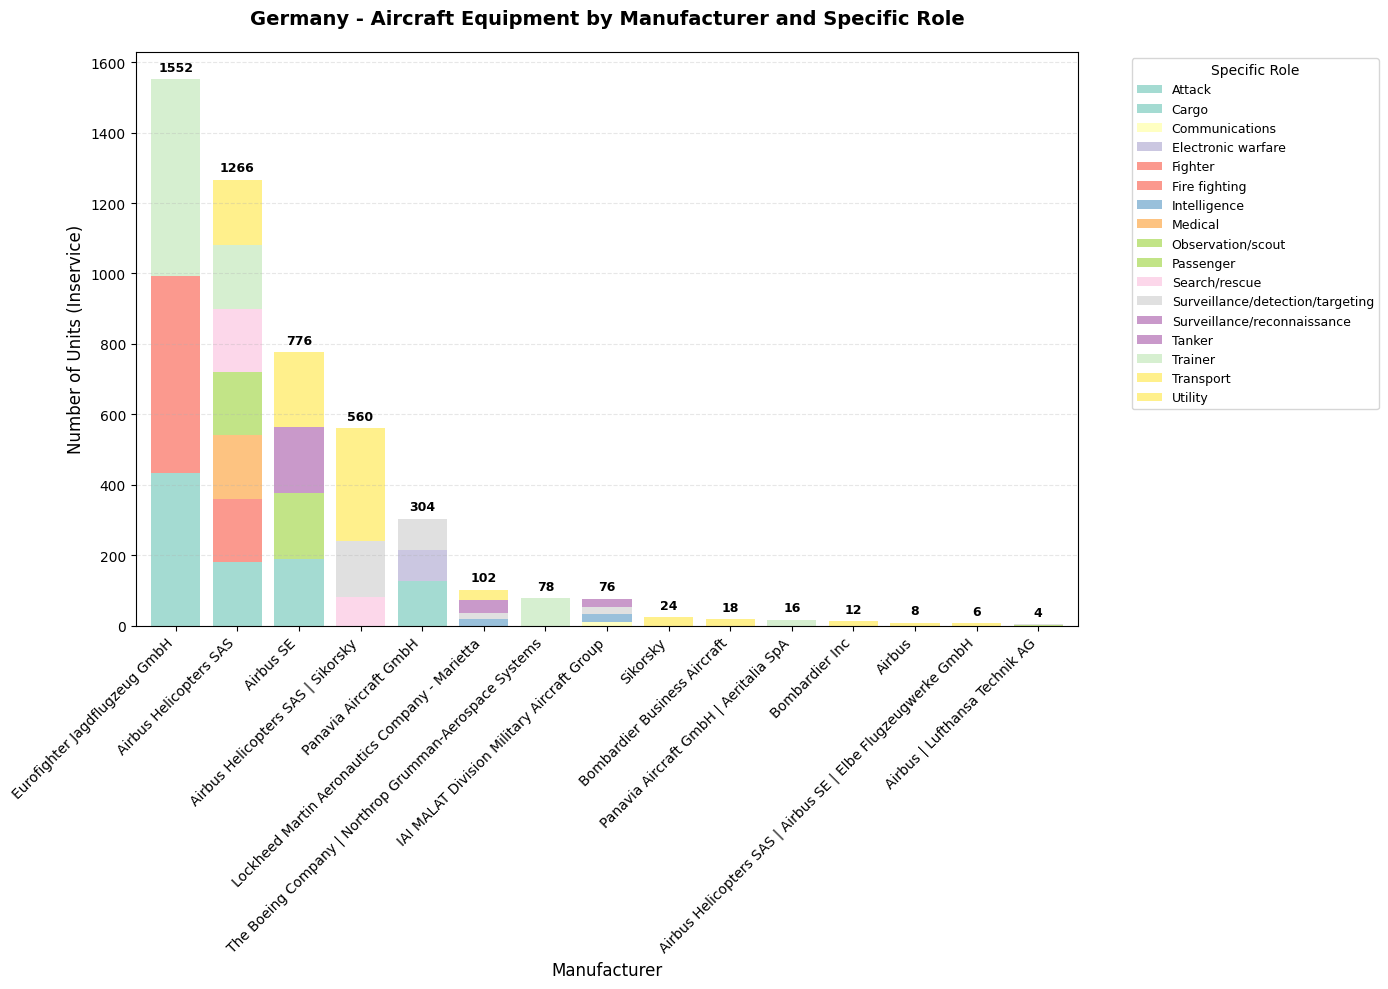


Specific Roles Breakdown:
----------------------------------------
Trainer                      834 units ( 17.4%)
Transport                    656 units ( 13.7%)
Attack                       560 units ( 11.7%)
Fighter                      560 units ( 11.7%)
Cargo                        368 units (  7.7%)
Passenger                    368 units (  7.7%)
Surveillance/detection/targeting    290 units (  6.0%)
Search/rescue                260 units (  5.4%)
Tanker                       206 units (  4.3%)
Fire fighting                180 units (  3.7%)
Medical                      180 units (  3.7%)
Utility                      160 units (  3.3%)
Electronic warfare            88 units (  1.8%)
Surveillance/reconnaissance     40 units (  0.8%)
Intelligence                  40 units (  0.8%)
Communications                10 units (  0.2%)
Observation/scout              2 units (  0.0%)

Additional Statistics:
------------------------------
Total manufacturers: 15
Total unique systems: 25
Mos

,Manufacturer,Systemname,Inservice
2,Airbus Helicopters SAS,H145M,1260.0
14,Eurofighter Jagdflugzeug GmbH,Typhoon Tranche 2,924.0
9,Airbus SE,A400M,752.0
4,Airbus Helicopters SAS | Sikorsky,CH-53GA,480.0
15,Eurofighter Jagdflugzeug GmbH,Typhoon Tranche 3,372.0
13,Eurofighter Jagdflugzeug GmbH,Typhoon Tranche 1,256.0
20,Panavia Aircraft GmbH,Tornado GE-ECR,176.0
21,Panavia Aircraft GmbH,Tornado IDS,128.0
19,Lockheed Martin Aeronautics Company - Marietta,KC-130J,90.0
5,Airbus Helicopters SAS | Sikorsky,CH-53GS,80.0


In [36]:
analyze_country_equipment(merged_inventory_df, 'Germany', 'Aircraft', top_n=20)


France - Land Vehicles Equipment Analysis
Total equipment entries: 530
Using quantity column(s): ['Inservice']

Top 10 Manufacturers by Total Equipment:
--------------------------------------------------
 1. Arquus SAS                151550 units ( 72.4%)
 2. Arquus SAS | RTX Corporation-Goleta | Arquus Garchizy  30000 units ( 14.3%)
 3. Panhard General Defense | Arquus SAS | Panhard General Defense | Arquus Saint-Nazaire  11568 units (  5.5%)
 4. KNDS France S A - Versailles Office   5543 units (  2.6%)
 5. Panhard General Defense     2184 units (  1.0%)
 6. Saab AB | BAE Systems Hägglunds AB | Kia Corporation   2142 units (  1.0%)
 7. Arquus Saint-Nazaire        2008 units (  1.0%)
 8. KNDS | Texelis              1248 units (  0.6%)
 9. BAE Systems Hägglunds AB    1011 units (  0.5%)
10. Thales SA                    960 units (  0.5%)

Top 10 Equipment Systems:
----------------------------------------------------------------------
 4. PVP                            | Arquus SAS     

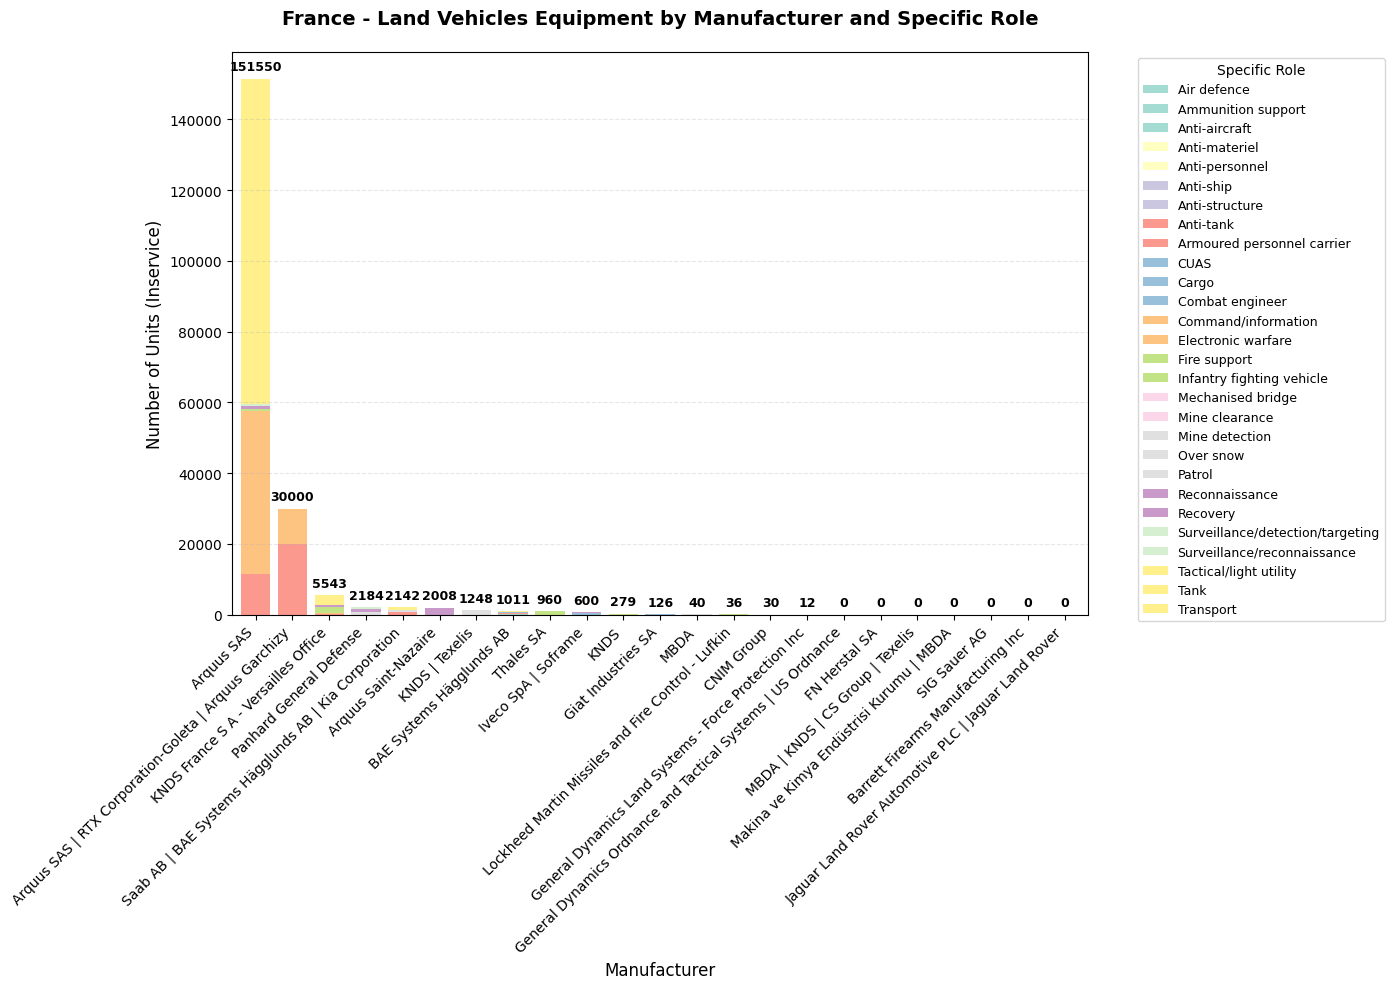


Specific Roles Breakdown:
----------------------------------------
Command/information        56449 units ( 28.5%)
Transport                  46833 units ( 23.7%)
Tactical/light utility     45960 units ( 23.2%)
Armoured personnel carrier  22631 units ( 11.4%)
Anti-tank                  10000 units (  5.1%)
Reconnaissance              3966 units (  2.0%)
Tank                        2766 units (  1.4%)
Fire support                2181 units (  1.1%)
Patrol                      1976 units (  1.0%)
Infantry fighting vehicle   1551 units (  0.8%)
Surveillance/detection/targeting   1448 units (  0.7%)
Over snow                    714 units (  0.4%)
Cargo                        609 units (  0.3%)
Recovery                     282 units (  0.1%)
Ammunition support           159 units (  0.1%)
Combat engineer              126 units (  0.1%)
Mine clearance                68 units (  0.0%)
Mechanised bridge             30 units (  0.0%)
Mine detection                20 units (  0.0%)
Anti-aircraf

,Manufacturer,Systemname,Inservice
3,Arquus SAS,PVP,137880.0
4,Arquus SAS | RTX Corporation-Goleta | Arquus G...,VAB,30000.0
43,Panhard General Defense | Arquus SAS | Panhard...,VBL,11568.0
0,Arquus SAS,Griffon,11500.0
26,KNDS France S A - Versailles Office,Leclerc,2664.0
42,Panhard General Defense,VB2L,2184.0
1,Arquus SAS,Jaguar,2160.0
45,Saab AB | BAE Systems Hägglunds AB | Kia Corpo...,Bv 206,2142.0
5,Arquus Saint-Nazaire,VBL Ultima,2008.0
32,KNDS France S A - Versailles Office,VCI,1272.0


In [37]:
analyze_country_equipment(merged_inventory_df, 'France', 'Land Vehicles')


All EU+UK Countries - Aircraft Equipment Analysis
Total equipment entries: 3484
Countries covered: 27
Countries: Austria, Belgium, Bulgaria, Croatia, Cyprus, Czech Republic, Denmark, Estonia, Finland, France, Germany, Greece, Hungary, Ireland, Italy, Latvia, Lithuania, Luxembourg, Malta, Netherlands, Poland, Portugal, Romania, Slovakia, Spain, Sweden, United Kingdom
Using quantity column(s): ['Inservice']

Top 20 Manufacturers by Total Equipment:
--------------------------------------------------
 1. Airbus Helicopters SAS      4030 units ( 13.1%)
 2. Eurofighter Jagdflugzeug GmbH   2818 units (  9.1%)
 3. Lockheed Martin Aeronautics Company - Marietta   2804 units (  9.1%)
 4. Airbus SE                   1946 units (  6.3%)
 5. Saab AB                     1700 units (  5.5%)
 6. Leonardo SpA-Helicopters-HQ   1404 units (  4.6%)
 7. Dassault Aviation SA         948 units (  3.1%)
 8. Lockheed Martin Corporation    798 units (  2.6%)
 9. NHIndustries SAS             698 units (  2.3%)


/tmp/ipykernel_6197/575146332.py:200: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


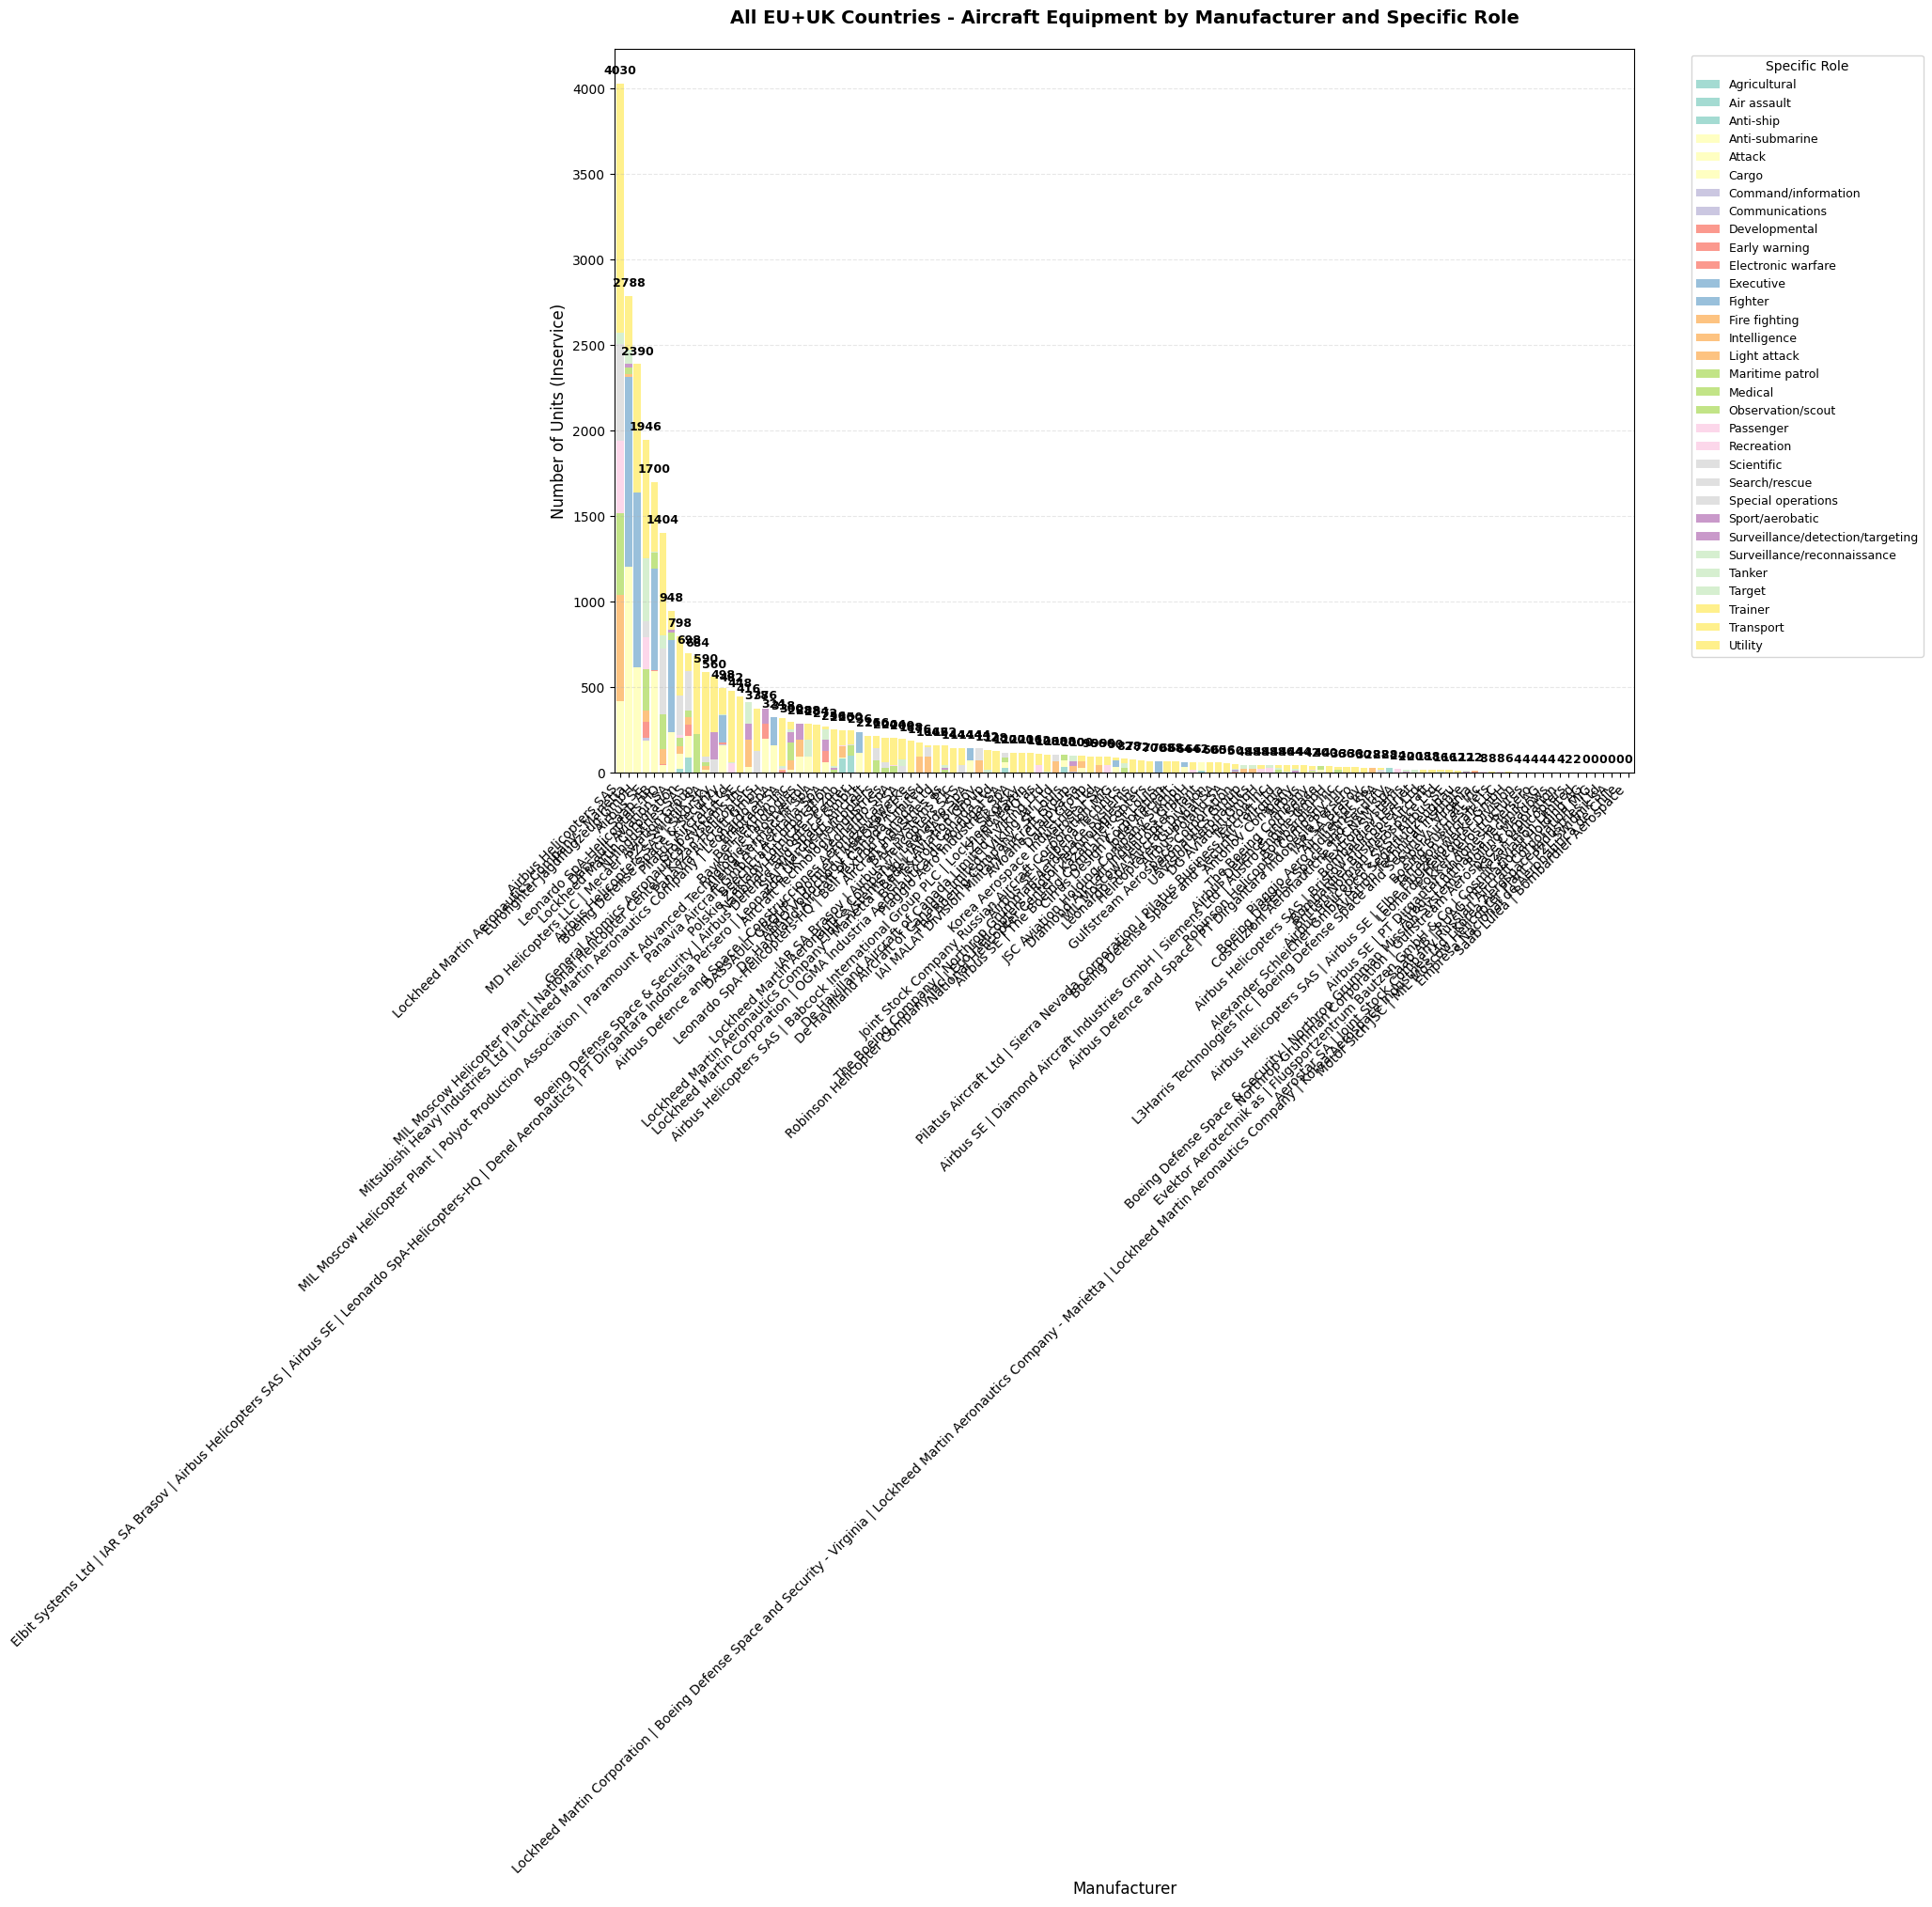


Specific Roles Breakdown:
----------------------------------------
Trainer                     5234 units ( 17.3%)
Transport                   4850 units ( 16.0%)
Attack                      3926 units ( 13.0%)
Fighter                     3908 units ( 12.9%)
Utility                     1924 units (  6.4%)
Search/rescue               1912 units (  6.3%)
Medical                     1290 units (  4.3%)
Fire fighting                816 units (  2.7%)
Surveillance/reconnaissance    708 units (  2.3%)
Surveillance/detection/targeting    696 units (  2.3%)
Light attack                 652 units (  2.2%)
Passenger                    648 units (  2.1%)
Cargo                        624 units (  2.1%)
Tanker                       502 units (  1.7%)
Observation/scout            422 units (  1.4%)
Intelligence                 344 units (  1.1%)
Electronic warfare           326 units (  1.1%)
Recreation                   268 units (  0.9%)
Anti-submarine               268 units (  0.9%)
Maritime pa

,Manufacturer,Systemname,Inservice
35,Airbus Helicopters SAS,H145M,2952.0
50,Airbus SE,A400M,1512.0
170,Eurofighter Jagdflugzeug GmbH,Typhoon Tranche 2,1192.0
324,Saab AB,JAS 39C,776.0
251,Lockheed Martin Aeronautics Company - Marietta,F-16C Block 52+,688.0
...,...,...,...
114,Boeing Defense Space and Security,AH-64DN,0.0
310,Pilatus Aircraft Ltd,PC-7 MKX,0.0
10,Aerostar SA | Joint Stock Company Russian Airc...,MiG-21UMD,0.0
102,Boeing Defense Space & Security,C-135FR,0.0


In [38]:
analyze_country_equipment(merged_inventory_df, 'All', 'Aircraft', top_n=20)

In [39]:
merged_inventory_df[merged_inventory_df.Systemname.str.contains('F-35')]

,Familyname,Generic role,Mannedunmanned,Manufacturer,Operatorcountry,Operatorcountry (group),Operatorname,Specific role,Subtype,Systemname,Uid,Inservice,Dataset_type
8648,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Czech Republic,Europe & CIS,Czech Air Force,Attack,Fixed-wing,F-35A,30QlTxDJM74n9nlgMaTd5n,0.0,Aircraft
8651,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Poland,Europe & CIS,Polish Air Force,Attack,Fixed-wing,F-35A,5qdNEY7AfpEIUs8Rgzd1pk,0.0,Aircraft
8653,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Romania,Europe & CIS,Romanian Air Force,Attack,Fixed-wing,F-35A,25RApDQWCihlbOWlslcMpp,0.0,Aircraft
8654,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Belgium,Europe & CIS,Belgian Air Component,Attack,Fixed-wing,F-35A,6p25DUk5MyWvN0lNyQlvRt,1.0,Aircraft
8657,F-35,Combat/offensive,Manned,Lockheed Martin Aeronautics Company | Leonardo...,Italy,Europe & CIS,Italian Air Force,Attack,Fixed-wing,F-35B,4pdqOcegGb7d7HlRq29aIm,2.0,Aircraft
8681,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Denmark,Europe & CIS,Royal Danish Air Force,Attack,Fixed-wing,F-35A,1QcZnNrQ6uIfKI793AWoZc,17.0,Aircraft
8686,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Italy,Europe & CIS,Italian Air Force,Attack,Fixed-wing,F-35A,1FDVbCJz5UrLz1dsaSUPhh,23.0,Aircraft
8694,F-35,Combat/offensive,Manned,Lockheed Martin Aeronautics Company | Leonardo...,United Kingdom,Europe & CIS,UK Royal Air Force,Attack,Fixed-wing,F-35B,1FolKfyJPHnLiT0UYF3ac7,34.0,Aircraft
8697,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Netherlands,Europe & CIS,Royal Netherlands Air Force,Attack,Fixed-wing,F-35A,40EgzQPVy2shebkqi9W6Am,40.0,Aircraft
8712,F-35,Combat/offensive,Manned,Mitsubishi Heavy Industries Ltd | Lockheed Mar...,Czech Republic,Europe & CIS,Czech Air Force,Fighter,Fixed-wing,F-35A,30QlTxDJM74n9nlgMaTd5n,0.0,Aircraft


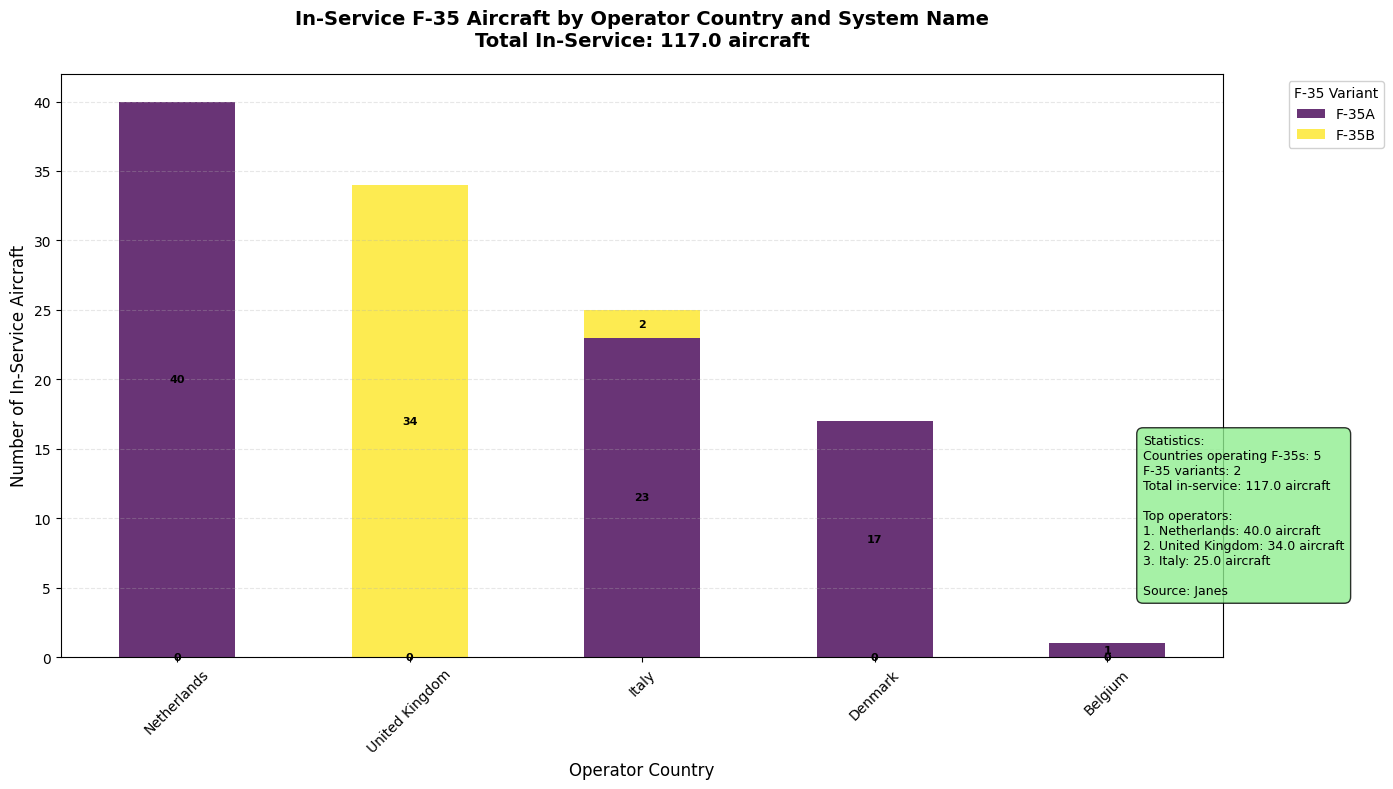


F-35 IN-SERVICE AIRCRAFT SUMMARY

Overall Statistics:
Total countries operating F-35s: 5
Total F-35 variants: 2
Total in-service aircraft: 117.0

By Country (sorted by total):


ValueError: Unknown format code 'd' for object of type 'float'

In [40]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Filter for F-35 aircraft that are in service (Inservice > 0)
f35_data = merged_inventory_df[
    (merged_inventory_df['Systemname'].str.contains('F-35', case=False, na=False)) & 
    (merged_inventory_df['Inservice'] > 0)
].copy()

# Drop duplicates ignoring 'Subtype' and 'Specific role'
f35_data = f35_data.drop_duplicates(
    subset=[col for col in f35_data.columns if col not in ['Subtype', 'Specific role']]
)



if len(f35_data) == 0:
    print("No in-service F-35 data found. Check if the data contains F-35 entries with Inservice > 0.")
else:
    # Group by operator country and system name, sum the in-service numbers
    f35_summary = f35_data.groupby(['Operatorcountry', 'Systemname'])['Inservice'].sum().unstack(fill_value=0)
    
    # Sort countries by total F-35s (descending)
    country_totals = f35_summary.sum(axis=1).sort_values(ascending=False)
    f35_summary = f35_summary.loc[country_totals.index]
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(14, 8))
    
    # Create stacked bar chart
    f35_summary.plot(kind='bar', stacked=True, ax=ax, colormap='viridis', alpha=0.8)
    
    # Calculate total F-35s across all countries
    total_f35s = f35_data['Inservice'].sum()
    
    # Customize the plot
    ax.set_title(f'In-Service F-35 Aircraft by Operator Country and System Name\n'
                f'Total In-Service: {total_f35s} aircraft', 
                fontsize=14, fontweight='bold', pad=20)
    
    ax.set_xlabel('Operator Country', fontsize=12)
    ax.set_ylabel('Number of In-Service Aircraft', fontsize=12)
    
    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45, labelsize=10)
    
    # Add legend
    legend = ax.legend(title='F-35 Variant', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
    legend.set_frame_on(True)
    legend.get_frame().set_facecolor('white')
    legend.get_frame().set_alpha(0.9)
    
    # Add value labels on bars
    for container in ax.containers:
        ax.bar_label(container, label_type='center', fontsize=8, weight='bold')
    
    # Add grid for better readability
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    
    # Create statistics box
    stats_text = f"Statistics:\n"
    stats_text += f"Countries operating F-35s: {len(f35_summary)}\n"
    stats_text += f"F-35 variants: {len(f35_summary.columns)}\n"
    stats_text += f"Total in-service: {total_f35s} aircraft\n\n"
    
    # Add top 3 operators
    stats_text += "Top operators:\n"
    for i, (country, total) in enumerate(country_totals.head(3).items(), 1):
        stats_text += f"{i}. {country}: {total} aircraft\n"
    
    stats_text += "\nSource: Janes"
    
    # Position the statistics box
    plt.figtext(0.82, 0.45, stats_text, fontsize=9, 
               bbox=dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.8),
               verticalalignment='top')
    
    # Adjust layout
    plt.tight_layout()
    plt.show()
    
    # Print detailed summary
    print("\n" + "="*80)
    print("F-35 IN-SERVICE AIRCRAFT SUMMARY")
    print("="*80)
    
    print(f"\nOverall Statistics:")
    print(f"Total countries operating F-35s: {len(f35_summary)}")
    print(f"Total F-35 variants: {len(f35_summary.columns)}")
    print(f"Total in-service aircraft: {total_f35s}")
    
    print(f"\nBy Country (sorted by total):")
    for country, total in country_totals.items():
        print(f"{country:25} {total:3d} aircraft")
        # Show breakdown by variant for this country
        country_variants = f35_summary.loc[country]
        country_variants = country_variants[country_variants > 0]
        for variant, count in country_variants.items():
            print(f"  └─ {variant:20} {count:3d}")
    
    print(f"\nBy F-35 Variant:")
    variant_totals = f35_summary.sum().sort_values(ascending=False)
    for variant, total in variant_totals.items():
        if total > 0:
            percentage = (total / total_f35s) * 100
            print(f"{variant:25} {total:3d} aircraft ({percentage:5.1f}%)")
    
    # Show the raw data for verification
    print(f"\nRaw data used ({len(f35_data)} records):")
    print(f35_data[['Operatorcountry', 'Systemname', 'Inservice']].to_string(index=False))

## Causal Analysis

In [17]:
import_df, export_df


(      SIPRI AT Database ID       Supplier       Recipient  \
 0                    36708        Germany         Austria   
 1                    67858  United States         Austria   
 2                    67858  United States         Austria   
 3                    67858  United States         Austria   
 4                    67858  United States         Austria   
 ...                    ...            ...             ...   
 3702                 34600  United States  United Kingdom   
 3703                 59151  United States  United Kingdom   
 3704                 59151  United States  United Kingdom   
 3705                 39073  United States  United Kingdom   
 3706                 39073  United States  United Kingdom   
 
                     Designation                 Description  \
 0                       Dingo-2  armoured personnel carrier   
 1        vehicle engine 401-600              vehicle engine   
 2        vehicle engine 401-600              vehicle engine  

In [19]:
budget_trends_df['entity_name'].unique()

array(['Defence Budget (USD million real)', 'Army', 'Air Force', 'Navy',
       'Defence-wide', 'Army procurement', 'Army personnel', 'Army RDT&E',
       'Army other', 'Army O&M', 'Navy procurement', 'Navy other',
       'Navy O&M', 'Navy RDT&E', 'Navy personnel', 'Air Force RDT&E',
       'Air Force O&M', 'Air Force personnel', 'Air Force procurement',
       'Air Force other', 'Defence-wide other', 'Defence-wide personnel',
       'Defence-wide O&M', 'Defence-wide RDT&E',
       'Defence-wide procurement', 'procurement - Intelligence',
       'procurement - Missiles', 'procurement - Sonar',
       'procurement - USV', 'procurement - OTHER',
       'procurement - Aircraft', 'procurement - Space Sys',
       'procurement - PGW', 'procurement - Ground Veh',
       'procurement - EOIR', 'procurement - UAV', 'procurement - UGV',
       'procurement - Mil Comm', 'procurement - Radar',
       'procurement - C2', 'procurement - Ships', 'RDT&E - Missiles',
       'RDT&E - Sonar', 'Army Petro

In [20]:
budget_trends_df

,id,country_name,entity_name,2005,2006,2007,2008,2009,2010,2011,...,2034,2035,2036,2037,2038,2039,2040,2041,created_on,entity_order
0,150481,Colombia,Defence Budget (USD million real),4232.859718,4531.708078,4682.640198,6115.106131,5869.187908,5702.914597,5808.953825,...,12455.240108,13209.779522,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 12:51:17.068500,1
1,152713,Turkey,Defence Budget (USD million real),9887.540223,9827.296344,10480.794826,9558.416133,10745.413324,10604.890424,10875.995502,...,25173.012091,25551.603798,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 14:18:58.869400,1
2,152714,Turkey,Army,5243.152639,4923.954404,5461.369222,4947.299592,5553.720274,5821.390720,5924.812628,...,13593.426529,13797.866051,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 14:18:58.869400,2
3,152715,Turkey,Air Force,2708.421331,3021.074421,3065.318608,2846.013841,3531.156408,2765.597606,2757.861240,...,6872.232301,6975.587837,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 14:18:58.869400,4
4,152716,Turkey,Navy,1660.640058,1625.655244,1680.156953,1527.923563,1397.904630,1758.160663,1868.943069,...,4027.681935,4088.256608,NaN,NaN,NaN,NaN,NaN,NaN,2025-01-09 14:18:58.869400,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10411,158476,Mexico,total procurement,98.393813,0.002565,34.528755,60.096471,220.528391,206.437638,243.018750,...,1558.701843,1573.118975,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-21 11:33:02.613900,90
10412,158567,Italy,total procurement,5593.733370,3895.888060,6341.329016,6780.422507,5638.400274,5174.074838,5288.564854,...,8508.090041,8257.733208,NaN,NaN,NaN,NaN,NaN,NaN,2025-04-22 09:23:14.082300,90
10413,158661,Spain,total procurement,2939.582560,2776.732726,2870.722020,2931.703733,2386.857901,1752.004365,1448.383107,...,7718.606768,7404.549395,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-13 07:39:02.817300,90
10414,158754,Canada,total procurement,2474.483789,2729.404069,2980.740103,3115.103359,3594.173547,3682.026152,2554.277509,...,6106.842944,6173.457718,NaN,NaN,NaN,NaN,NaN,NaN,2025-05-14 16:45:06.001500,90


In [25]:
def create_defense_budget_chart(df, country, branch):
    """
    Create a stacked bar chart for defense budget data
    
    Parameters:
    df: DataFrame with columns ['country_name', 'entity_name', year columns...]
    country: str - country to filter for
    branch: str - military branch ('Army', 'Navy', 'Air Force')
    """
    
    # Filter data for the selected country
    country_data = df[df['country_name'] == country].copy()
    
    # Get year columns (assuming they're numeric columns)
    year_cols = [col for col in df.columns if str(col).isdigit() and int(col) < 2025]
    
    # Filter for the specific branch and its procurement/RDT&E
    procurement_entity = f"{branch} procurement"
    rdte_entity = f"{branch} RDT&E"
    
    # Get procurement data
    procurement_data = country_data[country_data['entity_name'] == procurement_entity]
    rdte_data = country_data[country_data['entity_name'] == rdte_entity]
    
    if procurement_data.empty and rdte_data.empty:
        print(f"No data found for {branch} in {country}")
        return
    
    # Prepare data for plotting
    years = []
    procurement_values = []
    rdte_values = []
    
    for year in year_cols:
        years.append(int(year))
        
        # Get procurement value
        if not procurement_data.empty:
            proc_val = procurement_data[year].iloc[0] if not procurement_data[year].isna().iloc[0] else 0
        else:
            proc_val = 0
            
        # Get RDT&E value
        if not rdte_data.empty:
            rdte_val = rdte_data[year].iloc[0] if not rdte_data[year].isna().iloc[0] else 0
        else:
            rdte_val = 0
            
        procurement_values.append(proc_val)
        rdte_values.append(rdte_val)
    
    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(12, 8))
    
    width = 0.6
    x = np.arange(len(years))
    
    # Create stacked bars
    p1 = ax.bar(x, procurement_values, width, label=f'{branch} Procurement', 
                color='#2E86AB', alpha=0.8)
    p2 = ax.bar(x, rdte_values, width, bottom=procurement_values, 
                label=f'{branch} RDT&E', color='#A23B72', alpha=0.8)
    
    # Customize the chart
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Budget (USD millions)', fontsize=12)
    ax.set_title(f'{country} - {branch} Budget: Procurement vs RDT&E', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    ax.legend()
    
    # Add value labels on bars
    for i, (proc, rdte) in enumerate(zip(procurement_values, rdte_values)):
        if proc > 0:
            ax.text(i, proc/2, f'{proc:.0f}', ha='center', va='center', fontweight='bold')
        if rdte > 0:
            ax.text(i, proc + rdte/2, f'{rdte:.0f}', ha='center', va='center', fontweight='bold')
    
    # Format y-axis to show values in millions
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
    
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

def get_available_countries_and_branches(df):
    """
    Get available countries and military branches from the dataset
    """
    countries = df['country_name'].unique()
    
    # Extract branches from entity_name column
    branches = set()
    for entity in df['entity_name'].unique():
        if 'Army' in entity:
            branches.add('Army')
        elif 'Navy' in entity:
            branches.add('Navy')
        elif 'Air Force' in entity:
            branches.add('Air Force')
    
    return sorted(countries), sorted(branches)

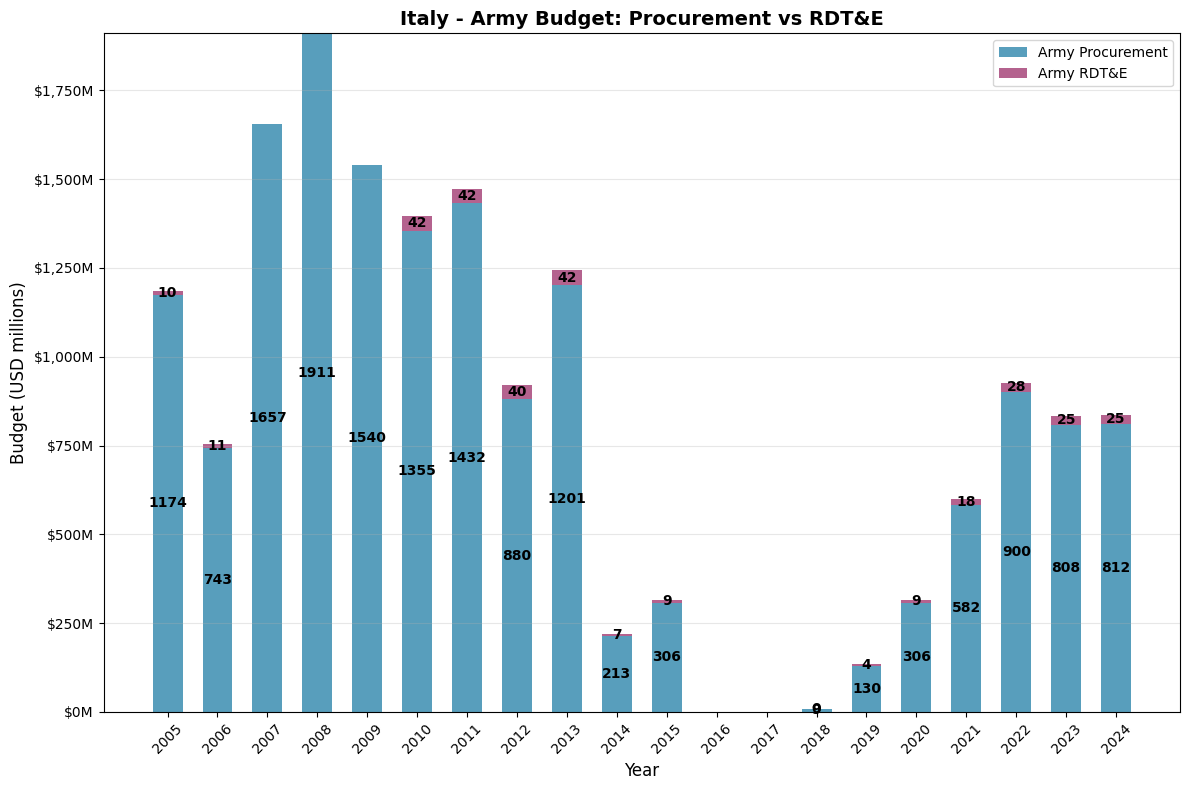

In [34]:
create_defense_budget_chart(budget_trends_df, 'Italy', 'Army')

In [31]:
import_df[import_df['Recipient']=='Italy']

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production,Supplier_region_EU
1596,63717,France,Italy,2R2M 120mm,mortar,Artillery,2018,Yes,4,Yes,2019,No,New,0.30,0.30,1.2,No,EU+UK
1597,63717,France,Italy,2R2M 120mm,mortar,Artillery,2018,Yes,6,Yes,2020,Yes,New,0.30,0.30,1.8,No,EU+UK
1598,63717,France,Italy,2R2M 120mm,mortar,Artillery,2018,Yes,4,Yes,2021,Yes,New,0.30,0.30,1.2,No,EU+UK
1599,63717,France,Italy,2R2M 120mm,mortar,Artillery,2018,Yes,6,Yes,2022,Yes,New,0.30,0.30,1.8,No,EU+UK
1600,63717,France,Italy,2R2M 120mm,mortar,Artillery,2018,Yes,10,Yes,2023,Yes,New,0.30,0.30,3.0,No,EU+UK
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1864,54492,United States,Italy,F-35B Lightning-2,FGA aircraft,Aircraft,2006,Yes,1,Yes,2022,No,New,60.00,60.00,60.0,Yes,United States
1865,54492,United States,Italy,F-35B Lightning-2,FGA aircraft,Aircraft,2006,Yes,3,Yes,2023,No,New,60.00,60.00,180.0,Yes,United States
1866,36677,United States,Italy,MQ-9 UAV,UAV,Aircraft,2008,Yes,2,No,2010,No,New,6.50,6.50,13.0,No,United States
1867,57278,United States,Italy,Paveway,guided bomb,Missiles,2012,Yes,125,Yes,2014,Yes,New,0.02,0.02,2.5,No,United States


In [37]:
import pandas as pd

# Sample data
equipment = ['Armoured vehicles', 'Engines', 'Missiles', 'Sensors', 'Aircraft',
             'Other', 'Ships', 'Artillery', 'Air-defence systems',
             'Naval weapons', 'Satellites']

# Create DataFrame
df = pd.DataFrame(equipment, columns=['equipment'])

# Define mapping function
def map_entity(equip):
    army = {'Armoured vehicles', 'Artillery', 'Air-defence systems'}
    air_force = {'Aircraft', 'Satellites'}
    navy = {'Ships', 'Naval weapons'}

    # Shared categories
    if equip in army:
        return 'Army'
    elif equip in air_force:
        return 'Air Force'
    elif equip in navy:
        return 'Navy'
    elif equip == 'Engines':
        return 'Multi-service'
    elif equip == 'Missiles':
        return 'Multi-service'
    elif equip == 'Sensors':
        return 'Multi-service'
    else:
        return 'Unknown'

# Apply mapping
import_df['entity_name'] = import_df['Armament category'].apply(map_entity)

In [43]:
import_df[import_df['Recipient']=='Italy'][['Supplier','Recipient','Designation','Description','Armament category','Order date','Numbers delivered','TIV delivery values','Supplier_region_EU',	'entity_name']]

,Supplier,Recipient,Designation,Description,Armament category,Order date,Numbers delivered,TIV delivery values,Supplier_region_EU,entity_name
1596,France,Italy,2R2M 120mm,mortar,Artillery,2018,4,1.2,EU+UK,Army
1597,France,Italy,2R2M 120mm,mortar,Artillery,2018,6,1.8,EU+UK,Army
1598,France,Italy,2R2M 120mm,mortar,Artillery,2018,4,1.2,EU+UK,Army
1599,France,Italy,2R2M 120mm,mortar,Artillery,2018,6,1.8,EU+UK,Army
1600,France,Italy,2R2M 120mm,mortar,Artillery,2018,10,3.0,EU+UK,Army
...,...,...,...,...,...,...,...,...,...,...
1864,United States,Italy,F-35B Lightning-2,FGA aircraft,Aircraft,2006,1,60.0,United States,Air Force
1865,United States,Italy,F-35B Lightning-2,FGA aircraft,Aircraft,2006,3,180.0,United States,Air Force
1866,United States,Italy,MQ-9 UAV,UAV,Aircraft,2008,2,13.0,United States,Air Force
1867,United States,Italy,Paveway,guided bomb,Missiles,2012,125,2.5,United States,Multi-service


In [58]:
import_df[import_df['Order date']==int(2018)]

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production,Supplier_region_EU,entity_name
44,64268,Italy,Austria,RAT-31DL,air-search radar,Sensors,2018,Yes,1,No,2020,No,New,12.50,12.50,12.5,No,EU+UK,Multi-service
45,64268,Italy,Austria,RAT-31DL,air-search radar,Sensors,2018,Yes,2,Yes,2021,No,New,12.50,12.50,25.0,No,EU+UK,Multi-service
53,30304,United States,Belgium,F-35A Lightning-2,FGA aircraft,Aircraft,2018,No,7,Yes,2024,NaN,New,55.00,55.00,385.0,No,United States,Air Force
58,63274,Netherlands,Belgium,SQUIRE,ground surveillance radar,Sensors,2018,No,9,No,2019,No,New,0.50,0.50,4.5,No,EU+UK,Multi-service
67,64072,United States,Belgium,JDAM,guided bomb,Missiles,2018,No,200,Yes,2019,Yes,New,0.02,0.02,4.0,No,United States,Multi-service
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3383,62338,Germany,United Kingdom,ship engine 4001-6000,ship engine,Engines,2018,No,3,NaN,2024,Yes,New,1.50,1.50,4.5,No,EU+UK,Multi-service
3384,62338,Germany,United Kingdom,ship engine 4001-6000,ship engine,Engines,2018,No,6,No,2022,No,New,1.50,1.50,9.0,No,EU+UK,Multi-service
3695,62520,United States,United Kingdom,Mk-54 LWT,anti-submarine torpedo,Missiles,2018,Yes,10,Yes,2020,Yes,New,0.50,0.50,5.0,No,United States,Multi-service
3696,62520,United States,United Kingdom,Mk-54 LWT,anti-submarine torpedo,Missiles,2018,Yes,15,Yes,2021,Yes,New,0.50,0.50,7.5,No,United States,Multi-service


In [61]:
def create_defense_budget_chart(df, import_df, country):
    """
    Create a stacked bar chart for defense budget data showing all branches and imports
    
    Parameters:
    df: DataFrame with columns ['country_name', 'entity_name', year columns...]
    import_df: DataFrame with columns ['Recipient', 'Order date', 'TIV delivery values', 'entity_name']
    country: str - country to filter for
    """
    # Filter data for the selected country
    country_data = df[df['country_name'] == country].copy()
    
    # Get year columns (assuming they're numeric columns)
    year_cols = [col for col in df.columns if str(col).isdigit() and int(col) < 2025]
    
    # Define branches and their components
    branches = ['Army', 'Navy', 'Air Force']
    
    # Prepare data structure for budget data
    years = [int(year) for year in year_cols]
    budget_data = {}
    
    # Initialize data structure for each branch and component
    for branch in branches:
        budget_data[f'{branch} Procurement'] = []
        budget_data[f'{branch} RDT&E'] = []
    
    # Extract budget data for each year
    for year in year_cols:
        for branch in branches:
            procurement_entity = f"{branch} procurement"
            rdte_entity = f"{branch} RDT&E"
            
            # Get procurement data
            procurement_data = country_data[country_data['entity_name'] == procurement_entity]
            if not procurement_data.empty:
                proc_val = procurement_data[year].iloc[0] if not procurement_data[year].isna().iloc[0] else 0
            else:
                proc_val = 0
            
            # Get RDT&E data
            rdte_data = country_data[country_data['entity_name'] == rdte_entity]
            if not rdte_data.empty:
                rdte_val = rdte_data[year].iloc[0] if not rdte_data[year].isna().iloc[0] else 0
            else:
                rdte_val = 0
            
            budget_data[f'{branch} Procurement'].append(proc_val)
            budget_data[f'{branch} RDT&E'].append(rdte_val)
    
    # Process import data
    # Filter import data for the selected country
    import_country_data = import_df[import_df['Recipient'] == country].copy()
    
    # Convert Order date to year
    import_country_data['order_year'] = pd.to_datetime(import_country_data['Order date']).dt.year
    print(import_country_data)
    # Get unique entity names from import data
    import_entities = import_country_data['entity_name'].unique()
    
    # Initialize import data structure
    import_data = {}
    for entity in import_entities:
        import_data[entity] = []
    
    # Aggregate import data by year and entity
    for year in years:
        year_data = import_country_data[import_country_data['Order date'] == year]
        print(year_data)
        for entity in import_entities:
            entity_data = year_data[year_data['entity_name'] == entity]
            total_tiv = entity_data['TIV delivery values'].sum() if not entity_data.empty else 0
            import_data[entity].append(total_tiv)

    # Check if we have any data
    has_budget_data = any(any(v > 0 for v in values) for values in budget_data.values())
    has_import_data = any(any(v > 0 for v in values) for values in import_data.values())
    
    if not has_budget_data and not has_import_data:
        print(f"No defense budget or import data found for {country}")
        return
    
    # Create the stacked bar chart
    fig, ax = plt.subplots(figsize=(16, 8))
    
    width = 0.35
    x = np.arange(len(years))
    
    # Define colors for budget components
    budget_colors = {
        'Army Procurement': '#2E86AB',
        'Army RDT&E': '#A23B72',
        'Navy Procurement': '#F18F01',
        'Navy RDT&E': '#C73E1D',
        'Air Force Procurement': '#5D737E',
        'Air Force RDT&E': '#64A6BD'
    }
    
    # Define colors for import entities (using a different color palette)
    import_color_palette = ['#8B4513', '#FF6347', '#32CD32', '#FF69B4', '#4169E1', '#FFD700', '#FF4500', '#9370DB']
    import_colors = {}
    for i, entity in enumerate(import_entities):
        import_colors[entity] = import_color_palette[i % len(import_color_palette)]
    
    # Create budget stacked bars (left bars)
    bottom_budget = np.zeros(len(years))
    budget_bars = []
    
    if has_budget_data:
        for branch in branches:
            for component in ['Procurement', 'RDT&E']:
                key = f'{branch} {component}'
                values = budget_data[key]
                
                # Only create bar if there's data
                if any(v > 0 for v in values):
                    bar = ax.bar(x - width/2, values, width, bottom=bottom_budget, 
                               label=f'Budget: {key}', color=budget_colors[key], alpha=0.8)
                    budget_bars.append((bar, values, bottom_budget.copy()))
                    bottom_budget += np.array(values)
    
    # Create import stacked bars (right bars)
    bottom_import = np.zeros(len(years))
    import_bars = []
    
    if has_import_data:
        for entity in import_entities:
            values = import_data[entity]
            
            # Only create bar if there's data
            if any(v > 0 for v in values):
                bar = ax.bar(x + width/2, values, width, bottom=bottom_import, 
                           label=f'Import: {entity}', color=import_colors[entity], alpha=0.8)
                import_bars.append((bar, values, bottom_import.copy()))
                bottom_import += np.array(values)
    
    # Customize the chart
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Value (USD millions / TIV)', fontsize=12)
    ax.set_title(f'{country} - Defense Budget vs Arms Imports', 
                fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(years, rotation=45)
    
    # Create legend with two columns
    handles, labels = ax.get_legend_handles_labels()
    budget_handles = [h for h, l in zip(handles, labels) if l.startswith('Budget:')]
    import_handles = [h for h, l in zip(handles, labels) if l.startswith('Import:')]
    budget_labels = [l for l in labels if l.startswith('Budget:')]
    import_labels = [l for l in labels if l.startswith('Import:')]
    
    if budget_handles and import_handles:
        legend1 = ax.legend(budget_handles, budget_labels, loc='upper left', bbox_to_anchor=(1.05, 1))
        legend2 = ax.legend(import_handles, import_labels, loc='upper left', bbox_to_anchor=(1.05, 0.6))
        ax.add_artist(legend1)
    else:
        ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    
    # Add value labels on bars (only for significant values to avoid clutter)
    all_bars = budget_bars + import_bars
    max_total = max(max(bottom_budget + bottom_import), max(bottom_budget), max(bottom_import)) if len(all_bars) > 0 else 1
    
    for bar_info in all_bars:
        bar, values, bottom_vals = bar_info
        for i, (val, bottom_val) in enumerate(zip(values, bottom_vals)):
            if val > max_total * 0.05:  # Only show if > 5% of max total
                ax.text(bar[i].get_x() + bar[i].get_width()/2, bottom_val + val/2, f'{val:.0f}', 
                       ha='center', va='center', fontweight='bold', fontsize=8)
    
    # Format y-axis
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}M'))
    
    # Add text to explain the two bar types
    ax.text(0.02, 0.98, 'Left bars: Budget data (USD millions)', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    ax.text(0.02, 0.93, 'Right bars: Import data (TIV values)', transform=ax.transAxes, 
            verticalalignment='top', bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    plt.tight_layout()
    plt.grid(axis='y', alpha=0.3)
    plt.show()


def get_available_countries(df, import_df=None):
    """
    Get available countries from the dataset(s)
    """
    countries = set(df['country_name'].unique())
    
    if import_df is not None:
        import_countries = set(import_df['Recipient'].unique())
        countries = countries.intersection(import_countries)
    
    return sorted(countries)

      SIPRI AT Database ID       Supplier Recipient        Designation  \
2309                 67389    South Korea    Poland            FA-50 -   
2310                 60471  United States    Poland  AGM-158B JASSM-ER   
2311                 60471  United States    Poland  AGM-158B JASSM-ER   
2312                 65949    South Korea    Poland      CTM-290 KTSSM   
2313                 65949    South Korea    Poland      CTM-290 KTSSM   
...                    ...            ...       ...                ...   
2628                 36470         Norway    Poland                NSM   
2629                 57215         Norway    Poland          NSM CDS -   
2630                 57215         Norway    Poland          NSM CDS -   
2631                 36126  United States    Poland               JDAM   
2632                 33035        Germany    Poland              BPz-2   

                     Description  Armament category  Order date  \
2309                FGA aircraft           A

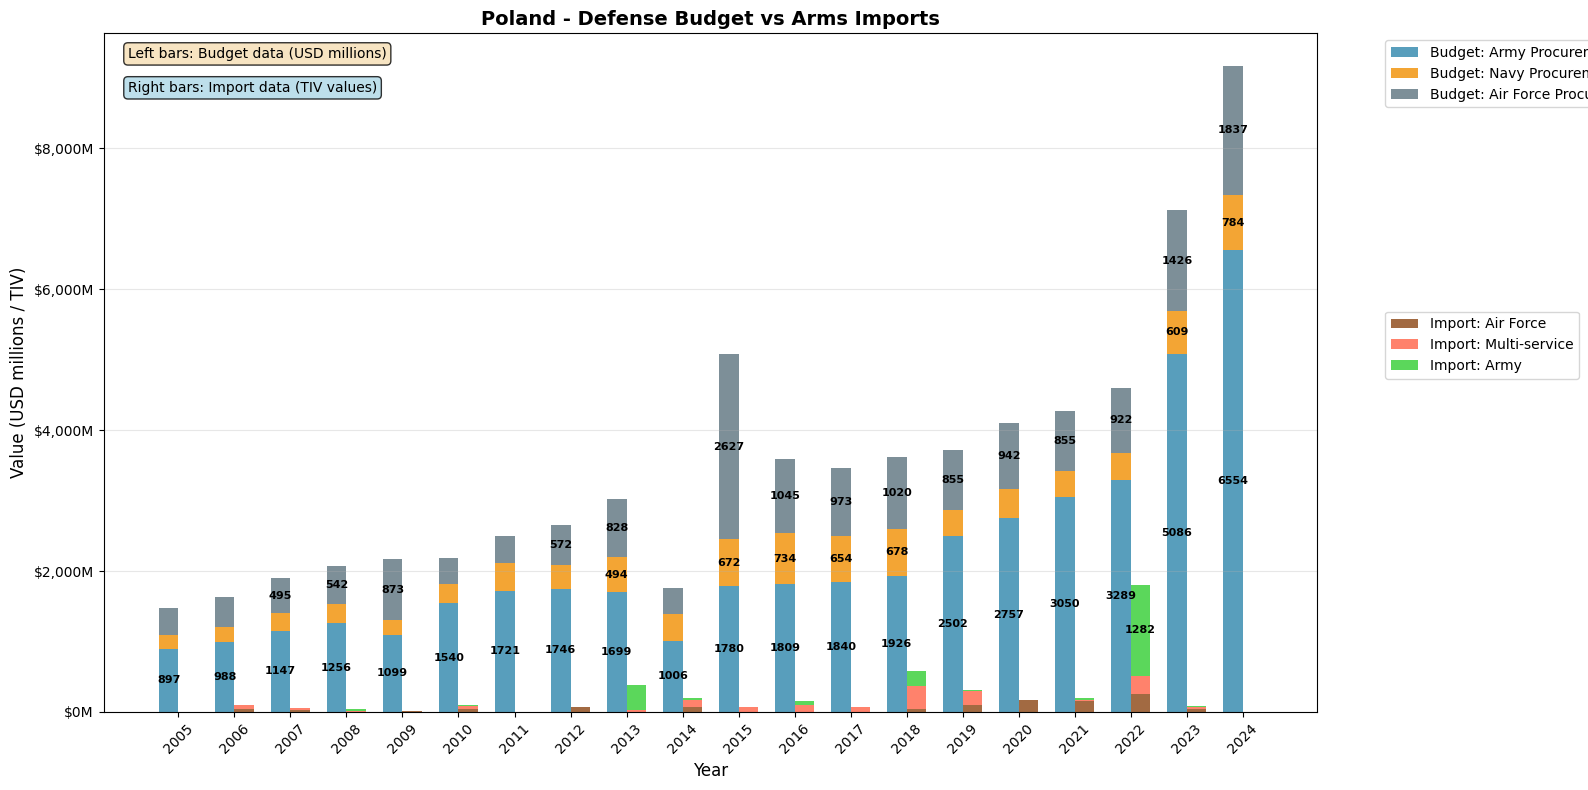

In [68]:
create_defense_budget_chart(budget_trends_df, import_df, 'Poland')

In [66]:
import_df[(import_df['Recipient']=='Netherlands')&(import_df['Order date']==2008)]

,SIPRI AT Database ID,Supplier,Recipient,Designation,Description,Armament category,Order date,Order date is estimate,Numbers delivered,Numbers delivered is estimate,Delivery year,Delivery year is estimate,Status,SIPRI estimate,TIV deal unit,TIV delivery values,Local production,Supplier_region_EU,entity_name
2119,50317,Australia,Netherlands,Bushmaster -,armoured personnel carrier,Armoured vehicles,2008,No,13,No,2008,No,New,0.32,0.32,4.16,No,Asia-Pacific,Army
2204,40298,Germany,Netherlands,Kodiak AEV,armoured engineer vehicle,Armoured vehicles,2008,No,10,No,2018,No,New,2.50,2.50,25.00,No,EU+UK,Army
2205,50128,United States,Netherlands,Paveway,guided bomb,Missiles,2008,No,100,Yes,2010,Yes,New,0.02,0.02,2.00,No,United States,Multi-service
2206,50128,United States,Netherlands,Paveway,guided bomb,Missiles,2008,No,100,Yes,2009,Yes,New,0.02,0.02,2.00,No,United States,Multi-service
2228,55856,United States,Netherlands,vehicle engine 201-300,vehicle engine,Engines,2008,No,13,Yes,2008,No,New,0.03,0.03,0.39,No,United States,Multi-service
2282,31072,United States,Netherlands,F-35A Lightning-2,FGA aircraft,Aircraft,2008,No,4,Yes,2023,No,New,55.00,55.00,220.00,Yes,United States,Air Force
2283,31072,United States,Netherlands,F-35A Lightning-2,FGA aircraft,Aircraft,2008,No,8,No,2019,No,New,55.00,55.00,440.00,Yes,United States,Air Force
2284,31072,United States,Netherlands,F-35A Lightning-2,FGA aircraft,Aircraft,2008,No,11,Yes,2022,No,New,55.00,55.00,605.00,Yes,United States,Air Force
2285,31072,United States,Netherlands,F-35A Lightning-2,FGA aircraft,Aircraft,2008,No,7,No,2021,No,New,55.00,55.00,385.00,Yes,United States,Air Force
2286,31072,United States,Netherlands,F-35A Lightning-2,FGA aircraft,Aircraft,2008,No,5,No,2020,No,New,55.00,55.00,275.00,Yes,United States,Air Force


## UNCOMTRADE DATA

In [41]:
dual_goods_df.columns, military_goods_df.columns

(Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
        'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
        'partnerCode', 'partnerISO', 'partnerDesc', 'partner2Code',
        'partner2ISO', 'partner2Desc', 'classificationCode',
        'classificationSearchCode', 'isOriginalClassification', 'cmdCode',
        'cmdDesc', 'aggrLevel', 'isLeaf', 'customsCode', 'customsDesc',
        'mosCode', 'motCode', 'motDesc', 'qtyUnitCode', 'qtyUnitAbbr', 'qty',
        'isQtyEstimated', 'altQtyUnitCode', 'altQtyUnitAbbr', 'altQty',
        'isAltQtyEstimated', 'netWgt', 'isNetWgtEstimated', 'grossWgt',
        'isGrossWgtEstimated', 'cifvalue', 'fobvalue', 'primaryValue',
        'legacyEstimationFlag', 'isReported', 'isAggregate'],
       dtype='object'),
 Index(['typeCode', 'freqCode', 'refPeriodId', 'refYear', 'refMonth', 'period',
        'reporterCode', 'reporterISO', 'reporterDesc', 'flowCode', 'flowDesc',
        'partnerCode', 'par

In [42]:
military_goods_df.cmdDesc.unique()

array(['Explosives, prepared; other than propellent powders',
       'Fuses and detonators; safety or detonating fuses, percussion or detonating caps, igniters, electric detonators',
       'Pyrotechnic products; signalling flares, rain rockets, fog signals and other pyrotechnic articles (excluding fireworks)',
       'Ground flying trainers and parts thereof; air combat simulators and parts thereof',
       'Revolvers and pistols; other than those of heading no. 9303 or 9304',
       'Firearms; n.e.c. in heading no. 9303',
       'Firearms; (e.g. spring, air or gas guns and pistols, truncheons), excluding those of heading no. 9307',
       'Ammunition; shotgun cartridges',
       'Ammunition; parts of shotgun cartridges',
       'Ammunition; cartridges and parts thereof n.e.c. in heading no. 9306',
       'Ammunition; n.e.c. in chapter 93',
       'Arms; swords, cutlasses, bayonets, lances and the like, parts thereof and scabbards and sheaths therefor',
       'Explosives; propellent 

/tmp/ipykernel_6197/3460017640.py:189: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


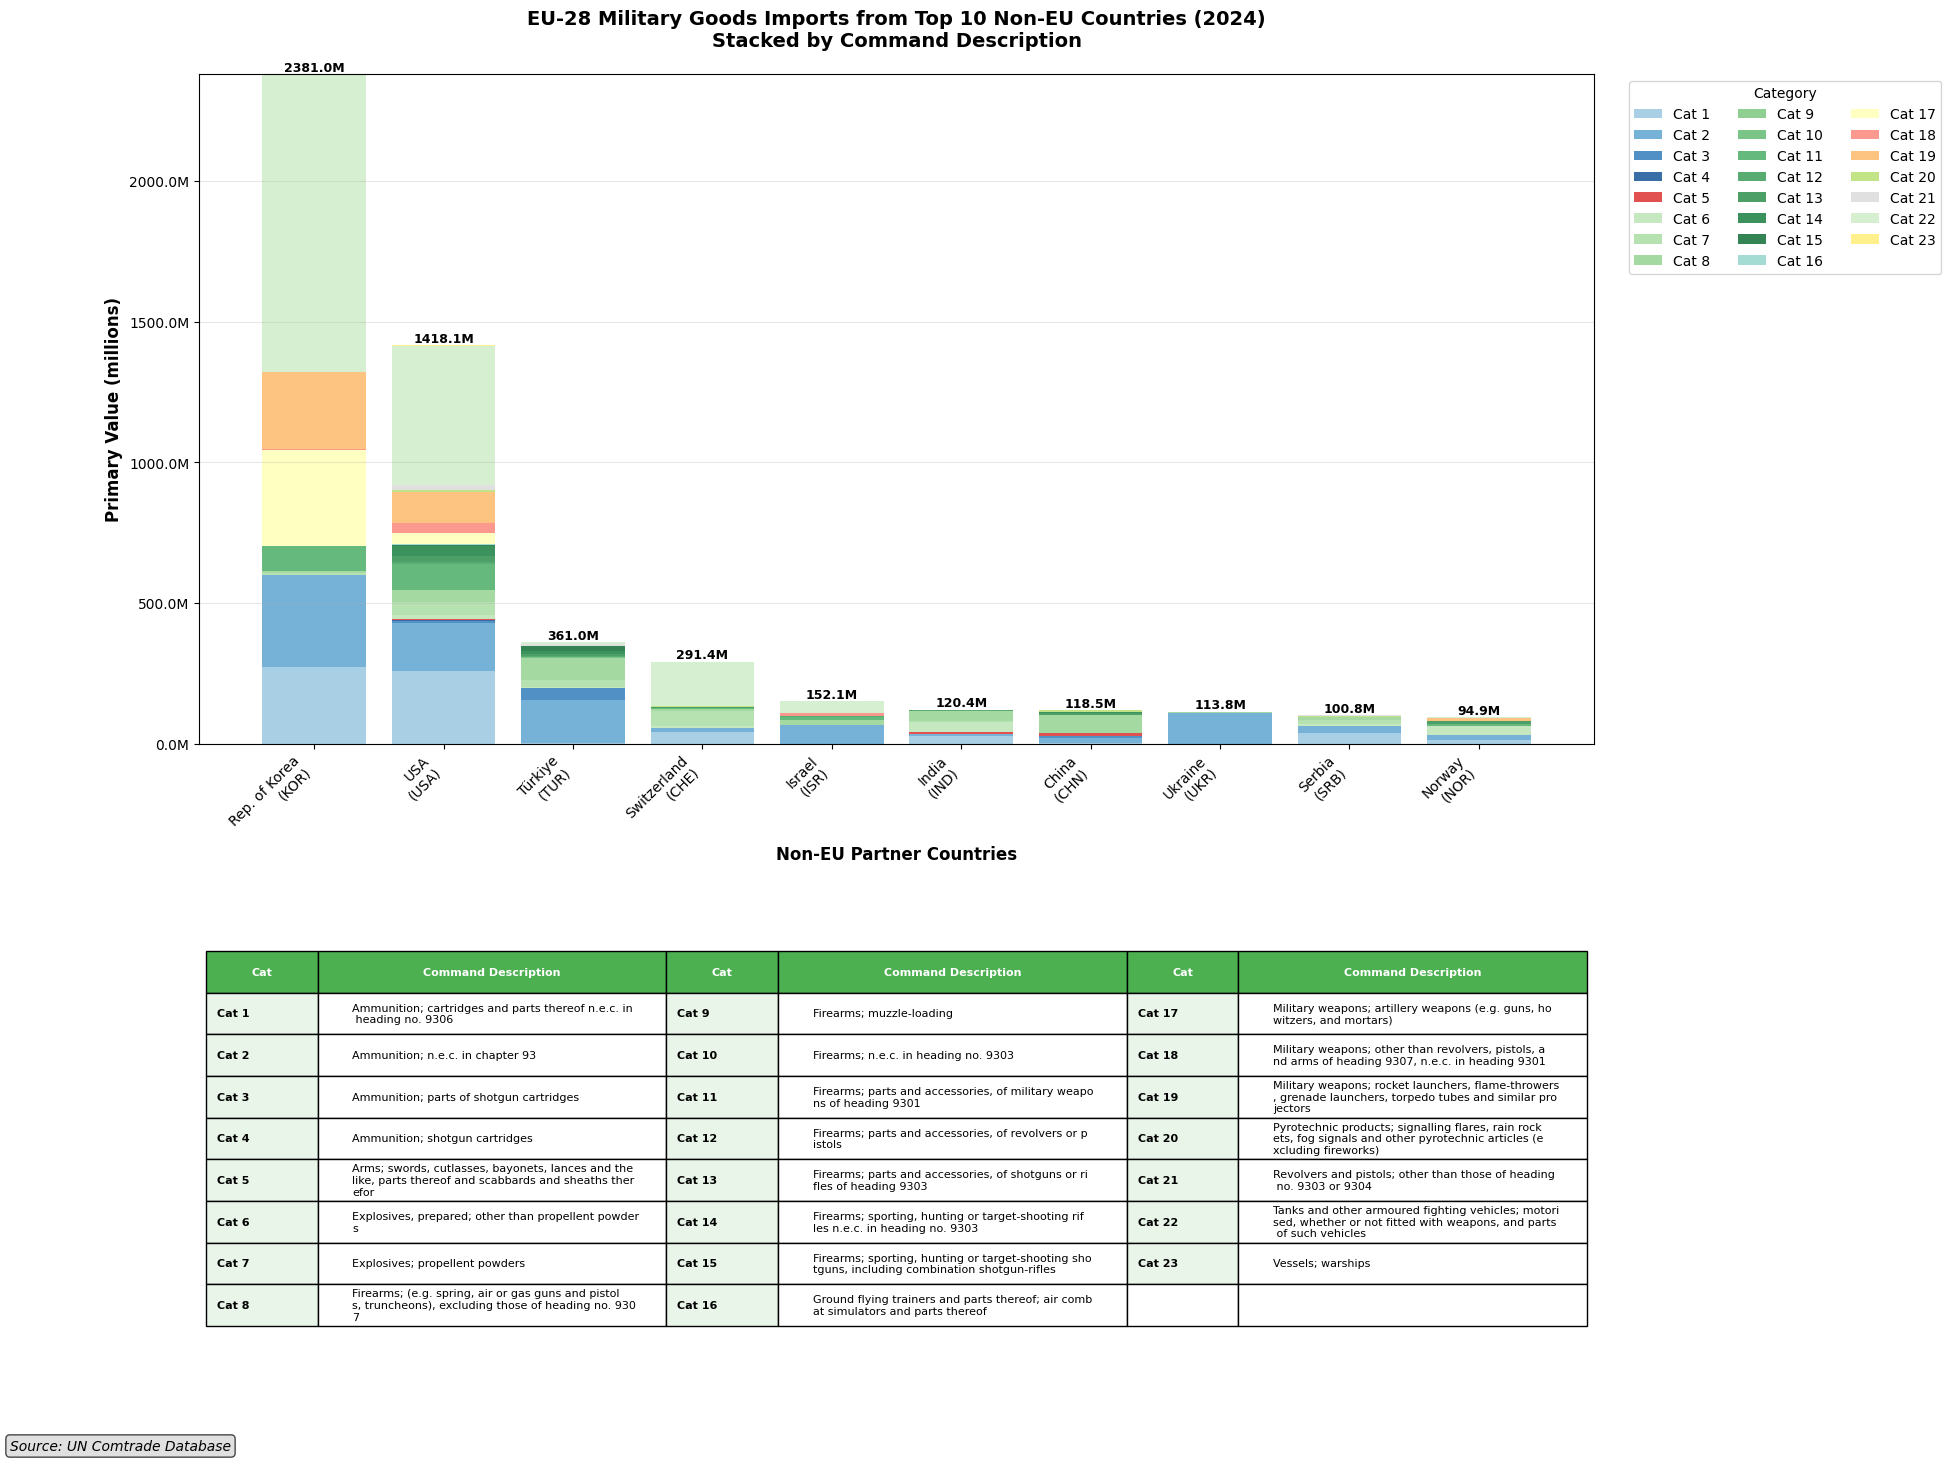

Top 10 Non-EU Countries Exporting Military Goods to EU-28 (2024):
 1. Rep. of Korea (KOR): $2381.01M
 2. USA (USA): $1418.11M
 3. Türkiye (TUR): $360.96M
 4. Switzerland (CHE): $291.42M
 5. Israel (ISR): $152.13M
 6. India (IND): $120.38M
 7. China (CHN): $118.49M
 8. Ukraine (UKR): $113.82M
 9. Serbia (SRB): $100.78M
10. Norway (NOR): $94.89M

Total EU-28 imports from top 10 non-EU countries: $5151.99M

Breakdown for Rep. of Korea (KOR):
----------------------------------------
$1058.43M: Tanks and other armoured fighting vehicles; motorised, whether or not fitted wit...
$340.08M: Military weapons; artillery weapons (e.g. guns, howitzers, and mortars)...
$328.24M: Ammunition; n.e.c. in chapter 93...
$275.87M: Military weapons; rocket launchers, flame-throwers, grenade launchers, torpedo t...
$271.33M: Ammunition; cartridges and parts thereof n.e.c. in heading no. 9306...
$87.90M: Firearms; parts and accessories, of military weapons of heading 9301...
$9.66M: Firearms; (e.g. spring, ai

In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define EU-28 countries (ISO codes)
eu_28_countries = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 
    'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 
    'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 
    'SVN', 'ESP', 'SWE', 'GBR'  # GBR was part of EU-28 until Brexit
]

# Filter data for 2024, imports (flowCode = "M"), and EU-28 reporters
eu_imports_2024 = military_goods_df[
    (military_goods_df['refYear'] == 2024) & 
    (military_goods_df['flowCode'] == 'M') &
    (military_goods_df['reporterISO'].isin(eu_28_countries))
].copy()

# Remove intra-EU trade (imports from other EU countries)
eu_imports_2024 = eu_imports_2024[
    ~eu_imports_2024['partnerISO'].isin(eu_28_countries)
]

# Calculate total imports by partner country (non-EU exporters)
partner_totals = eu_imports_2024.groupby(['partnerISO', 'partnerDesc'])['primaryValue'].sum().reset_index()
partner_totals = partner_totals.sort_values('primaryValue', ascending=False)

# Get top 10 partners
top_10_partners = partner_totals.head(10)['partnerISO'].tolist()

# Filter data for top 10 partners and group by cmdDesc
chart_data = eu_imports_2024[
    eu_imports_2024['partnerISO'].isin(top_10_partners)
].groupby(['partnerISO', 'partnerDesc', 'cmdDesc'])['primaryValue'].sum().reset_index()

# Create pivot table for stacked bar chart
pivot_data = chart_data.pivot_table(
    index=['partnerISO', 'partnerDesc'], 
    columns='cmdDesc', 
    values='primaryValue', 
    fill_value=0
)

# Reorder countries by total value (descending)
country_order = partner_totals.head(10).set_index('partnerISO')['primaryValue'].to_dict()
pivot_data['total'] = pivot_data.sum(axis=1)
pivot_data = pivot_data.sort_values('total', ascending=False)
pivot_data = pivot_data.drop('total', axis=1)

# Create shortened labels for legend and mapping
cmd_descriptions = list(pivot_data.columns)
cmd_labels = {}
for i, desc in enumerate(cmd_descriptions):
    # Create short label (e.g., "Cat 1", "Cat 2", etc.)
    cmd_labels[desc] = f"Cat {i+1}"

# Create color scheme with grouped colors for categories 1-4 and 6-15
def create_grouped_colors(n_categories):
    colors = []
    
    # Categories 1-4: Blues (assuming these might be present)
    blue_colors = plt.cm.Blues(np.linspace(0.4, 0.9, 4))
    
    # Category 5: Single distinct color (red)
    single_color = [plt.cm.Reds(0.7)]
    
    # Categories 6-15: Greens (10 colors)
    green_colors = plt.cm.Greens(np.linspace(0.3, 0.9, 10))
    
    # Remaining categories: Various other colors
    remaining_count = max(0, n_categories - 15)
    if remaining_count > 0:
        other_colors = plt.cm.Set3(np.linspace(0, 1, remaining_count))
    else:
        other_colors = []
    
    # Combine all colors
    all_colors = np.vstack([
        blue_colors[:min(4, n_categories)],
        single_color if n_categories > 4 else [],
        green_colors[:min(10, max(0, n_categories - 5))],
        other_colors if remaining_count > 0 else []
    ])
    
    return all_colors[:n_categories]

# Generate grouped colors
colors = create_grouped_colors(len(cmd_descriptions))

# Create the figure with subplots for chart and legend (made longer for 23 categories)
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 0.1, 1.5], hspace=0.3)

# Main chart
ax_main = fig.add_subplot(gs[0])

# Create stacked bars
bottom = np.zeros(len(pivot_data))

bars = []
for i, cmd_desc in enumerate(pivot_data.columns):
    values = pivot_data[cmd_desc].values
    color = colors[i] if i < len(colors) else plt.cm.Set3(i / len(pivot_data.columns))
    bar = ax_main.bar(range(len(pivot_data)), values, bottom=bottom, 
                     label=cmd_labels[cmd_desc], color=color, alpha=0.8)
    bars.append(bar)
    bottom += values

# Customize the main chart
ax_main.set_xlabel('Non-EU Partner Countries', fontsize=12, fontweight='bold')
ax_main.set_ylabel('Primary Value (millions)', fontsize=12, fontweight='bold')
ax_main.set_title('EU-28 Military Goods Imports from Top 10 Non-EU Countries (2024)\nStacked by Command Description', 
                 fontsize=14, fontweight='bold', pad=20)

# Add source annotation
fig.text(0.02, 0.02, 'Source: UN Comtrade Database', fontsize=10, style='italic', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Set x-axis labels
country_labels = [f"{row[1]}\n({row[0]})" for row in pivot_data.index]
ax_main.set_xticks(range(len(pivot_data)))
ax_main.set_xticklabels(country_labels, rotation=45, ha='right')

# Format y-axis to show values in millions
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add legend with short labels (split into multiple columns for better fit)
n_cols = 3 if len(cmd_descriptions) > 15 else 2
ax_main.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', ncol=n_cols)

# Add grid for better readability
ax_main.grid(True, alpha=0.3, axis='y')

# Display total values on top of bars
for i, (idx, row) in enumerate(pivot_data.iterrows()):
    total = row.sum()
    ax_main.text(i, total, f'{total/1e6:.1f}M', ha='center', va='bottom', 
                fontweight='bold', fontsize=9)

# Create legend table below the chart
ax_legend = fig.add_subplot(gs[2])
ax_legend.axis('off')

# Create table data for command descriptions (split into multiple columns for better layout)
table_data = []
n_rows = (len(cmd_descriptions) + 2) // 3  # 3 columns

for row in range(n_rows):
    row_data = []
    for col in range(3):
        idx = row + col * n_rows
        if idx < len(cmd_descriptions):
            desc = cmd_descriptions[idx]
            short_label = cmd_labels[desc]
            # Wrap long descriptions (shorter length due to 3 columns)
            wrapped_desc = '\n'.join([desc[j:j+50] for j in range(0, len(desc), 50)])
            row_data.extend([short_label, wrapped_desc])
        else:
            row_data.extend(['', ''])
    table_data.append(row_data)

# Create table with 6 columns (3 sets of Category + Description)
col_labels = ['Cat', 'Command Description', 'Cat', 'Command Description', 'Cat', 'Command Description']
table = ax_legend.table(cellText=table_data,
                       colLabels=col_labels,
                       cellLoc='left',
                       loc='center',
                       colWidths=[0.08, 0.25, 0.08, 0.25, 0.08, 0.25])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.5)

# Style header
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style category columns (0, 2, 4)
for row in range(1, len(table_data) + 1):
    for col in [0, 2, 4]:
        if table_data[row-1][col]:  # Only if there's content
            table[(row, col)].set_facecolor('#E8F5E8')
            table[(row, col)].set_text_props(weight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Top 10 Non-EU Countries Exporting Military Goods to EU-28 (2024):")
print("="*60)
for i, (partner_iso, partner_desc) in enumerate(pivot_data.index):
    total_value = pivot_data.loc[(partner_iso, partner_desc)].sum()
    print(f"{i+1:2d}. {partner_desc} ({partner_iso}): ${total_value/1e6:.2f}M")

print(f"\nTotal EU-28 imports from top 10 non-EU countries: ${pivot_data.values.sum()/1e6:.2f}M")

# Show breakdown by command description for top country
top_country = pivot_data.index[0]
print(f"\nBreakdown for {top_country[1]} ({top_country[0]}):")
print("-" * 40)
top_country_data = chart_data[
    (chart_data['partnerISO'] == top_country[0])
].sort_values('primaryValue', ascending=False)

for _, row in top_country_data.iterrows():
    print(f"${row['primaryValue']/1e6:.2f}M: {row['cmdDesc'][:80]}...")

# Print category mapping for reference
print(f"\nCategory Mapping:")
print("="*50)
for i, (desc, label) in enumerate(cmd_labels.items()):
    color_group = "Categories 1-4 (Blues)" if i < 4 else "Category 5 (Red)" if i == 4 else "Categories 6-15 (Greens)" if i < 15 else "Other Categories"
    print(f"{label} ({color_group}): {desc[:80]}{'...' if len(desc) > 80 else ''}")

In [44]:
military_goods_df.cmdDesc.unique()

array(['Explosives, prepared; other than propellent powders',
       'Fuses and detonators; safety or detonating fuses, percussion or detonating caps, igniters, electric detonators',
       'Pyrotechnic products; signalling flares, rain rockets, fog signals and other pyrotechnic articles (excluding fireworks)',
       'Ground flying trainers and parts thereof; air combat simulators and parts thereof',
       'Revolvers and pistols; other than those of heading no. 9303 or 9304',
       'Firearms; n.e.c. in heading no. 9303',
       'Firearms; (e.g. spring, air or gas guns and pistols, truncheons), excluding those of heading no. 9307',
       'Ammunition; shotgun cartridges',
       'Ammunition; parts of shotgun cartridges',
       'Ammunition; cartridges and parts thereof n.e.c. in heading no. 9306',
       'Ammunition; n.e.c. in chapter 93',
       'Arms; swords, cutlasses, bayonets, lances and the like, parts thereof and scabbards and sheaths therefor',
       'Explosives; propellent 

In [45]:
dual_goods_df

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
0,C,A,20240101,2024,52,2024,8,ALB,Albania,M,...,23.584,False,0.0,False,3527.181,NaN,3527.181,0,False,True
1,C,A,20240101,2024,52,2024,8,ALB,Albania,M,...,400.310,False,0.0,False,12685.174,NaN,12685.174,0,False,True
2,C,A,20240101,2024,52,2024,8,ALB,Albania,M,...,75.079,False,0.0,False,6646.841,NaN,6646.841,0,False,True
3,C,A,20240101,2024,52,2024,8,ALB,Albania,M,...,71.437,False,0.0,False,17041.173,NaN,17041.173,0,False,True
4,C,A,20240101,2024,52,2024,8,ALB,Albania,M,...,135.347,False,0.0,False,26652.956,NaN,26652.956,0,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206915,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,X,...,8.000,False,0.0,False,NaN,441.950,441.950,0,True,False
206916,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,M,...,114.000,False,0.0,False,13276.942,NaN,13276.942,0,True,False
206917,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,X,...,2003.000,False,0.0,False,NaN,40285.803,40285.803,0,True,False
206918,C,A,20240101,2024,52,2024,716,ZWE,Zimbabwe,M,...,4500.000,False,0.0,False,38160.000,NaN,38160.000,0,True,False


In [46]:
dual_goods_df[
    (dual_goods_df['refYear'] == 2024) & 
    (dual_goods_df['flowCode'] == 'M') &
    (dual_goods_df['reporterISO'].isin(eu_28_countries))
]

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
5496,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,4.000,False,0.0,False,67.108,NaN,67.108,0,True,False
5497,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,1.465,True,0.0,False,27.060,NaN,27.060,4,True,False
5498,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,0.304,True,0.0,False,15.153,NaN,15.153,4,True,False
5500,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,110.000,False,0.0,False,1407.095,NaN,1407.095,0,True,False
5501,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,2.000,False,0.0,False,154.780,NaN,154.780,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199291,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,19042.000,False,0.0,False,3127591.019,NaN,3127591.019,0,False,True
199299,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,5.000,False,0.0,False,14425.644,NaN,14425.644,0,False,True
199309,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,69.289,True,0.0,False,2236.013,NaN,2236.013,6,False,True
199326,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,7.000,False,0.0,False,6013.010,NaN,6013.010,0,False,True


In [47]:
dual_goods_df[dual_goods_df['reporterISO'].isin(eu_28_countries)&(dual_goods_df['flowCode'] == 'M')&(dual_goods_df['refYear'] == 2024)]

,typeCode,freqCode,refPeriodId,refYear,refMonth,period,reporterCode,reporterISO,reporterDesc,flowCode,...,netWgt,isNetWgtEstimated,grossWgt,isGrossWgtEstimated,cifvalue,fobvalue,primaryValue,legacyEstimationFlag,isReported,isAggregate
5496,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,4.000,False,0.0,False,67.108,NaN,67.108,0,True,False
5497,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,1.465,True,0.0,False,27.060,NaN,27.060,4,True,False
5498,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,0.304,True,0.0,False,15.153,NaN,15.153,4,True,False
5500,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,110.000,False,0.0,False,1407.095,NaN,1407.095,0,True,False
5501,C,A,20240101,2024,52,2024,40,AUT,Austria,M,...,2.000,False,0.0,False,154.780,NaN,154.780,0,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199291,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,19042.000,False,0.0,False,3127591.019,NaN,3127591.019,0,False,True
199299,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,5.000,False,0.0,False,14425.644,NaN,14425.644,0,False,True
199309,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,69.289,True,0.0,False,2236.013,NaN,2236.013,6,False,True
199326,C,A,20240101,2024,52,2024,826,GBR,United Kingdom,M,...,7.000,False,0.0,False,6013.010,NaN,6013.010,0,False,True


/tmp/ipykernel_6197/3679708597.py:182: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


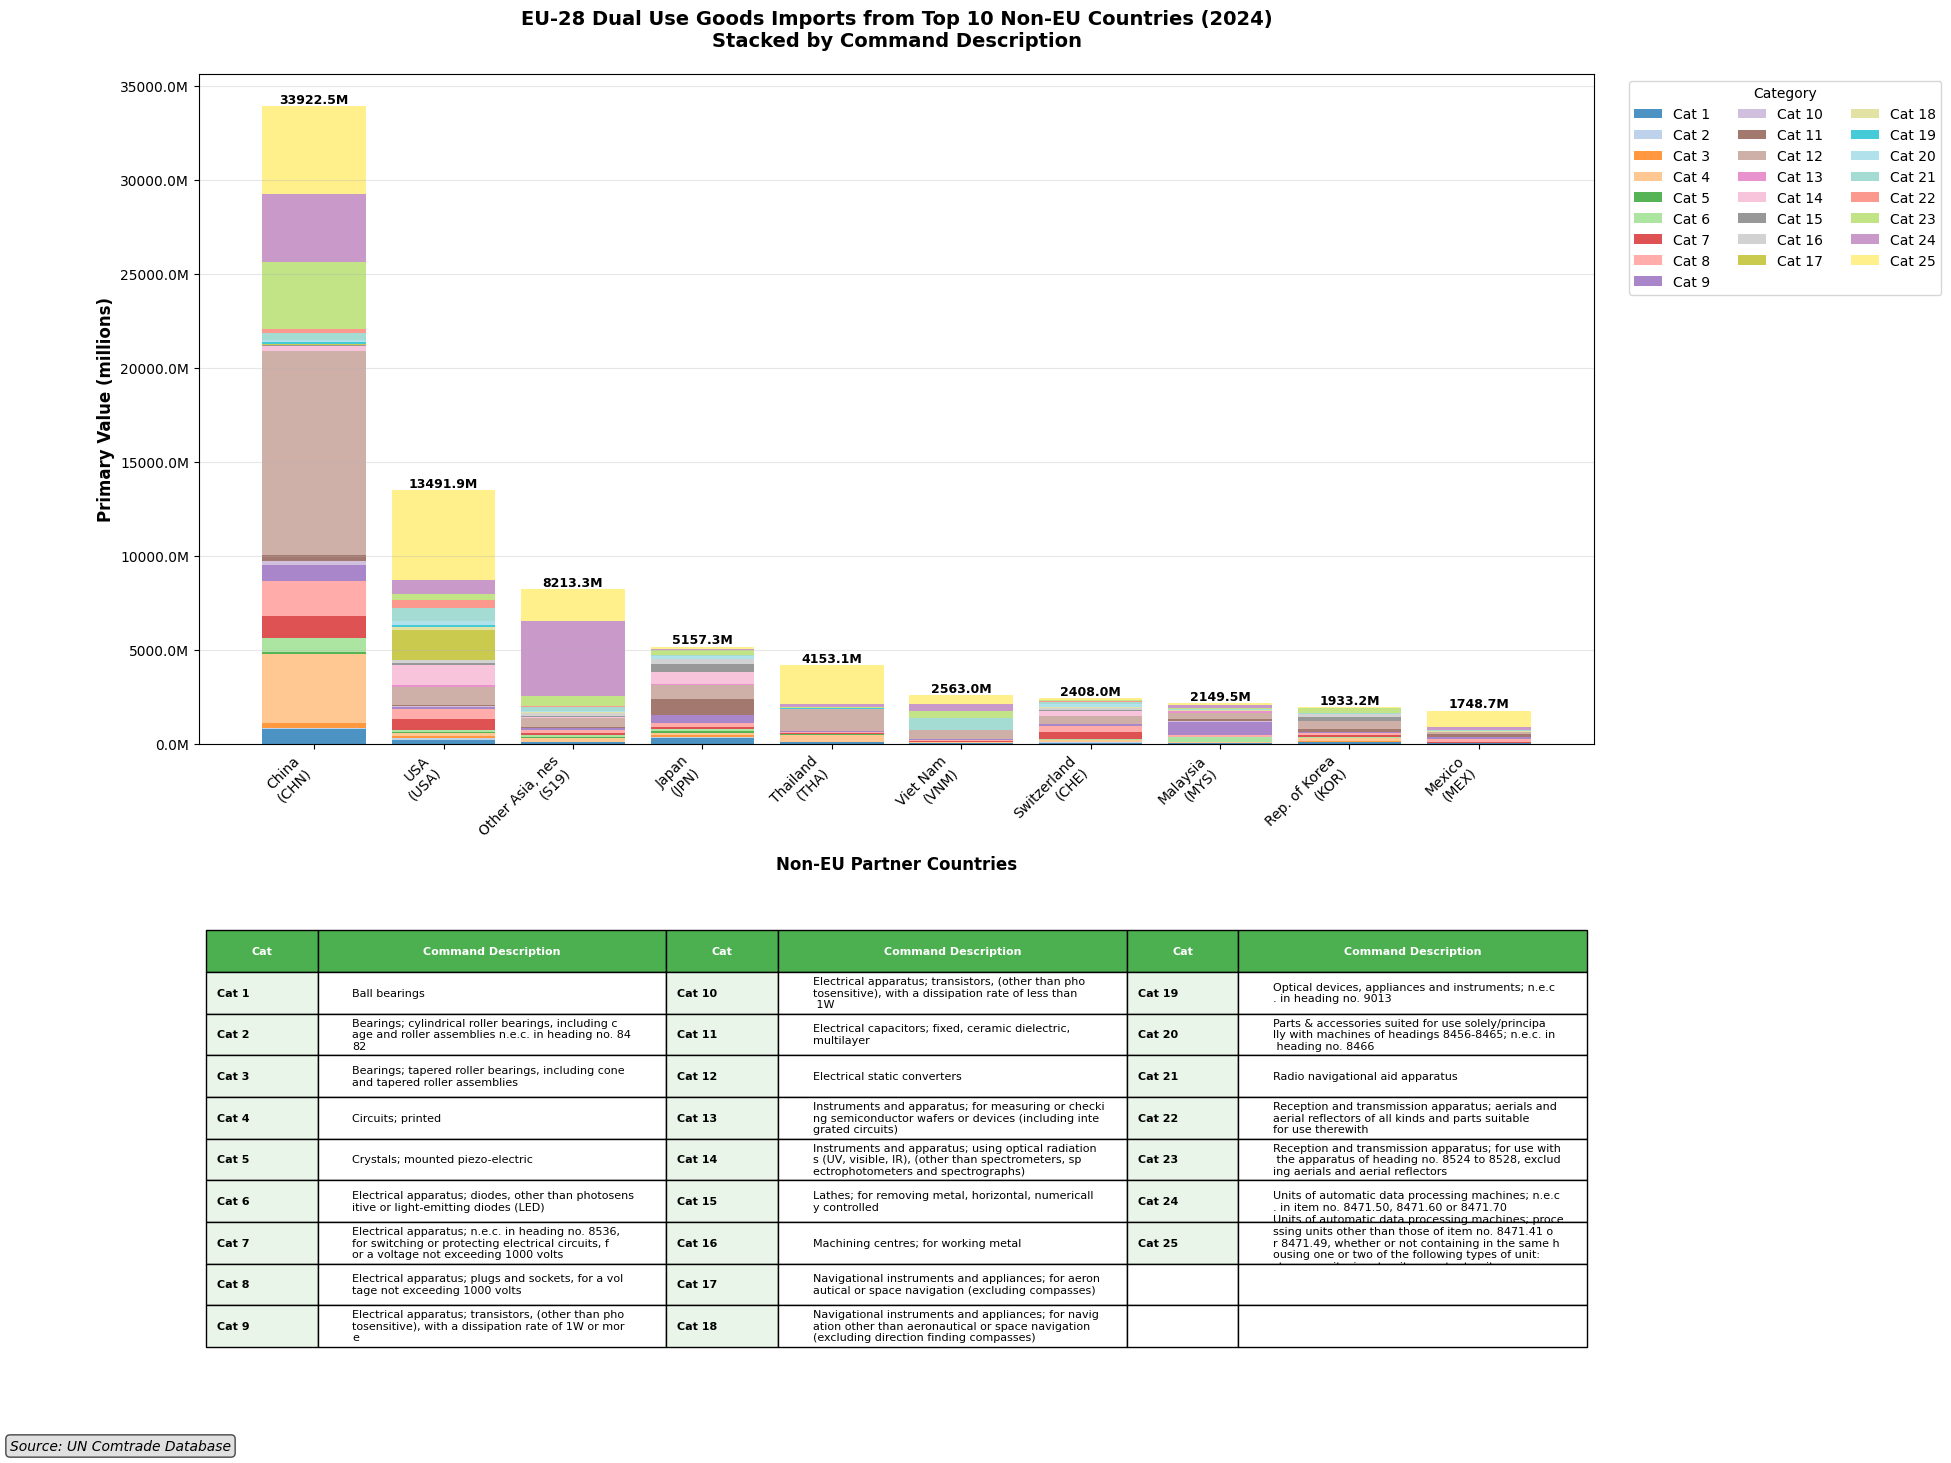

Top 10 Non-EU Countries Exporting Dual Use Goods to EU-28 (2024):
 1. China (CHN): $33922.52M
 2. USA (USA): $13491.95M
 3. Other Asia, nes (S19): $8213.28M
 4. Japan (JPN): $5157.30M
 5. Thailand (THA): $4153.10M
 6. Viet Nam (VNM): $2563.03M
 7. Switzerland (CHE): $2407.97M
 8. Malaysia (MYS): $2149.53M
 9. Rep. of Korea (KOR): $1933.19M
10. Mexico (MEX): $1748.68M

Total EU-28 dual use imports from top 10 non-EU countries: $75740.54M

Breakdown for China (CHN):
----------------------------------------
$10836.46M: Electrical static converters...
$4693.00M: Units of automatic data processing machines; processing units other than those o...
$3675.39M: Circuits; printed...
$3595.32M: Units of automatic data processing machines; n.e.c. in item no. 8471.50, 8471.60...
$3563.93M: Reception and transmission apparatus; for use with the apparatus of heading no. ...
$1850.52M: Electrical apparatus; plugs and sockets, for a voltage not exceeding 1000 volts...
$1166.14M: Electrical apparatus; n.

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define EU-28 countries (ISO codes)
eu_28_countries = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 
    'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 
    'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 
    'SVN', 'ESP', 'SWE', 'GBR'  # GBR was part of EU-28 until Brexit
]

# Filter data for 2024, imports (flowCode = "M"), and EU-28 reporters
eu_imports_2024 = dual_goods_df[
    (dual_goods_df['refYear'] == 2024) & 
    (dual_goods_df['flowCode'] == 'M') &
    (dual_goods_df['reporterISO'].isin(eu_28_countries))
].copy()

# Remove intra-EU trade (imports from other EU countries)
eu_imports_2024 = eu_imports_2024[
    ~eu_imports_2024['partnerISO'].isin(eu_28_countries)
]

# Calculate total imports by partner country (non-EU exporters)
partner_totals = eu_imports_2024.groupby(['partnerISO', 'partnerDesc'])['primaryValue'].sum().reset_index()
partner_totals = partner_totals.sort_values('primaryValue', ascending=False)

# Get top 10 partners
top_10_partners = partner_totals.head(10)['partnerISO'].tolist()

# Filter data for top 10 partners and group by cmdDesc
chart_data = eu_imports_2024[
    eu_imports_2024['partnerISO'].isin(top_10_partners)
].groupby(['partnerISO', 'partnerDesc', 'cmdDesc'])['primaryValue'].sum().reset_index()

# Get top 25 command descriptions by total value across all countries
cmd_totals = chart_data.groupby('cmdDesc')['primaryValue'].sum().reset_index()
cmd_totals = cmd_totals.sort_values('primaryValue', ascending=False)
top_25_cmds = cmd_totals.head(25)['cmdDesc'].tolist()

# Filter chart_data to only include top 25 command descriptions
chart_data = chart_data[chart_data['cmdDesc'].isin(top_25_cmds)]

# Create pivot table for stacked bar chart
pivot_data = chart_data.pivot_table(
    index=['partnerISO', 'partnerDesc'], 
    columns='cmdDesc', 
    values='primaryValue', 
    fill_value=0
)

# Reorder countries by total value (descending)
country_order = partner_totals.head(10).set_index('partnerISO')['primaryValue'].to_dict()
pivot_data['total'] = pivot_data.sum(axis=1)
pivot_data = pivot_data.sort_values('total', ascending=False)
pivot_data = pivot_data.drop('total', axis=1)

# Create shortened labels for legend and mapping
cmd_descriptions = list(pivot_data.columns)
cmd_labels = {}
for i, desc in enumerate(cmd_descriptions):
    # Create short label (e.g., "Cat 1", "Cat 2", etc.)
    cmd_labels[desc] = f"Cat {i+1}"

# Create color scheme with distinct colors for all categories
def create_colors(n_categories):
    # Use a combination of color maps to get distinct colors
    if n_categories <= 10:
        colors = plt.cm.tab10(np.linspace(0, 1, n_categories))
    elif n_categories <= 20:
        colors = plt.cm.tab20(np.linspace(0, 1, n_categories))
    else:
        # For more than 20 categories, combine different color maps
        colors1 = plt.cm.tab20(np.linspace(0, 1, 20))
        colors2 = plt.cm.Set3(np.linspace(0, 1, n_categories - 20))
        colors = np.vstack([colors1, colors2])
    
    return colors

# Generate colors
colors = create_colors(len(cmd_descriptions))

# Create the figure with subplots for chart and legend (made longer for multiple categories)
fig = plt.figure(figsize=(18, 16))
gs = fig.add_gridspec(3, 1, height_ratios=[3, 0.1, 1.5], hspace=0.3)

# Main chart
ax_main = fig.add_subplot(gs[0])

# Create stacked bars
bottom = np.zeros(len(pivot_data))

bars = []
for i, cmd_desc in enumerate(pivot_data.columns):
    values = pivot_data[cmd_desc].values
    color = colors[i] if i < len(colors) else plt.cm.Set3(i / len(pivot_data.columns))
    bar = ax_main.bar(range(len(pivot_data)), values, bottom=bottom, 
                     label=cmd_labels[cmd_desc], color=color, alpha=0.8)
    bars.append(bar)
    bottom += values

# Customize the main chart
ax_main.set_xlabel('Non-EU Partner Countries', fontsize=12, fontweight='bold')
ax_main.set_ylabel('Primary Value (millions)', fontsize=12, fontweight='bold')
ax_main.set_title('EU-28 Dual Use Goods Imports from Top 10 Non-EU Countries (2024)\nStacked by Command Description', 
                 fontsize=14, fontweight='bold', pad=20)

# Add source annotation
fig.text(0.02, 0.02, 'Source: UN Comtrade Database', fontsize=10, style='italic', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Set x-axis labels
country_labels = [f"{row[1]}\n({row[0]})" for row in pivot_data.index]
ax_main.set_xticks(range(len(pivot_data)))
ax_main.set_xticklabels(country_labels, rotation=45, ha='right')

# Format y-axis to show values in millions
ax_main.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add legend with short labels (split into multiple columns for better fit)
n_cols = 3 if len(cmd_descriptions) > 15 else 2
ax_main.legend(title='Category', bbox_to_anchor=(1.02, 1), loc='upper left', ncol=n_cols)

# Add grid for better readability
ax_main.grid(True, alpha=0.3, axis='y')

# Display total values on top of bars
for i, (idx, row) in enumerate(pivot_data.iterrows()):
    total = row.sum()
    ax_main.text(i, total, f'{total/1e6:.1f}M', ha='center', va='bottom', 
                fontweight='bold', fontsize=9)

# Create legend table below the chart
ax_legend = fig.add_subplot(gs[2])
ax_legend.axis('off')

# Create table data for command descriptions (split into multiple columns for better layout)
table_data = []
n_rows = (len(cmd_descriptions) + 2) // 3  # 3 columns

for row in range(n_rows):
    row_data = []
    for col in range(3):
        idx = row + col * n_rows
        if idx < len(cmd_descriptions):
            desc = cmd_descriptions[idx]
            short_label = cmd_labels[desc]
            # Wrap long descriptions (shorter length due to 3 columns)
            wrapped_desc = '\n'.join([desc[j:j+50] for j in range(0, len(desc), 50)])
            row_data.extend([short_label, wrapped_desc])
        else:
            row_data.extend(['', ''])
    table_data.append(row_data)

# Create table with 6 columns (3 sets of Category + Description)
col_labels = ['Cat', 'Command Description', 'Cat', 'Command Description', 'Cat', 'Command Description']
table = ax_legend.table(cellText=table_data,
                       colLabels=col_labels,
                       cellLoc='left',
                       loc='center',
                       colWidths=[0.08, 0.25, 0.08, 0.25, 0.08, 0.25])

# Style the table
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 2.5)

# Style header
for i in range(6):
    table[(0, i)].set_facecolor('#4CAF50')
    table[(0, i)].set_text_props(weight='bold', color='white')

# Style category columns (0, 2, 4)
for row in range(1, len(table_data) + 1):
    for col in [0, 2, 4]:
        if table_data[row-1][col]:  # Only if there's content
            table[(row, col)].set_facecolor('#E8F5E8')
            table[(row, col)].set_text_props(weight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("Top 10 Non-EU Countries Exporting Dual Use Goods to EU-28 (2024):")
print("="*60)
for i, (partner_iso, partner_desc) in enumerate(pivot_data.index):
    total_value = pivot_data.loc[(partner_iso, partner_desc)].sum()
    print(f"{i+1:2d}. {partner_desc} ({partner_iso}): ${total_value/1e6:.2f}M")

print(f"\nTotal EU-28 dual use imports from top 10 non-EU countries: ${pivot_data.values.sum()/1e6:.2f}M")

# Show breakdown by command description for top country
top_country = pivot_data.index[0]
print(f"\nBreakdown for {top_country[1]} ({top_country[0]}):")
print("-" * 40)
top_country_data = chart_data[
    (chart_data['partnerISO'] == top_country[0])
].sort_values('primaryValue', ascending=False)

for _, row in top_country_data.iterrows():
    print(f"${row['primaryValue']/1e6:.2f}M: {row['cmdDesc'][:80]}...")

# Print category mapping for reference
print(f"\nCategory Mapping:")
print("="*50)
for i, (desc, label) in enumerate(cmd_labels.items()):
    print(f"{label}: {desc[:80]}{'...' if len(desc) > 80 else ''}")

In [49]:
dual_goods_df.cmdDesc.unique()

array(['Units of automatic data processing machines; processing units other than those of item no. 8471.41 or 8471.49, whether or not containing in the same housing one or two of the following types of unit: storage units, input units or output units',
       'Ball bearings',
       'Bearings; tapered roller bearings, including cone and tapered roller assemblies',
       'Electrical static converters', 'Circuits; printed',
       'Electrical apparatus; plugs and sockets, for a voltage not exceeding 1000 volts',
       'Electrical apparatus; n.e.c. in heading no. 8536, for switching or protecting electrical circuits, for a voltage not exceeding 1000 volts',
       'Machine-tools; for milling by removing metal, (not knee-type), numerically controlled',
       'Parts & accessories suited for use solely/principally with machines of headings 8456-8465; n.e.c. in heading no. 8466',
       'Units of automatic data processing machines; n.e.c. in item no. 8471.50, 8471.60 or 8471.70',
       'B

In [50]:
military_classification = {
    # LAND DOMAIN
    'Firearms; parts and accessories, of firearms other than the military weapons of heading 9301': 'land',
    
    # NAVAL DOMAIN
    'Vessels; other, including lifeboats other than rowing boats, other than warships': 'naval',
    'Navigational instruments and appliances; for navigation other than aeronautical or space navigation (excluding direction finding compasses)': 'naval',
    
    # AIR DOMAIN
    'Ground flying trainers and parts thereof; other than air combat simulators and parts thereof': 'air',
    'Navigational instruments and appliances; for aeronautical or space navigation (excluding compasses)': 'air',
    
    # ALL DOMAINS
    'Machining centres; for working metal': 'all domains',
    'Lathes; for removing metal, horizontal, numerically controlled': 'all domains',
    'Lathes; for removing metal, numerically controlled, other than horizontal lathes': 'all domains',
    'Machine-tools; for milling by removing metal, (not knee-type), numerically controlled': 'all domains',
    'Parts & accessories suited for use solely/principally with machines of headings 8456-8465; n.e.c. in heading no. 8466': 'all domains',
    'Units of automatic data processing machines; processing units other than those of item no. 8471.41 or 8471.49, whether or not containing in the same housing one or two of the following types of unit: storage units, input units or output units': 'all domains',
    'Units of automatic data processing machines; n.e.c. in item no. 8471.50, 8471.60 or 8471.70': 'all domains',
    'Ball bearings': 'all domains',
    'Bearings; tapered roller bearings, including cone and tapered roller assemblies': 'all domains',
    'Bearings; spherical roller bearings': 'all domains',
    'Bearings; cylindrical roller bearings, including cage and roller assemblies n.e.c. in heading no. 8482': 'all domains',
    'Electrical static converters': 'all domains',
    'Radio navigational aid apparatus': 'all domains',
    'Reception and transmission apparatus; aerials and aerial reflectors of all kinds and parts suitable for use therewith': 'all domains',
    'Reception and transmission apparatus; for use with the apparatus of heading no. 8524 to 8528, excluding aerials and aerial reflectors': 'all domains',
    'Electrical capacitors; fixed, tantalum': 'all domains',
    'Electrical capacitors; fixed, ceramic dielectric, multilayer': 'all domains',
    'Circuits; printed': 'all domains',
    'Electrical apparatus; plugs and sockets, for a voltage not exceeding 1000 volts': 'all domains',
    'Electrical apparatus; n.e.c. in heading no. 8536, for switching or protecting electrical circuits, for a voltage not exceeding 1000 volts': 'all domains',
    'Electrical apparatus; diodes, other than photosensitive or light-emitting diodes (LED)': 'all domains',
    'Electrical apparatus; transistors, (other than photosensitive), with a dissipation rate of less than 1W': 'all domains',
    'Electrical apparatus; transistors, (other than photosensitive), with a dissipation rate of 1W or more': 'all domains',
    'Electrical apparatus; thyristors, diacs and triacs, other than photosensitive devices': 'all domains',
    'Crystals; mounted piezo-electric': 'all domains',
    'Electrical machines and apparatus; signal generators': 'all domains',
    'Optical appliances and instruments; telescopic sights for fitting to arms; periscopes; telescopes designed to form parts of machines, appliances, instruments or apparatus of this chapter': 'all domains',
    'Optical devices, appliances and instruments; n.e.c. in heading no. 9013': 'all domains',
    'Instruments and apparatus; using optical radiations (UV, visible, IR), (other than spectrometers, spectrophotometers and spectrographs)': 'all domains',
    'Oscilloscopes and oscillographs': 'all domains',
    'Multimeters; for measuring or checking voltage, current, resistance or power, with a recording device': 'all domains',
    'Instruments and apparatus; for measuring or checking voltage, current, resistance or power, with a recording device (excluding multimeters)': 'all domains',
    'Instruments and apparatus; for measuring or checking semiconductor wafers or devices (including integrated circuits)': 'all domains'
}


In [51]:
dual_goods_df['Domain'] = dual_goods_df['cmdDesc'].map(military_classification)

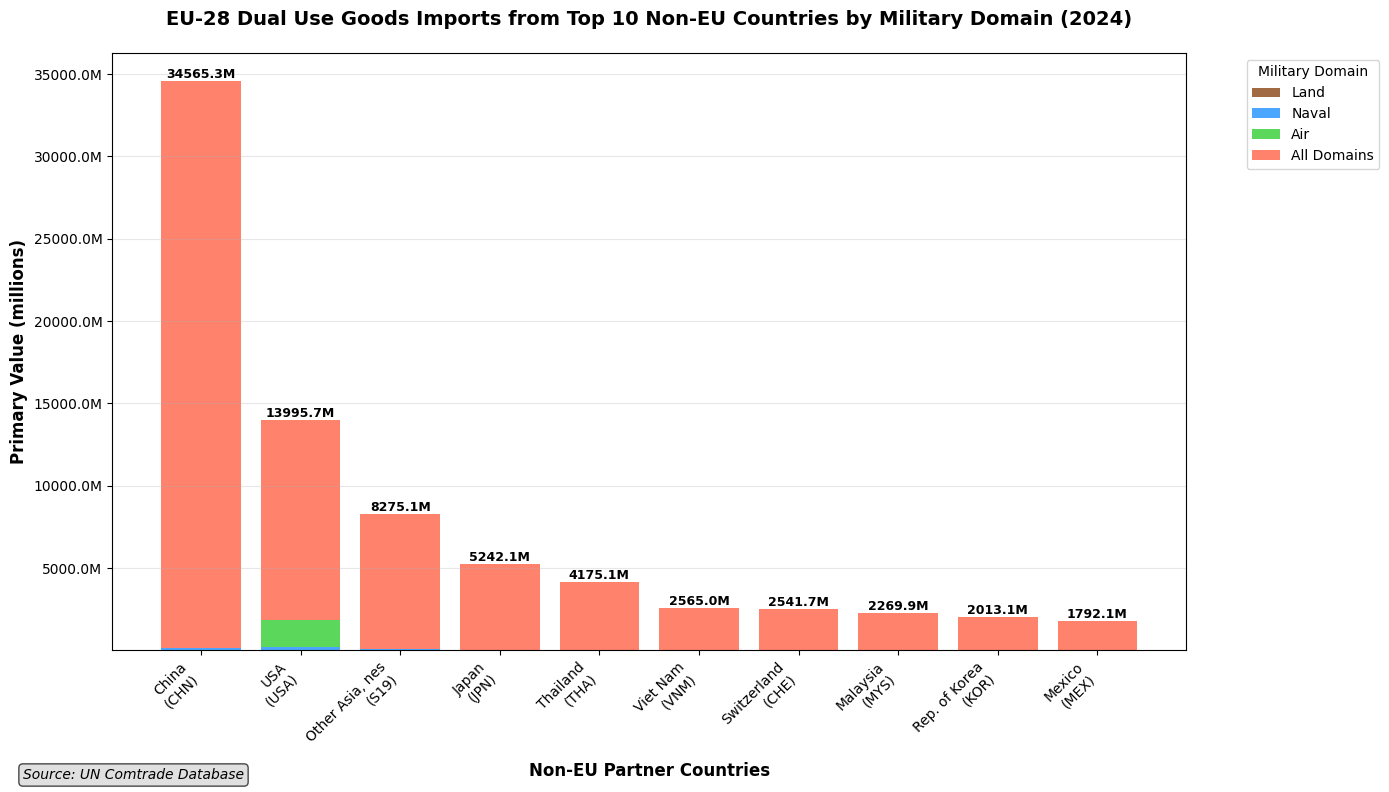

Top 10 Non-EU Countries Exporting Dual Use Goods to EU-28 by Military Domain (2024):
 1. China (CHN): $34565.33M
 2. USA (USA): $13995.68M
 3. Other Asia, nes (S19): $8275.08M
 4. Japan (JPN): $5242.12M
 5. Thailand (THA): $4175.14M
 6. Viet Nam (VNM): $2565.00M
 7. Switzerland (CHE): $2541.68M
 8. Malaysia (MYS): $2269.95M
 9. Rep. of Korea (KOR): $2013.15M
10. Mexico (MEX): $1792.06M

Total EU-28 dual use imports from top 10 non-EU countries: $77435.19M

Domain breakdown for China (CHN):
--------------------------------------------------
$34398.45M: All Domains
$134.27M: Naval
$18.01M: Air
$14.60M: Land

Total imports by military domain:
All Domains: $75208.53M
Air: $1707.42M
Naval: $464.79M
Land: $54.44M


In [52]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Define EU-28 countries (ISO codes)
eu_28_countries = [
    'AUT', 'BEL', 'BGR', 'HRV', 'CYP', 'CZE', 'DNK', 'EST', 
    'FIN', 'FRA', 'DEU', 'GRC', 'HUN', 'IRL', 'ITA', 'LVA', 
    'LTU', 'LUX', 'MLT', 'NLD', 'POL', 'PRT', 'ROU', 'SVK', 
    'SVN', 'ESP', 'SWE', 'GBR'  # GBR was part of EU-28 until Brexit
]

# Filter data for 2024, imports (flowCode = "M"), and EU-28 reporters
eu_imports_2024 = dual_goods_df[
    (dual_goods_df['refYear'] == 2024) & 
    (dual_goods_df['flowCode'] == 'M') &
    (dual_goods_df['reporterISO'].isin(eu_28_countries))
].copy()

# Remove intra-EU trade (imports from other EU countries)
eu_imports_2024 = eu_imports_2024[
    ~eu_imports_2024['partnerISO'].isin(eu_28_countries)
]

# Calculate total imports by partner country (non-EU exporters)
partner_totals = eu_imports_2024.groupby(['partnerISO', 'partnerDesc'])['primaryValue'].sum().reset_index()
partner_totals = partner_totals.sort_values('primaryValue', ascending=False)

# Get top 10 partners
top_10_partners = partner_totals.head(10)['partnerISO'].tolist()

# Filter data for top 10 partners and group by domain
chart_data = eu_imports_2024[
    eu_imports_2024['partnerISO'].isin(top_10_partners)
].groupby(['partnerISO', 'partnerDesc', 'Domain'])['primaryValue'].sum().reset_index()

# Create pivot table for stacked bar chart
pivot_data = chart_data.pivot_table(
    index=['partnerISO', 'partnerDesc'], 
    columns='Domain', 
    values='primaryValue', 
    fill_value=0
)

# Reorder countries by total value (descending)
country_order = partner_totals.head(10).set_index('partnerISO')['primaryValue'].to_dict()
pivot_data['total'] = pivot_data.sum(axis=1)
pivot_data = pivot_data.sort_values('total', ascending=False)
pivot_data = pivot_data.drop('total', axis=1)

# Define colors for each domain
domain_colors = {
    'land': '#8B4513',      # Brown
    'naval': '#1E90FF',     # DodgerBlue
    'air': '#32CD32',       # LimeGreen
    'all domains': '#FF6347' # Tomato
}

# Create the figure
fig, ax = plt.subplots(figsize=(14, 8))

# Create stacked bars
bottom = np.zeros(len(pivot_data))
bars = []

# Ensure consistent order of domains
domain_order = ['land', 'naval', 'air', 'all domains']
domains_in_data = [domain for domain in domain_order if domain in pivot_data.columns]

for domain in domains_in_data:
    if domain in pivot_data.columns:
        values = pivot_data[domain].values
        color = domain_colors.get(domain, '#808080')  # Default gray if domain not in colors
        bar = ax.bar(range(len(pivot_data)), values, bottom=bottom, 
                    label=domain.title(), color=color, alpha=0.8)
        bars.append(bar)
        bottom += values

# Customize the chart
ax.set_xlabel('Non-EU Partner Countries', fontsize=12, fontweight='bold')
ax.set_ylabel('Primary Value (millions)', fontsize=12, fontweight='bold')
ax.set_title('EU-28 Dual Use Goods Imports from Top 10 Non-EU Countries by Military Domain (2024)', 
             fontsize=14, fontweight='bold', pad=20)

# Add source annotation
fig.text(0.02, 0.02, 'Source: UN Comtrade Database', fontsize=10, style='italic', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray", alpha=0.7))

# Set x-axis labels
country_labels = [f"{row[1]}\n({row[0]})" for row in pivot_data.index]
ax.set_xticks(range(len(pivot_data)))
ax.set_xticklabels(country_labels, rotation=45, ha='right')

# Format y-axis to show values in millions
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.1f}M'))

# Add legend
ax.legend(title='Military Domain', bbox_to_anchor=(1.05, 1), loc='upper left')

# Add grid for better readability
ax.grid(True, alpha=0.3, axis='y')

# Display total values on top of bars
for i, (idx, row) in enumerate(pivot_data.iterrows()):
    total = row.sum()
    ax.text(i, total, f'{total/1e6:.1f}M', ha='center', va='bottom', 
            fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

# Print summary statistics
print("Top 10 Non-EU Countries Exporting Dual Use Goods to EU-28 by Military Domain (2024):")
print("="*80)
for i, (partner_iso, partner_desc) in enumerate(pivot_data.index):
    total_value = pivot_data.loc[(partner_iso, partner_desc)].sum()
    print(f"{i+1:2d}. {partner_desc} ({partner_iso}): ${total_value/1e6:.2f}M")

print(f"\nTotal EU-28 dual use imports from top 10 non-EU countries: ${pivot_data.values.sum()/1e6:.2f}M")

# Show breakdown by domain for top country
top_country = pivot_data.index[0]
print(f"\nDomain breakdown for {top_country[1]} ({top_country[0]}):")
print("-" * 50)
top_country_data = chart_data[
    (chart_data['partnerISO'] == top_country[0])
].sort_values('primaryValue', ascending=False)

for _, row in top_country_data.iterrows():
    print(f"${row['primaryValue']/1e6:.2f}M: {row['Domain'].title()}")

# Print domain totals across all countries
print(f"\nTotal imports by military domain:")
print("="*40)
domain_totals = chart_data.groupby('Domain')['primaryValue'].sum().sort_values(ascending=False)
for domain, total in domain_totals.items():
    print(f"{domain.title()}: ${total/1e6:.2f}M")